# Vulcan Training 2.5.3 — Phase 2 label generation

This notebook builds gold and classical image/label/weight pools. Training and
inference are Phase 3 (sections F-H). `vulcan_training_2_5_2.ipynb` is kept unchanged as the
diagnostic record.
Historical diagnostic outputs are preserved in the optional appendix and are
not evidence that this build has passed E1/E2.

Run the definitions and E1/E2, inspect the read-only Phase 2 preview, then call
`p2_accept_checks()` after accepting current geometry and normalization. Enable
the gold write stage only after reviewing the labels. All write flags default to
False; full dataset generation has not been run as part of creating this file.

## Label contract

- Gold NLS ROIs are complete for the explicitly declared `gold_complete_timepoints`.
  Their exact masks override classical segmentation in **both** patch pools.
- Otsu + enrichment 1.20 + solidity 0.80 remains the classical detector. Component
  splitting and the proposed NPC-envelope gate are not production methods.
- The reported 34.5% early object rejection was accepted as a coverage tradeoff.
  It is conditional on the audit's assignable gold objects, not whole-dataset recall.
- Detector rejection/absence does not establish a negative. Rejected raw/cleaned
  foreground remains unknown outside complete gold annotation.
- Empty droplets and empty focal planes have distinct sampling metadata. A one-plane
  spatial guard around gold NLS observations remains unknown. Every preview and
  training center obeys `z >= z_floor` (default 6; z0-5 excluded, z6 included).
  Lower planes remain available as 2.5D input neighbors and as gold evidence for
  droplet occupancy, z-column identity, and boundary guards.
- Droplet RANSAC runs on the complete inventory. Accepted manual droplet circles
  replace matching fitted circles (centre within 0.25 r, radius within ±15%) and
  receive higher weights. Only fitted (sphere-inlier) circles are painted as droplet
  labels. Droplet heads are UNANNOTATED over: sphere-predicted planes (circle dilated
  12 px), droplets without geometry (their wall-search disc), and any overlap between
  a manual circle and a fitted circle it did not replace.
- NPC is a fixed 0.5 µm band just inside the traced outline: the paired NPC ROI
  outline at gold weight, otherwise the nucleus outline at the lower weight
  (classical: the accepted detector outline). NPC and NLS traces coincide within
  tracing precision, so "NPC ROI minus NLS ROI" is not used. Early orphan hulls dilated by
  1.5 um are unknown for nucleus/NPC; blur is unknown for NPC; late puncta are negative.
- Ten uint8 label channels are retained; aligned nine-head float16 weight sidecars
  encode source confidence and zero out unknown targets. Phase 3 must use these weights.
- Gold and classical z targets use validated per-nucleus columns on the acquisition
  stage step (`z_step_um`). `geometry_z_step_um` (2.18) describes droplet flattening
  at the coverslip and is used only for droplet geometry. Failed columns retain masks and lose only
  axial supervision; no sphere-derived nucleus absence or cap negatives are emitted.

Sampling uses deterministic droplet centres on supported planes plus every gold
nucleus centre and manual droplet centre. Empty categories have separate sampling
fractions. This build is sequential to bound geometry/cache memory; legacy jitter,
parallel-worker and inferred-cap options do not control these new writers; they
are listed in `_UNHASHED_LEGACY_FIELDS` and excluded from the pool hashes.

Open: the droplet inventory still runs on fixed `inventory_ref_z = 15`. At late
timepoints that plane cuts through nuclei and finds fewer droplets (t=9: 180 vs
252 at t=2); droplets missing from the inventory are never labeled.

Pool writes refuse existing contents. `manifest.json` stays `building` until all
image/label/weight triplets and metadata are complete. ROI source hashes, configuration,
candidate QC, droplet ROI flags, NPC orphan flags/ZIP and z-column flags are saved.

## A. Setup
### A1. Core imports and project root

In [2]:
# ============================================================
# A1. Core imports and project root
# ============================================================
from dataclasses import dataclass, field
from pathlib import Path
import os, math, time, gc, sys, json, hashlib

from concurrent.futures import ProcessPoolExecutor, as_completed
import multiprocessing

import numpy as np
import pandas as pd

import tifffile as tiff
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

from scipy import ndimage
from skimage import filters, morphology, measure, segmentation
from skimage.morphology import h_maxima
from skimage.feature import peak_local_max
from sklearn.cluster import DBSCAN

import tensorflow as tf
from tensorflow.keras import layers, models

try:
    from tqdm.auto import tqdm
except Exception:
    def tqdm(x, **kwargs):
        return x

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow      :", tf.__version__)
print("Num GPUs        :", len(tf.config.list_physical_devices("GPU")))
print("CPU count       :", os.cpu_count())

# Canonical project paths come from Repository_Structure.json. Resolve the
# project root from the notebook path or cwd; shared code is imported only from
# the installed nuclear_scaling package (pip install -e Nuclear_Scaling_Core).
def _resolve_project_root() -> Path:
    starts = []
    vsc_path = globals().get("__vsc_ipynb_file__")
    if vsc_path:
        starts.append(Path(vsc_path).resolve().parent)
    file_path = globals().get("__file__")
    if file_path:
        starts.append(Path(file_path).resolve().parent)
    starts.append(Path.cwd().resolve())
    for start in starts:
        for directory in (start, *start.parents):
            if (directory / "Repository_Structure.json").is_file():
                return directory
    raise FileNotFoundError(
        "Repository_Structure.json not found walking up from " +
        " or ".join(str(p) for p in starts))

PROJECT_ROOT = _resolve_project_root()
CODE_ROOT = PROJECT_ROOT / "Code_Repository"
CONFIG_ROOT = CODE_ROOT / "Python" / "Configs"
DATA_ROOT = Path("/data/user/tdeibert/Nuclear_Scaling")
CONTROL_DATA_DIR = DATA_ROOT / "Inputs" / "Raw_Images" / "Condition" / "Control"
ROI_ROOT = CONTROL_DATA_DIR / "Regions_of_Interest"
TRAINING_DATA_ROOT = DATA_ROOT / "Inputs" / "Training_Data"

# Rig definitions are tracked under Python/Configs/Rigs; acquisition sidecars
# remain beside their raw TIFF as required by Repository_Structure.json.
os.environ.setdefault("NUCLEAR_SCALING_RIG_DIR", str(CONFIG_ROOT / "Rigs"))

from nuclear_scaling.acquisition_metadata import Acquisition, imagej_calibration
from nuclear_scaling.roi_zcluster import assign_z


# ---- 2.0 additions ----
from skimage.segmentation import watershed
from skimage.morphology import disk as _disk
from scipy.ndimage import distance_transform_edt, affine_transform, gaussian_filter
import itertools, re, copy, warnings

# ---- 2.5 additions ----
import roifile          # Fiji ROI import (Gohlke; same author as tifffile)
try:
    import cv2           # fast polygon fill for many-vertex hand ROIs
except ImportError:
    cv2 = None

TensorFlow      : 2.15.1
Num GPUs        : 1
CPU count       : 128


### A2. Acquisition metadata
Channel roles, pixel size and z step come from the sidecar beside the TIFF. Every physical unit downstream (µm areas, R_um, z_offset) comes from here.

In [3]:
# ============================================================
# A2. Acquisition metadata
# ============================================================
META_PATH = CONTROL_DATA_DIR / "control_extract_1.1.json"

acq = Acquisition.load(META_PATH)          # raises on ERROR-level problems
print(f"acquisition hash: {acq.metadata_hash}")
print(f"derived pixel size: {acq.pixel_size_um:.4f} um/px "
      f"(= {acq.rig.camera_pixel_um} / {acq.rig.total_mag:g})")
print(f"z step: {acq.z_step_um} um   interval: {acq.time_interval_s} s")
for c in sorted(acq.channels, key=lambda c: c.index):
    print(f"  ch{c.index} {c.role:<9} {c.fluorophore:<20} "
          f"{c.excitation_nm:.0f} nm  {c.exposure_ms:.0f} ms")

  NOTE: 0.1625 um/px undersamples by 1.07x at 488 nm (Nyquist 0.1525). Fine if traded for speed / bleaching — recorded here so it is explicit.
acquisition hash: 9956857a8e04
derived pixel size: 0.1625 um/px (= 6.5 / 40)
z step: 2.0 um   interval: 60.0 s
  ch0 membrane  DiO                  488 nm  500 ms
  ch1 nls       SV40-NLS             561 nm  250 ms
  ch2 npc       mAb414 Alexa Fluor   640 nm  350 ms


### A3. Label storage schema
Nine model heads plus one auxiliary storage channel, `droplet_source`. Mask values: 0 = known negative, 1 = positive, 255 = UNANNOTATED. Unknown is never zero.

In [4]:
# ============================================================
# A3. Label storage schema
# ============================================================
UNANNOTATED = 255            # sentinel in uint8 label channels; loss-masked
Z_OFFSET_SCALE = 10.0        # uint8 storage: value = round(um * 10); 254 max => 25.4 um

# Model heads: name, kind, activation rule (cfg) -> bool.
# Each capability is an independent flag (the phase ladder is gone since 2.5.2).
# The z heads additionally require real z labels on disk
# (PipelineConfig.z_supervised_labels) -- a flag alone is not supervision.
HEADS = [
    ("background",         "mask", lambda c: True),
    ("droplet_interior",   "mask", lambda c: True),
    ("droplet_edge",       "mask", lambda c: c.use_edge_heads),
    ("npc",                "mask", lambda c: True),
    ("nucleus_interior",   "mask", lambda c: True),
    ("nucleus_edge",       "mask", lambda c: c.use_edge_heads),
    ("nucleus_equatorial", "mask", lambda c: c.use_equatorial_head and c.z_supervised_labels()),
    ("abnormal_nucleus",   "mask", lambda c: c.use_abnormal_head),
    ("z_offset",           "regress", lambda c: c.use_z_offset_head and c.z_supervised_labels()),
]
HEAD_NAMES = [h[0] for h in HEADS]
HEAD_INDEX = {n: i for i, n in enumerate(HEAD_NAMES)}
N_HEADS = len(HEADS)
DROPLET_HEADS = ("background", "droplet_interior", "droplet_edge")

# 2.5.3: storage carries one auxiliary channel after the heads. It is NOT a model
# output. It records which source drew the droplet-family labels at each pixel,
# so the loss can weight droplet boundaries from hand-traced ROIs above boundaries
# fitted to NPC wall points (phase 3):
#   0 = no droplet supervision here (droplet heads UNANNOTATED)
#   1 = ROI circle  (RANSAC fit to a hand-traced droplet polygon)
#   2 = NPC circle  (RANSAC fit to NPC wall points by the classical geometry, B3/B4)
DROPLET_SOURCE = "droplet_source"
DSRC_NONE, DSRC_ROI, DSRC_NPC = 0, 1, 2
STORAGE_CHANNELS = HEAD_NAMES + [DROPLET_SOURCE]
STORAGE_INDEX = {n: i for i, n in enumerate(STORAGE_CHANNELS)}
DROPLET_SOURCE_IDX = STORAGE_INDEX[DROPLET_SOURCE]
N_LABEL_CHANNELS = len(STORAGE_CHANNELS)    # 10; storage layout never changes with capabilities

### A4. PipelineConfig
One dataclass holds every parameter. `gen_hash` keys the classical pool directory; `gold_hash` is recorded in the gold pool's manifest (phase 2); `run_hash` keys the run directory.

In [5]:
# ============================================================
# A4. PipelineConfig
# ============================================================
# Shared configuration includes Phase 3 and legacy generation options.
# The Phase 2 sampling contract in the introduction lists the active writer behavior.
@dataclass
class PipelineConfig:
    # ---- Project paths ----
    data_root: Path = DATA_ROOT
    model_root: Path = PROJECT_ROOT / "Models"
    image_root: Path = CONTROL_DATA_DIR
    out_root:   Path = TRAINING_DATA_ROOT
    quarantine_root: Path = PROJECT_ROOT / "_to_delete"
    image_filename: str = "control_extract_1.1.tif"

    # ---- Versioning ----
    # algorithm_version is in both pool hashes: a code change that alters label
    # content must bump it even when no parameter changed.
    algorithm_version: str = "2.5.3-phase2.2"
    model_name: str = "Vulcan_2.5.3"
    # The gold ROI pool is named on its own, not by model_name, so renaming a model
    # never points training at an empty pool. 2.5.3 rebuilds gold (5 px erosion,
    # NPC circles, droplet_source) into a new pool; reviewed_patches_Vulcan_2.5.2
    # is left untouched.
    gold_pool_name: str = "Vulcan_2.5.3_phase2"

    # ---- Capabilities ----
    # Defaults are the old phase-4 set. Each flips independently for ablation.
    use_2p5d_input: bool = True
    use_edge_heads: bool = True          # droplet_edge + nucleus_edge
    use_z_offset_head: bool = True       # z_offset regression
    use_equatorial_head: bool = True     # nucleus_equatorial classification
    use_watershed_postproc: bool = True

    # ---- Image metadata (from the acquisition sidecar, A2) ----
    pixel_size_um: float = None
    z_step_um:     float = None
    n_channels:    int   = 3
    membrane_channel_idx: int = None
    nucleus_channel_idx:  int = None
    npc_channel_idx:      int = None

    # ---- Z handling ----
    # z_floor excludes planes below it from nucleus detection and from the
    # normalization stats. It does not affect droplet geometry or caps, which scan
    # from cap_z_floor. Kept at 6 in 2.5.3 (rare z<=5 nuclei are given up).
    z_floor: int = 6
    inventory_ref_z: int = 15

    # ---- Timepoints ----
    generation_min_timepoint: int = 0

    # ---- Droplet inventory (B2) ----
    npc_clip_lo_pct: float = 1.0
    npc_clip_hi_pct: float = 80.0
    droplet_blur_sigma: float = 8.0
    adaptive_block: int = 301
    adaptive_offset: float = -0.05
    closing_radius_px: int = 12
    h_depth: float = 15.0
    min_droplet_area_um2: float = 150.0
    droplet_min_circ: float = 0.70       # droplets ARE round; this prior is safe
    # Per-instance erosion, shared by the inventory footprint, classical droplet
    # labels and gold droplet labels. 2.5.3: 10 -> 5 px (10 px cut off too much
    # true droplet signal). 5 px still exceeds ransac_tol_px, and touching droplets
    # keep an 8 px unsupervised gap (4 px unknown band inside each wall).
    erosion_px: int = 5
    edge_band_px: int = 3

    # ---- Droplet wall fitting (B3) ----
    # Rays from the inventory seed over [wall_r_lo_frac, wall_r_hi_frac] x r_prior,
    # where r_prior is the radius of the ERODED z=15 footprint. 2.5.3: hi 1.45 -> 2.3.
    # t=2 scale check: the equatorial wall sat beyond 1.45 x r_prior for 173 of 250
    # droplets (p5/p50/p95 = 1.31/1.56/2.07), so the old window fitted nucleus rims
    # or clamped to the window edge.
    wall_n_rays: int = 180
    wall_r_lo_frac: float = 0.55
    wall_r_hi_frac: float = 2.3
    wall_smooth_sigma: float = 2.0
    wall_strength_pct: float = 35.0
    wall_edge_guard_px: int = 10         # drop wall points this close to the image border
    ransac_tol_px: float = 4.0
    ransac_n_iter: int = 200
    ransac_min_inlier_frac: float = 0.5  # checked on the RANSAC hypothesis, before the refit
    # Gates applied to every droplet circle (B3), not only in the ROI importer:
    # radius within [min, max] x r_prior, centre shift <= max x r_prior, and the
    # inlier fraction re-checked AFTER the Kasa refit (as the gold path always did).
    # Max radius 2.0 -> 2.5: real walls reached 2.48 x r_prior at t=2 (droplet 128).
    fit_radius_min_frac: float = 0.5
    fit_radius_max_frac: float = 2.5
    fit_centre_max_frac: float = 1.0
    fit_min_final_inlier_frac: float = 0.5

    # ---- Droplet geometry across z (B4) ----
    # z_eq and R come from a sphere fit through every fitted plane,
    # r^2 = R^2 - (z_step*(z - z_eq))^2, not from the single largest circle (the
    # radius barely changes near the equator, so argmax wandered several planes).
    # Planes whose radius misses the sphere by more than
    # max(sphere_outlier_k * 1.4826 * MAD, sphere_outlier_min_um) are set aside
    # and the sphere refit once; they are reported in sphere_outliers.
    # Acquisition z_step_um (2.0 um) is the stage step; nucleus z_offset / equator
    # labels and z-column validation use it. geometry_z_step_um is an EMPIRICAL
    # SHAPE parameter for droplet geometry only: the droplets flatten into a pancake
    # at the coverslip, so their sections shrink faster with z than a sphere's.
    # Fitting a sphere with 2.18 um/plane absorbs that; it is not a z calibration.
    geometry_z_step_um: float = 2.18
    geometry_min_planes: int = 4
    geometry_clean_rms_um: float = 0.5
    sphere_r_min_prior_frac: float = 0.80
    sphere_inlier_tol_um: float = 1.0
    sphere_candidate_tol_um: float = 3.0
    sphere_guided_r_lo_frac: float = 0.8
    sphere_guided_r_hi_frac: float = 1.2
    sphere_min_pred_frac: float = 0.30
    sphere_max_rounds: int = 5
    sphere_outlier_k: float = 3.0       # preliminary R-prior fit only
    sphere_outlier_min_um: float = 1.0  # preliminary R-prior fit only
    # Used by inference-side droplet grouping (H2, phase 3).
    drift_tolerance_um: float = 10.0
    dbscan_min_planes: int = 2

    # ---- NPC puncta (B6, phase 2) ----
    npc_margin_px: int = 5
    npc_std_mult: float = 2.0
    # NE is ~120 nm; PSF ~500 nm, so 0.5 um is the resolution floor for the shell.
    npc_shell_width_um: float = 0.5
    npc_shell_center_on_boundary: bool = True
    npc_drop_without_nucleus: bool = True

    # ---- Nucleus (NLS) detection (B5) ----
    # Otsu + enrichment/solidity was selected by visual review at t=2 and t=9.
    # Raw intensity is used for enrichment, so the ratio depends on camera offset.
    nucleus_detector: str = "otsu"
    nucleus_min_object_px: int = 64
    nucleus_min_frac: float = 0.01
    nucleus_max_frac: float = 0.50
    nucleus_min_circ: object = None          # retained only for explicit A/B; off
    nucleus_keep_components: int = 2         # two-nucleus droplets: keep both
    nucleus_min_enrichment: float = 1.20
    nucleus_min_solidity: float = 0.80
    nucleus_ring_gap_um: float = 0.5
    nucleus_ring_width_um: float = 2.0
    nucleus_min_ring_pixels: int = 50
    # Legacy comparison-only settings used by E3; not used by detect_nucleus().
    nucleus_block_size: object = None
    nucleus_norm_within_droplet: bool = True
    ws_smooth_sigma: float = 1.5
    ws_h_marker: float = 0.15
    ws_wall_band_px: int = 6                 # detector wall exclusion; not the label erosion
    ws_min_contrast_std: float = 1.5
    chord_tol_frac: float = 0.10
    min_extent_planes: int = 2

    # ---- Nucleus extent profile / nucleus equator (B8, phase 2) ----
    extent_z_lo_offset: int = -8
    extent_z_hi_offset: int = 8
    equatorial_band_planes: int = 1

    # ---- Collapsed-plane masking (C2, phase 2) ----
    # A nucleus of equatorial radius r sections to pi*(r^2 - dz^2) at distance dz.
    # Where the detector returns less than collapse_frac of that (and the sphere
    # predicts at least collapse_min_expected_px), the nucleus-family heads in that
    # droplet on that plane are written UNANNOTATED. Never "absent", never a
    # dropped plane.
    mask_collapsed_planes: bool = True
    collapse_frac: float = 0.25
    collapse_min_expected_px: int = 200

    # ---- Patch extraction (C2, phase 2) ----
    # Patches centre on the droplet (fitted circle centre at that plane) so the
    # model sees a complete wall. patch_jitter_px is the per-axis MAXIMUM; C2
    # clamps it per droplet to patch_size/2 - r_px so the wall stays in the patch
    # (a 140 px-radius droplet leaves 116 px of room in a 512 patch).
    patch_anchor: str = "droplet"            # "droplet" | "nucleus"
    patch_size: int = 512
    patch_jitter_px: int = 128
    patches_per_droplet: int = 3             # at the nucleus equator
    offplane_patches_per_plane: int = 1      # at every other trusted plane
    min_label_fraction: float = 0.002        # fraction of droplet_interior == 1
    timepoint_patch_weights: object = (3.0, 3.0, 3.0, 2.0, 1.5, 1.0, 1.0, 1.0, 1.0, 1.0)
    n_z_context: int = 5                     # planes stored per patch (superset)
    label_plane_tol: int = 1

    # ---- Input normalization (B1) ----
    # global_t: fixed p1/p99.8 per (t, channel), pooled over planes >= z_floor, so
    # a dim out-of-focus cap stays dimmer than its equator. Cached by the first
    # stage that needs it (ensure_norm_stats); never computed at setup.
    normalization_mode: str = "global_t"
    norm_stats: object = None
    norm_stats_stride: int = 4
    norm_stats_z_stride: int = 4

    # ---- Negatives (C1/C2, phase 2) ----
    # A detector miss is not evidence of absence: no-nucleus negatives stay OFF.
    emit_no_nucleus_as_negatives: bool = False
    negative_patch_weight: float = 0.5
    max_negative_fraction: float = 0.35
    mine_cap_negatives: bool = True
    cap_u_safe: float = 0.60
    cap_z_floor: int = 3                     # first plane scanned for droplet geometry
    cap_patches_per_droplet: int = 1
    # Out-of-droplet negatives: C2 builds a window-occupancy map per plane from
    # the fitted droplet circles and samples up to ood_per_plane windows whose
    # droplet occupancy is <= ood_max_occupancy, at every plane.
    emit_out_of_droplet_negatives: bool = True
    ood_per_plane: int = 3
    ood_max_occupancy: float = 0.02

    # ---- Parallel ----
    max_parallel_workers: int = 1       # set from VULCAN_PATCH_WORKERS in A5

    # ---- Validation protocol ----
    # The spatial (mosaic-tile) holdout is primary and drives model selection. The
    # temporal holdout leaks (neighbouring timepoints share geometry) and is
    # reported separately as interpolation. Gold patches only; no random fallback.
    holdout_mode: str = "spatial"            # "spatial" | "temporal" | "union"
    holdout_timepoint: int = 5
    holdout_tile: tuple = (1, 2)             # (row, col) of the 2x3 mosaic
    mosaic_tile_px: int = 2048
    mosaic_overlap_px: int = 205
    holdout_margin_px: int = 256             # patches near the tile seam go to neither split
    stratify_by_timepoint: bool = True

    # ---- Label source ----
    # "roi"           : only the gold ROI pool
    # "roi+classical" : gold plus classical patches (weighted below gold)
    label_source: str = "roi+classical"
    classical_filler_weight: float = 0.4

    # ---- Gold z supervision (nuclear_scaling.roi_zcluster) ----
    # Links nucleus ROIs through z within a timepoint. Adjacent planes are matched
    # ONE-TO-ONE (one ROI per nucleus per plane), gated by overlap of the smaller
    # mask and ranked by IoU. Failed columns lose only z/equatorial supervision.
    roi_z_supervision: bool = True
    z_cluster_min_overlap: float = 0.5
    z_cluster_min_iou: float = 0.10
    z_cluster_min_planes: int = 3
    z_cluster_max_wander_frac: float = 1.0
    z_cluster_zspan_tol: float = 1.5
    z_cluster_max_interior_peaks: int = 1
    z_cluster_require_interior_eq: bool = True

    # ---- Gold ROI import gates ----
    roi_droplet_min_area_um2: float = 300.0
    roi_droplet_min_roundness: float = 0.85
    roi_nuc_area_min_um2: float = 5.0
    roi_nuc_area_max_um2: float = 2000.0
    roi_containment_overflow_max: float = 0.15

    # ---- Model ----
    base_filters: int = 32
    deep_supervision: bool = False
    deep_supervision_weight: float = 0.3
    mc_dropout: bool = False
    pretrained_encoder: object = None

    # ---- Loss ----
    use_focal_tversky_nucleus: bool = True
    tversky_alpha: float = 0.3
    tversky_beta: float = 0.7
    tversky_gamma: float = 0.75
    edge_distance_weighting: bool = True
    edge_distance_sigma_px: float = 4.0
    edge_distance_gain: float = 4.0
    class_weights: object = None             # None = recompute from labels
    z_offset_weight_initial: float = 0.1
    z_offset_weight_final: float = 1.0
    z_offset_ramp_start_epoch: int = 30
    z_offset_ramp_epochs: int = 20

    # ---- Training ----
    batch_size: int = 2
    epochs: int = 200
    learning_rate: float = 1e-4
    cosine_first_cycle_epochs: int = 25
    cosine_t_mul: float = 2.0
    use_ema: bool = True
    ema_momentum: float = 0.999
    early_stop_patience: int = 40
    checkpoint_monitor: str = "val_nucleus_quality"
    use_augmentation: bool = True
    aug_elongation: bool = True
    aug_elongation_prob: float = 0.3
    aug_elongation_scale_range: tuple = (0.55, 1.0)
    aug_elongation_shear_max: float = 0.35
    aug_defocus: bool = True
    aug_defocus_prob: float = 0.3
    aug_defocus_max_um: float = 6.0
    aug_defocus_sigma_px_per_um: float = 0.8
    seeds: tuple = (42,)
    seed: int = 42
    use_abnormal_head: bool = False

    # ---- Inference / post-processing ----
    tta: bool = True
    tile_stride: int = 384
    infer_batch: int = 16
    mask_threshold: float = 0.5
    best_z_mode: str = "argmin_z_offset"     # "max_area" | "argmin_z_offset"
    reject_offequatorial: bool = False
    reject_equatorial_min_p: float = 0.5
    reject_z_offset_max_um: object = None
    watershed_core_thresh: float = 0.7
    watershed_edge_weight: float = 1.0
    watershed_min_marker_dist_px: int = 20
    sharpness_window_px: int = 7

    # ---- Acceptance gates (Section 18) ----
    gate_area_cv_final: float = 0.12
    gate_plateau_frac_t2: float = 0.85
    gate_stability_ratio: float = 1.15
    gate_impossible_fp: float = 0.02
    gate_median_area_final_um2: float = 320.0
    rho0_impossible_window: tuple = (0.78, 0.94)

    # ---- Phase 2 source precedence, uncertainty, and sampling ----
    gold_complete_timepoints: tuple = tuple(range(10))
    gold_roi_weight: float = 1.0
    empty_plane_guard_dz: int = 1
    empty_droplet_sample_fraction: float = 1.0
    empty_focal_sample_fraction: float = 1.0
    npc_early_max_t: int = 2
    npc_roi_pair_frac: float = 0.50
    npc_roi_near_frac: float = 0.50
    npc_roi_blur_dz: int = 2
    npc_orphan_dilate_um: float = 1.5
    # NPC label: a fixed band just inside the traced outline (NPC ROI outline when
    # a paired NPC ROI exists, gold weight; otherwise the nucleus outline, lower
    # weight). NPC and NLS traces coincide to within tracing precision (audit:
    # median ring -0.1 to -0.23 um), so "NPC ROI minus NLS ROI" leaves only jitter.
    npc_band_width_um: float = 0.5
    # Droplet planes without an inlier circle: droplet heads UNANNOTATED over the
    # sphere-predicted circle dilated by this much (never painted as a droplet).
    droplet_predicted_dilate_px: int = 12
    # Manual droplet circle replaces a fitted circle when centres are within
    # gold_match_centre_frac x r and radii within +/- gold_match_radius_tol.
    gold_match_centre_frac: float = 0.25
    gold_match_radius_tol: float = 0.15

    def __post_init__(self):
        if self.model_root is None: self.model_root = PROJECT_ROOT / "Models"
        if self.image_root is None: self.image_root = CONTROL_DATA_DIR
        if self.out_root is None: self.out_root = TRAINING_DATA_ROOT
        if self.quarantine_root is None: self.quarantine_root = PROJECT_ROOT / "_to_delete"
        self._z_label_cache = None
        # argmin_z_offset needs a z head: fall back rather than select planes with
        # a head that isn't there.
        if self.best_z_mode == "argmin_z_offset" and not self.has_z_head():
            self.best_z_mode = "max_area"

    # ---- Heads ----
    def active_heads(self):
        return [n for (n, k, rule) in HEADS if rule(self)]
    def active_mask_heads(self):
        return [n for (n, k, rule) in HEADS if k == "mask" and rule(self)]
    def z_supervised_labels(self):
        """True when the labels ON DISK carry real equatorial / z_offset targets.

        For a gold pool that means the z-clustering pass ran during import and
        validated at least one nucleus column; it writes the summary sidecar this
        reads. A config flag alone is an intention, not supervision.
        """
        if not str(self.label_source).startswith("roi"):
            return True
        if not self.roi_z_supervision:
            return False
        if getattr(self, "_z_label_cache", None) is None:
            try:
                s = json.loads((self.reviewed_root / "z_cluster_summary.json").read_text())
                self._z_label_cache = int(s.get("n_validated", 0)) >= 1
            except Exception:
                self._z_label_cache = False
        return self._z_label_cache
    def has_z_head(self):
        return "z_offset" in self.active_heads()
    def active_indices(self):
        return [HEAD_INDEX[n] for n in self.active_heads()]
    @property
    def caps_tag(self):
        """Short capability string for run_dir / model filenames."""
        bits = [("i", self.use_2p5d_input), ("e", self.use_edge_heads),
                ("z", self.use_z_offset_head), ("q", self.use_equatorial_head),
                ("w", self.use_watershed_postproc)]
        return "".join(ch for ch, on in bits if on) or "base"
    @property
    def n_input_channels(self):
        return self.n_channels * (self.n_z_context if self.use_2p5d_input else 1)
    @property
    def n_input_planes(self):
        return self.n_z_context if self.use_2p5d_input else 1

    # ---- Hashes ----
    # Every field that can change the CONTENT of a patch belongs to exactly one
    # group. Both pools hash the shared groups; each adds its own.
    _INPUT_FIELDS = (
        "algorithm_version", "image_filename", "pixel_size_um", "z_step_um",
        "z_floor", "normalization_mode", "norm_stats_stride", "norm_stats_z_stride",
        "patch_size", "n_z_context",
    )
    _SHARED_LABEL_FIELDS = (
        "erosion_px", "edge_band_px", "npc_band_width_um",
    )
    _GEOM_FIELDS = (
        "inventory_ref_z", "npc_clip_lo_pct", "npc_clip_hi_pct", "droplet_blur_sigma",
        "adaptive_block", "adaptive_offset", "closing_radius_px", "h_depth",
        "min_droplet_area_um2", "droplet_min_circ", "cap_z_floor",
        "wall_n_rays", "wall_r_lo_frac", "wall_r_hi_frac", "wall_smooth_sigma",
        "wall_strength_pct", "wall_edge_guard_px", "ransac_tol_px", "ransac_n_iter",
        "ransac_min_inlier_frac", "fit_radius_min_frac", "fit_radius_max_frac",
        "fit_centre_max_frac", "fit_min_final_inlier_frac",
        "geometry_z_step_um", "geometry_min_planes", "geometry_clean_rms_um",
        "sphere_r_min_prior_frac", "sphere_inlier_tol_um", "sphere_candidate_tol_um",
        "sphere_guided_r_lo_frac", "sphere_guided_r_hi_frac", "sphere_min_pred_frac",
        "sphere_max_rounds", "sphere_outlier_k", "sphere_outlier_min_um",
    )
    _CLASSICAL_FIELDS = (
        "nucleus_detector", "nucleus_min_object_px", "nucleus_min_frac",
        "nucleus_max_frac", "nucleus_keep_components",
        "nucleus_min_enrichment", "nucleus_min_solidity", "nucleus_ring_gap_um",
        "nucleus_ring_width_um", "nucleus_min_ring_pixels", "chord_tol_frac",
        "negative_patch_weight",
    )
    _GOLD_FIELDS = (
        "roi_z_supervision", "z_cluster_min_overlap", "z_cluster_min_iou",
        "z_cluster_min_planes", "z_cluster_max_wander_frac", "z_cluster_zspan_tol",
        "z_cluster_max_interior_peaks", "z_cluster_require_interior_eq",
        "roi_droplet_min_area_um2", "roi_droplet_min_roundness",
    )
    _PHASE2_FIELDS = (
        "gold_complete_timepoints", "gold_roi_weight", "empty_plane_guard_dz",
        "empty_droplet_sample_fraction", "empty_focal_sample_fraction",
        "npc_early_max_t", "npc_roi_pair_frac", "npc_roi_near_frac", "npc_roi_blur_dz",
        "npc_orphan_dilate_um", "classical_filler_weight", "negative_patch_weight", "seed",
        "nucleus_channel_idx", "npc_channel_idx", "membrane_channel_idx", "n_channels",
        "image_root", "droplet_predicted_dilate_px", "gold_match_centre_frac",
        "gold_match_radius_tol",
    )
    # NOT hashed: fields the Phase 2 writers never read. They remain only for the
    # legacy diagnostics appendix and B10 helpers; changing one cannot change a
    # Phase 2 patch, so it must not re-key a pool.
    _UNHASHED_LEGACY_FIELDS = (
        "generation_min_timepoint", "npc_margin_px", "npc_std_mult", "nucleus_min_circ",
        "npc_shell_width_um", "npc_shell_center_on_boundary", "npc_drop_without_nucleus",
        "ws_smooth_sigma", "ws_h_marker", "ws_wall_band_px", "ws_min_contrast_std",
        "min_extent_planes", "extent_z_lo_offset", "extent_z_hi_offset",
        "equatorial_band_planes", "mask_collapsed_planes", "collapse_frac",
        "collapse_min_expected_px", "patch_anchor", "patch_jitter_px",
        "patches_per_droplet", "offplane_patches_per_plane", "min_label_fraction",
        "timepoint_patch_weights", "label_plane_tol", "emit_no_nucleus_as_negatives",
        "max_negative_fraction", "mine_cap_negatives", "cap_u_safe",
        "cap_patches_per_droplet", "emit_out_of_droplet_negatives", "ood_per_plane",
        "ood_max_occupancy", "roi_nuc_area_min_um2", "roi_nuc_area_max_um2",
        "roi_containment_overflow_max",
    )
    _GEN_FIELDS = tuple(dict.fromkeys(_INPUT_FIELDS + _SHARED_LABEL_FIELDS + _GEOM_FIELDS + _CLASSICAL_FIELDS + _GOLD_FIELDS + _PHASE2_FIELDS))
    _GOLD_HASH_FIELDS = _GEN_FIELDS  # both pools contain gold precedence and calculated NPC

    def _hash_of(self, fields):
        d = {}
        for f in fields:
            v = getattr(self, f)
            d[f] = str(v) if isinstance(v, Path) else v
        return hashlib.sha1(json.dumps(d, sort_keys=True, default=str).encode()).hexdigest()[:10]
    @property
    def gen_hash(self):
        """Keys the classical pool directory."""
        return self._hash_of(self._GEN_FIELDS)
    @property
    def gold_hash(self):
        """Recorded in the gold pool manifest (phase 2); a mismatch means rebuild gold."""
        return self._hash_of(self._GOLD_HASH_FIELDS)
    @property
    def run_hash(self):
        # Frozen by stale_guard(): mutating a field after setup must not
        # silently move run_dir. Reinstantiate PipelineConfig for a new run.
        if getattr(self, "_frozen_run_hash", None):
            return self._frozen_run_hash
        # max_parallel_workers comes from the job's CPU count and cannot change a
        # trained model; hashing it would move run_dir between SLURM jobs.
        skip = {"norm_stats", "data_root", "model_root", "image_root", "out_root",
                "quarantine_root", "_z_label_cache", "max_parallel_workers"}
        return self._hash_of([f for f in self.__dataclass_fields__ if f not in skip])

    # ---- Derived paths ----
    @property
    def image_file(self):       return self.image_root / self.image_filename
    @property
    def training_root(self):    return self.out_root / f"training_patches_{self.model_name}_{self.gen_hash}"
    @property
    def image_patch_dir(self):  return self.training_root / "images"
    @property
    def label_patch_dir(self):  return self.training_root / "labels"
    @property
    def gen_qc_dir(self):       return self.training_root / "qc"
    @property
    def reviewed_root(self):    return self.out_root / f"reviewed_patches_{self.gold_pool_name}"
    @property
    def norm_stats_path(self):  return self.gen_qc_dir / "norm_stats.json"
    @property
    def run_dir(self):          return self.model_root / "runs" / f"{self.model_name}_{self.caps_tag}_{self.run_hash}"
    @property
    def qc_dir(self):           return self.run_dir / "qc"
    def model_path(self, seed, which="best"):
        return self.run_dir / f"{self.model_name}_{self.caps_tag}_s{seed}_{which}.keras"

    def min_droplet_area_px(self):
        return self.min_droplet_area_um2 / (self.pixel_size_um ** 2)
    def patches_for_timepoint(self, t):
        if self.timepoint_patch_weights is None:
            return self.patches_per_droplet
        w = list(self.timepoint_patch_weights)
        wt = w[t] if t < len(w) else 1.0
        return max(1, round(self.patches_per_droplet * wt))

    def stale_guard(self, write=False):
        """Freeze run_hash; hard-error if a cached config in run_dir disagrees.

        write=False (setup): freeze and compare only -- nothing is created.
        write=True (the training stage, phase 3): also create run_dir and cache
        config.json there.
        """
        self._frozen_run_hash = self.run_hash
        p = self.run_dir / "config.json"
        live = {k: str(v) for k, v in self.__dict__.items()
                # Paths are excluded: where the data lives (e.g. pools staged to a job's
                # local scratch) cannot change a trained model.
                if k not in ("norm_stats", "_frozen_run_hash", "_z_label_cache", "max_parallel_workers",
                             "data_root", "model_root", "image_root", "out_root", "quarantine_root")}
        if p.exists():
            cached = json.loads(p.read_text())
            diff = {k: (cached.get(k), live[k]) for k in live if cached.get(k) != live[k]}
            if diff:
                raise RuntimeError(f"run_dir {self.run_dir} has a cached config that "
                                   f"disagrees with the live one: {diff}")
        elif write:
            self.run_dir.mkdir(parents=True, exist_ok=True)
            p.write_text(json.dumps(live, indent=2))


def apply_acquisition(cfg, acq):
    """Push metadata into the config. The ONLY place scale enters the pipeline."""
    cfg.pixel_size_um = acq.pixel_size_um
    cfg.z_step_um = acq.z_step_um
    cfg.membrane_channel_idx = acq.role_index("membrane")
    cfg.nucleus_channel_idx  = acq.role_index("nls")
    cfg.npc_channel_idx      = acq.role_index("npc")
    cfg.n_channels = len(acq.channels)
    cfg.image_filename = acq.image_filename
    return cfg


def validate_geometry(cfg, droplet_diam_px=280.0, n_z=20):
    """Refuse a config whose geometry or fitting settings contradict each other.

    droplet_diam_px: 280 px = 2 x 22.7 um at 0.1625 um/px, the median droplet
    radius from the 2.5.3 sphere geometry at t=2 (2.5.2 assumed 215 px).
    """
    if cfg.pixel_size_um is None or cfg.z_step_um is None:
        raise ValueError("scale not set -- call apply_acquisition(cfg, acq) first")
    R_um = (droplet_diam_px / 2.0) * cfg.pixel_size_um
    u_max = (n_z / 2.0) * cfg.z_step_um / R_um
    if u_max <= 0.53:
        raise ValueError(f"z-stack cannot reach a cap: max u={u_max:.2f} <= r/R~0.53")
    if cfg.mine_cap_negatives and u_max <= cfg.cap_u_safe:
        raise ValueError(f"cap mining infeasible: max u={u_max:.2f} <= cap_u_safe={cfg.cap_u_safe}")
    if cfg.cap_z_floor > cfg.z_floor:
        raise ValueError("cap_z_floor above z_floor defeats its purpose.")
    if cfg.n_z_context % 2 == 0:
        raise ValueError("n_z_context must be odd (centre plane is the target)")
    if cfg.fit_radius_max_frac < cfg.wall_r_hi_frac:
        raise ValueError("fit_radius_max_frac < wall_r_hi_frac: a wall found inside the "
                         "search window could never pass the radius gate.")
    if not (0 < cfg.wall_r_lo_frac < cfg.wall_r_hi_frac):
        raise ValueError("wall search window must satisfy 0 < wall_r_lo_frac < wall_r_hi_frac")
    if cfg.erosion_px < cfg.ransac_tol_px:
        print(f"WARNING: erosion_px={cfg.erosion_px} < ransac_tol_px={cfg.ransac_tol_px}: "
              "a wall fit off by the inlier tolerance can leak into droplet_interior.")
    if cfg.patch_anchor not in ("droplet", "nucleus"):
        raise ValueError(f"patch_anchor must be 'droplet' or 'nucleus', not {cfg.patch_anchor!r}")
    print(f"geometry OK: R={R_um:.1f} um, stack span {n_z*cfg.z_step_um:.0f} um, max u={u_max:.2f}")
    return True

### A5. Instance, validation, run controls
Nothing here writes to disk. Stage flags are added here as their stages arrive.

In [6]:
# ============================================================
# A5. Instance, validation, run controls
# ============================================================
# Setup never writes to disk. Directories are created by the stage that fills
# them; config.json is cached in run_dir by the training stage (phase 3).
cfg = PipelineConfig()
apply_acquisition(cfg, acq)
cfg.max_parallel_workers = int(os.environ.get("VULCAN_PATCH_WORKERS", 1))
validate_geometry(cfg, n_z=acq.n_z or 20)

_problems = acq.reconcile_with_tiff(cfg.image_file)
for msg in _problems:
    print(" ", msg)
if any(m.startswith("ERROR") for m in _problems):
    raise ValueError("reconciliation error(s); see above")

cfg.stale_guard(write=False)          # freezes run_hash for this session

MEM_CH, NUC_CH, NPC_CH = cfg.membrane_channel_idx, cfg.nucleus_channel_idx, cfg.npc_channel_idx

# ---- Run controls ----
# Checks are read-only. Stages (anything that writes patches, trains or runs
# inference) are added with their cells in phases 2 and 3; each gets its own
# flag here, defaulting to False, so Run All never generates or trains.
RUN_GEOMETRY_QC = True        # E1: droplet geometry on E1_TIMEPOINTS (a few minutes each)
RUN_NORM_STATS_CHECK = True   # E2: global_t stats vs the 2.5.2 cache (about a minute)
RUN_SEGMENTATION_BENCHMARK = False  # E3: read-only T2/T9 method comparison
RUN_EMPTY_DROPLET_AUDIT = False     # E4b: read-only; results already reviewed
RUN_EARLY_SPLIT_AUDIT = False       # E4c: read-only; results already reviewed
RUN_TRAIN = True                   # G5: trains the seed ensemble (writes models)
RUN_PLOT_HISTORY = True            # G5: plot a finished run's history CSV
RUN_SEGMENTATION_TEST = True       # H4: inference + segmentation test on the holdout tile

print("\nalgorithm_version   :", cfg.algorithm_version, "  model:", cfg.model_name)
print("capabilities        :", cfg.caps_tag,
      dict(input_2p5d=cfg.use_2p5d_input, edges=cfg.use_edge_heads,
           z_offset=cfg.use_z_offset_head, equatorial=cfg.use_equatorial_head,
           watershed=cfg.use_watershed_postproc))
print("z labels on disk    :", cfg.z_supervised_labels(),
      "" if cfg.z_supervised_labels() else "(the 2.5.3 gold pool is built in phase 2)")
print("active heads        :", cfg.active_heads())
print("storage channels    :", N_LABEL_CHANNELS, f"({N_HEADS} heads + {DROPLET_SOURCE})")
print("input channels      :", cfg.n_input_channels, f"({cfg.n_input_planes} planes x {cfg.n_channels})")
print("gen_hash / gold_hash:", cfg.gen_hash, "/", cfg.gold_hash, "  run_hash:", cfg.run_hash)
print("classical pool      :", cfg.training_root)
print("gold pool           :", cfg.reviewed_root)
print("pixel_size_um       :", cfg.pixel_size_um, "  z_step_um:", cfg.z_step_um)
print("wall window         :", f"{cfg.wall_r_lo_frac}-{cfg.wall_r_hi_frac} x r_prior,",
      f"radius gate {cfg.fit_radius_min_frac}-{cfg.fit_radius_max_frac},",
      f"edge guard {cfg.wall_edge_guard_px} px, erosion {cfg.erosion_px} px")
print("workers             :", cfg.max_parallel_workers)
# Phase 2 writes and historical experiments are opt-in.
RUN_LEGACY_DIAGNOSTICS = False
RUN_PHASE2_PREVIEW = False
RUN_GOLD_IMPORT = False
RUN_CLASSICAL_GENERATION = False
PHASE2_TIMEPOINTS = None  # None means every TIFF timepoint for a write stage

geometry OK: R=22.8 um, stack span 40 um, max u=0.88
  NOTE: control_extract_1.1.tif carries no spatial calibration (ImageJ metadata has no `unit` field), so the derived 0.1625 um/px cannot be cross-checked against it. Verified instead by the mosaic arithmetic.
  NOTE: no z-step in file metadata either.

algorithm_version   : 2.5.3-phase2.2   model: Vulcan_2.5.3
capabilities        : iezqw {'input_2p5d': True, 'edges': True, 'z_offset': True, 'equatorial': True, 'watershed': True}
z labels on disk    : True 
active heads        : ['background', 'droplet_interior', 'droplet_edge', 'npc', 'nucleus_interior', 'nucleus_edge', 'nucleus_equatorial', 'z_offset']
storage channels    : 10 (9 heads + droplet_source)
input channels      : 15 (5 planes x 3)
gen_hash / gold_hash: eae075a6dc / eae075a6dc   run_hash: ddfccb93b8
classical pool      : /data/user/tdeibert/Nuclear_Scaling/Inputs/Training_Data/training_patches_Vulcan_2.5.3_eae075a6dc
gold pool           : /data/user/tdeibert/Nuclear_Scali

## B. Shared primitives (definitions)
B5–B9 (nucleus detection, NPC, extent profile, label assembly) arrive in phase 2.

### B1. Channel access, normalization, compact masks

In [7]:
# ============================================================
# B1. Channel access, normalization, compact masks
# ============================================================
def load_memmap_tiff(path):
    """Open the hyperstack as a read-only memmap (T, Z, C, Y, X)."""
    return tiff.memmap(str(path), mode="r")

def extract_plane(hyperstack, t, z, c):
    """Single full 2D plane as a fresh float32 COPY (callers may clip/blur freely).
    Use it only where the whole plane is needed; read_crop / crop_plane read a window."""
    return np.asarray(hyperstack[t, z, c], dtype=np.float32).copy()

def read_crop(hyperstack, t, z, c, box):
    """In-bounds window (y0, x0, y1, x1) of one plane as a float32 copy, read
    straight from the memmap (no full-frame copy)."""
    y0, x0, y1, x1 = box
    return np.asarray(hyperstack[t, z, c, y0:y1, x0:x1], dtype=np.float32).copy()

def crop_plane(hyperstack, t, z, c, cy, cx, size):
    """size x size float32 window centred on (cy, cx), zero-padded past the frame.
    Reads only the window; equal to _safe_crop_2d(extract_plane(...), cy, cx, size)."""
    half = size // 2
    H, W = hyperstack.shape[-2:]
    r0, c0 = int(round(cy)) - half, int(round(cx)) - half
    r1, c1 = r0 + size, c0 + size
    out = np.zeros((size, size), np.float32)
    sr0, sc0, sr1, sc1 = max(0, r0), max(0, c0), min(H, r1), min(W, c1)
    if sr0 < sr1 and sc0 < sc1:
        out[sr0 - r0:sr1 - r0, sc0 - c0:sc1 - c0] = np.asarray(
            hyperstack[t, z, c, sr0:sr1, sc0:sc1], dtype=np.float32)
    return out

def clip_histogram(img, lo_pct, hi_pct):
    """Percentile-clip + 0-1 normalise a COPY. Droplet-geometry path ONLY; never
    used for the raw NLS / NPC that nucleus and puncta detection read."""
    work = img.astype(np.float32, copy=True)
    lo, hi = np.percentile(work, [lo_pct, hi_pct])
    work = np.clip(work, lo, hi)
    rng = hi - lo
    return np.zeros_like(work) if rng <= 0 else (work - lo) / rng

def _circularity(region):
    p = region.perimeter
    return 0.0 if p <= 0 else float(4.0 * np.pi * region.area / (p * p))

def z_in_focus_range(z, n_z, cfg=cfg):
    """Planes nucleus detection and the norm stats may use (z >= z_floor)."""
    return cfg.z_floor <= z < n_z


# ---- Input normalization ----
def normalize_channel(ch2d, stats=None):
    """0-1 percentile normalise for model input patches.

    stats=None   -> per-patch p1-p99.8.
    stats=(lo,hi) -> fixed range, so relative intensity survives across z.
    """
    ch = ch2d.astype(np.float32)
    if stats is None:
        lo, hi = np.percentile(ch, [1, 99.8])
    else:
        lo, hi = stats
    if hi <= lo:
        return np.zeros_like(ch)
    return np.clip((ch - lo) / (hi - lo), 0, 1)

def compute_global_norm_stats(image_path, cfg=cfg):
    """p1/p99.8 per (timepoint, channel), pooled across planes >= z_floor.

    Pooled ACROSS z on purpose: per-plane normalization would stretch a dim cap to
    look like an equator. Strided for speed; percentiles are insensitive to it.
    Deterministic: the same z_floor and strides always give the same stats.
    """
    hs = load_memmap_tiff(image_path)
    n_t, n_z, n_c, H, W = hs.shape
    sy = sx = cfg.norm_stats_stride
    zs = list(range(cfg.z_floor, n_z, cfg.norm_stats_z_stride)) or [n_z // 2]
    stats = {}
    for t in range(n_t):
        for c in range(n_c):
            pool = np.concatenate([
                np.asarray(hs[t, z, c, ::sy, ::sx], dtype=np.float32).ravel()
                for z in zs])
            lo, hi = np.percentile(pool, [1, 99.8])
            stats[(t, c)] = (float(lo), float(hi))
    del hs
    return stats

def save_norm_stats(stats, path):
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(
        {f"{t}_{c}": v for (t, c), v in stats.items()}, indent=2))

def load_norm_stats(path):
    d = json.loads(Path(path).read_text())
    return {(int(k.split("_")[0]), int(k.split("_")[1])): tuple(v) for k, v in d.items()}

def _stats_for(cfg, t, c):
    if cfg.normalization_mode == "per_patch" or not cfg.norm_stats:
        return None
    return cfg.norm_stats.get((t, c))

def ensure_norm_stats(cfg=cfg):
    """Load the cached global_t stats, or compute and cache them.

    Called by the stages that write patches or run inference -- never at setup --
    so train and inference read the same file through _stats_for.
    """
    if cfg.normalization_mode == "per_patch":
        return None
    if cfg.norm_stats is None:
        if cfg.norm_stats_path.exists():
            cfg.norm_stats = load_norm_stats(cfg.norm_stats_path)
        else:
            print("norm stats: computing over the stack (once, then cached)...", flush=True)
            cfg.norm_stats = compute_global_norm_stats(cfg.image_file, cfg)
            save_norm_stats(cfg.norm_stats, cfg.norm_stats_path)
            print(f"norm stats: {len(cfg.norm_stats)} (t,channel) pairs -> {cfg.norm_stats_path}")
    return cfg.norm_stats


# ---- Compact masks: (bbox, local mask) instead of full-frame arrays ----
# A full 3889 x 5732 boolean is 22 MB; hundreds of droplets x ~17 planes of them
# exhausted worker memory in 2.5.1. Everything droplet-shaped is stored as circle
# parameters or (bbox, local mask) and rasterised lazily.
def _compact_mask(mask, box=None):
    if box is None:
        ys, xs = np.where(mask)
        box = (int(ys.min()), int(xs.min()), int(ys.max()) + 1, int(xs.max()) + 1) if len(ys) else (0, 0, 0, 0)
    r0, c0, r1, c1 = box
    return box, mask[r0:r1, c0:c1].copy()

def _compact_circle(cx, cy, r, shape):
    H, W = shape
    y0, y1 = max(0, min(H, int(np.floor(cy - r)))), max(0, min(H, int(np.ceil(cy + r)) + 1))
    x0, x1 = max(0, min(W, int(np.floor(cx - r)))), max(0, min(W, int(np.ceil(cx + r)) + 1))
    yy, xx = np.ogrid[y0:y1, x0:x1]
    return (y0, x0, y1, x1), (xx - cx) ** 2 + (yy - cy) ** 2 <= r * r

def _compact_crop(local, box):
    (a, b, c, d), mask = local
    y0, x0, y1, x1 = box
    out = np.zeros((y1 - y0, x1 - x0), bool)
    r0, c0, r1, c1 = max(a, y0), max(b, x0), min(c, y1), min(d, x1)
    if r0 < r1 and c0 < c1:
        out[r0 - y0:r1 - y0, c0 - x0:c1 - x0] = mask[r0 - a:r1 - a, c0 - b:c1 - b]
    return out

def _compact_paint(frame, local, value=1):
    (a, b, c, d), mask = local
    frame[a:c, b:d][mask] = value

def _compact_coords(local):
    (a, b, _, _), mask = local
    y, x = np.where(mask)
    return y + a, x + b

def _paint_disc(arr, cx, cy, r, value=1):
    """Write a filled disc into `arr` in place, touching only its bounding box."""
    H, W = arr.shape
    r = float(r)
    y0, y1 = max(0, int(np.floor(cy - r))), min(H, int(np.ceil(cy + r)) + 1)
    x0, x1 = max(0, int(np.floor(cx - r))), min(W, int(np.ceil(cx + r)) + 1)
    if y0 >= y1 or x0 >= x1:
        return
    yy = np.arange(y0, y1, dtype=np.float32)[:, None] - cy
    xx = np.arange(x0, x1, dtype=np.float32)[None, :] - cx
    arr[y0:y1, x0:x1][(yy * yy + xx * xx) <= r * r] = value


# Load cached stats if this pool already has them; computing waits for a stage.
if cfg.normalization_mode == "per_patch":
    print("norm stats: mode=per_patch (each patch stretched to its own range)")
elif cfg.norm_stats is None and cfg.norm_stats_path.exists():
    cfg.norm_stats = load_norm_stats(cfg.norm_stats_path)
    print(f"norm stats: loaded {len(cfg.norm_stats)} (t,channel) pairs <- {cfg.norm_stats_path}")
elif cfg.norm_stats is None:
    print("norm stats: not cached for this gen_hash yet -- the first writing stage "
          "computes them; E2 checks them in memory")

norm stats: loaded 30 (t,channel) pairs <- /data/user/tdeibert/Nuclear_Scaling/Inputs/Training_Data/training_patches_Vulcan_2.5.3_eae075a6dc/qc/norm_stats.json


### B2. Droplet inventory
One NPC plane (z=15) → watershed droplet footprints. In 2.5.3 the inventory seeds wall fits and assigns droplet IDs; its footprint is never used as a droplet label or a fallback.

In [8]:
# ============================================================
# B2. Droplet inventory: h_maxima watershed on one NPC plane (geometry-only)
# ============================================================
def detect_droplets_npc_watershed(npc_plane, cfg=cfg, compact=False):
    """
    Detect droplets from one NPC plane. Geometry-only: pixel values are NOT
    preserved. h_maxima seeding (depth-based) keeps one seed per droplet while
    preserving genuinely-touching droplets; closing bridges dark vacuoles.

    Returns list of dicts: {label, mask(eroded bool), bbox, centroid, area, circ}
    """
    img_norm = clip_histogram(npc_plane, cfg.npc_clip_lo_pct, cfg.npc_clip_hi_pct)
    img_blur = filters.gaussian(img_norm, sigma=cfg.droplet_blur_sigma)

    local_thresh = filters.threshold_local(img_blur, block_size=cfg.adaptive_block,
                                            offset=cfg.adaptive_offset)
    fg = img_blur > local_thresh
    fg = morphology.binary_closing(fg, morphology.disk(cfg.closing_radius_px))  # bridge vacuole
    fg = ndimage.binary_fill_holes(fg)
    min_area = int(cfg.min_droplet_area_px())
    fg = morphology.remove_small_objects(fg, min_size=min_area)

    dist = ndimage.distance_transform_edt(fg)
    maxima = h_maxima(dist, cfg.h_depth)              # depth-based seeds
    markers = measure.label(maxima)
    if markers.max() == 0:
        return []

    ws = segmentation.watershed(-dist, markers, mask=fg)

    droplets = []
    selem = morphology.disk(cfg.erosion_px)
    H, W = ws.shape
    # Fill + erode inside the region's own bounding box. Doing it on the full
    # frame costs two 22 M-pixel morphology passes per droplet -- 147 s of a
    # 184 s inventory, >99% of it on empty frame. Padding by erosion_px + 2
    # makes both operations exact: erosion gets its context, and any background
    # reaching outside the bbox reaches the padded crop's border, so fill_holes
    # cannot mistake it for a hole. Verified bit-identical on 178 droplets.
    pad = int(cfg.erosion_px) + 2
    for region in measure.regionprops(ws):
        if region.area < min_area:
            continue
        circ = _circularity(region)
        if circ < cfg.droplet_min_circ:
            continue
        br0, bc0, br1, bc1 = region.bbox
        r0p, c0p = max(0, br0 - pad), max(0, bc0 - pad)
        r1p, c1p = min(H, br1 + pad), min(W, bc1 + pad)
        sub = ndimage.binary_fill_holes(ws[r0p:r1p, c0p:c1p] == region.label)
        eroded_sub = morphology.binary_erosion(sub, selem)
        if not eroded_sub.any():
            continue
        # Keep the full-frame mask the rest of the pipeline indexes into, but
        # write only the bbox: the untouched pages stay on the shared zero page.
        eroded = None
        if not compact:
            eroded = np.zeros((H, W), bool)
            eroded[r0p:r1p, c0p:c1p] = eroded_sub
        ys, xs = np.where(eroded_sub)
        ys = ys + r0p
        xs = xs + c0p
        droplets.append({
            "label":    int(region.label),
            "mask":     eroded,
            "bbox":     (int(ys.min()), int(xs.min()), int(ys.max())+1, int(xs.max())+1),
            "centroid": (float(ys.mean()), float(xs.mean())),
            "area":     int(eroded_sub.sum()),
            "circ":     round(circ, 3),
        })
        if compact:
            a,b,c,d = droplets[-1]["bbox"]
            droplets[-1]["mask_local"] = eroded_sub[a-r0p:c-r0p,b-c0p:d-c0p].copy()
            # Retain raw support so fitted and fallback labels are eroded exactly once.
            droplets[-1]["support_local"] = ((r0p,c0p,r1p,c1p), sub.copy())
            del droplets[-1]["mask"]
    return droplets

### B3. Droplet wall fitting
RANSAC circle on NPC wall points, with every gate applied inside the fit.

In [9]:
# ============================================================
# B3. Droplet wall fitting
# ============================================================
# The NPC plane is clipped and blurred ONCE (smooth_npc_plane); every droplet on
# that plane is then fitted on the smoothed frame. 2.5.2's
# extract_wall_points_radial smoothed the full frame inside every call; it is
# replaced by wall_points_on_smoothed, whose different name makes any caller
# still passing a raw plane fail loudly instead of fitting on unsmoothed data.

# ---- RANSAC circle primitive (shared with the gold droplet fit) ----
def _circle_from_3(p1, p2, p3):
    ax, ay = p1; bx, by = p2; cx, cy = p3
    d = 2.0 * (ax*(by-cy) + bx*(cy-ay) + cx*(ay-by))
    if abs(d) < 1e-9:
        return None
    a2, b2, c2 = ax*ax+ay*ay, bx*bx+by*by, cx*cx+cy*cy
    ux = (a2*(by-cy) + b2*(cy-ay) + c2*(ay-by)) / d
    uy = (a2*(cx-bx) + b2*(ax-cx) + c2*(bx-ax)) / d
    return ux, uy, float(np.hypot(ux-ax, uy-ay))

def _fit_circle_kasa(pts):
    x, y = pts[:, 0], pts[:, 1]
    A = np.c_[x, y, np.ones(len(x))]
    b = x*x + y*y
    sol, *_ = np.linalg.lstsq(A, b, rcond=None)
    cx, cy = sol[0]/2.0, sol[1]/2.0
    r = np.sqrt(max(sol[2] + cx*cx + cy*cy, 0.0))
    return cx, cy, r

def fit_circle_ransac(pts, tol_px=4.0, n_iter=200, min_inlier_frac=0.5, rng=None):
    """RANSAC circle fit to Nx2 (x, y). Returns (cx, cy, r, inlier_mask) or None.

    min_inlier_frac is checked on the winning hypothesis BEFORE the Kasa refit; the
    returned inlier mask is recomputed for the refitted circle and NOT re-checked
    here. Callers that need a final-quality floor apply it themselves
    (fit_droplet_circle_on_smoothed, _gold_droplets).
    """
    rng = rng or np.random.default_rng(0)
    n = len(pts)
    if n < 3:
        return None
    best_inliers, best_circle = None, None
    for _ in range(n_iter):
        idx = rng.choice(n, 3, replace=False)
        circ = _circle_from_3(pts[idx[0]], pts[idx[1]], pts[idx[2]])
        if circ is None:
            continue
        cx, cy, r = circ
        resid = np.abs(np.hypot(pts[:, 0]-cx, pts[:, 1]-cy) - r)
        inliers = resid < tol_px
        if best_inliers is None or inliers.sum() > best_inliers.sum():
            best_inliers, best_circle = inliers, circ
    if best_inliers is None or best_inliers.sum() < max(3, int(min_inlier_frac*n)):
        return None
    cx, cy, r = _fit_circle_kasa(pts[best_inliers])      # refit on inliers
    resid = np.abs(np.hypot(pts[:, 0]-cx, pts[:, 1]-cy) - r)
    return cx, cy, r, resid < tol_px


# ---- Droplet walls ----
def smooth_npc_plane(npc_plane, cfg=cfg):
    """Clip + blur one full NPC plane for wall finding. Do this once per plane."""
    return filters.gaussian(clip_histogram(npc_plane, cfg.npc_clip_lo_pct, cfg.npc_clip_hi_pct),
                            cfg.wall_smooth_sigma)

def wall_points_on_smoothed(smoothed, center_xy, r_prior, cfg=cfg):
    """Wall points around one droplet on a smooth_npc_plane() frame. Returns Nx2 (x, y).

    Rays from the seed centre over [wall_r_lo_frac, wall_r_hi_frac] x r_prior; the
    wall is the steepest interior -> exterior fall on each ray. Points within
    wall_edge_guard_px of the image border are dropped (a dark frame border beats
    the real wall). Weak edges -- rays through touching neighbours -- are dropped by
    the strength percentile.
    """
    cx, cy = center_xy
    H, W = smoothed.shape
    g = float(cfg.wall_edge_guard_px)
    radii = np.arange(r_prior*cfg.wall_r_lo_frac, r_prior*cfg.wall_r_hi_frac, 1.0)
    pts, strengths = [], []
    for theta in np.linspace(0, 2*np.pi, cfg.wall_n_rays, endpoint=False):
        dx, dy = np.cos(theta), np.sin(theta)
        xs, ys = cx + radii*dx, cy + radii*dy
        ok = (xs >= 0) & (xs < W) & (ys >= 0) & (ys < H)
        if ok.sum() < 5:
            continue
        prof = ndimage.map_coordinates(smoothed, [ys[ok], xs[ok]], order=1)
        grad = np.gradient(prof)
        j = int(np.argmin(grad))                  # steepest fall = wall
        edge_r = radii[ok][j]
        ex, ey = cx + edge_r*dx, cy + edge_r*dy
        if min(ex, ey, W - 1 - ex, H - 1 - ey) < g:
            continue                              # on the frame border, not a wall
        pts.append((ex, ey))
        strengths.append(-grad[j])
    if not pts:
        return np.empty((0, 2))
    pts, strengths = np.array(pts), np.array(strengths)
    return pts[strengths >= np.percentile(strengths, cfg.wall_strength_pct)]

def fit_droplet_circle_on_smoothed(smoothed, seed_center_xy, r_prior, cfg=cfg):
    """Gated droplet circle on a smoothed NPC plane.

    Returns (cx, cy, r, wall_pts, inlier_mask) or None. A circle is returned only if
      * RANSAC finds a hypothesis with >= ransac_min_inlier_frac of the wall points,
      * its radius is within [fit_radius_min_frac, fit_radius_max_frac] x r_prior,
      * its centre moved <= fit_centre_max_frac x r_prior from the seed, and
      * >= fit_min_final_inlier_frac of the points are inliers AFTER the refit.
    """
    wall = wall_points_on_smoothed(smoothed, seed_center_xy, r_prior, cfg=cfg)
    if len(wall) < 3:
        return None
    fit = fit_circle_ransac(wall, tol_px=cfg.ransac_tol_px, n_iter=cfg.ransac_n_iter,
                            min_inlier_frac=cfg.ransac_min_inlier_frac)
    if fit is None:
        return None
    cx, cy, r, inliers = fit
    x0, y0 = seed_center_xy
    if not (cfg.fit_radius_min_frac * r_prior <= r <= cfg.fit_radius_max_frac * r_prior):
        return None
    if np.hypot(cx - x0, cy - y0) > cfg.fit_centre_max_frac * r_prior:
        return None
    if float(inliers.mean()) < cfg.fit_min_final_inlier_frac:
        return None
    return float(cx), float(cy), float(r), wall, inliers

def fit_droplet_circle_at_plane(hyperstack, t, z_target, seed_center_xy, r_prior, cfg=cfg):
    """One droplet at one plane: smooths the whole plane first. Fine for a handful
    of calls; for many droplets use compute_droplet_geometry (B4), which smooths
    each plane once. Returns (cx, cy, r, wall_pts, inlier_mask) or None."""
    smoothed = smooth_npc_plane(extract_plane(hyperstack, t, z_target, cfg.npc_channel_idx), cfg)
    return fit_droplet_circle_on_smoothed(smoothed, seed_center_xy, r_prior, cfg=cfg)

def circle_to_mask(cx, cy, r, shape):
    """Rasterise a filled circle to a full (H, W) boolean mask."""
    H, W = shape
    yy, xx = np.ogrid[:H, :W]
    return (xx - cx)**2 + (yy - cy)**2 <= r*r

### B4. Droplet geometry across z
Plane-major fits and a robust sphere per droplet: `z_eq`, `R_um`, per-plane circles, predicted circles for unfitted planes, and the cap `u`.

In [10]:
# ============================================================
# B4. Droplet geometry across z: plane-major iterative wall fits + sphere
# ============================================================
# Pass 1 fits every inventory seed on every plane. A robust provisional sphere
# then guides narrower wall searches on missing/outlier planes. Guided candidates
# within sphere_candidate_tol_um replace the same plane's unguided observation;
# the sphere is reselected until its inlier set stabilizes. Final geometry needs
# geometry_min_planes mutually consistent sections and R >= the one-sided radius
# prior. There is deliberately no upper radius bound: coalesced droplets are real.

import itertools


def _sphere_lsq(zs, radii_um, dz_um):
    """Linear least-squares sphere fit; returns (z_eq, R_squared_um2)."""
    B, A = np.polyfit(zs, radii_um ** 2 + dz_um ** 2 * zs ** 2, 1)
    z_eq = B / (2.0 * dz_um ** 2)
    return float(z_eq), float(A + dz_um ** 2 * z_eq ** 2)


def fit_sphere_profile(prof, cfg=cfg):
    """Preliminary MAD-trimmed sphere used only to estimate the population R prior."""
    if len(prof) < 3:
        return None
    zs = np.array(sorted(prof), dtype=float)
    px, dz = float(cfg.pixel_size_um), float(cfg.geometry_z_step_um)
    radii = np.array([prof[int(z)][2] for z in zs]) * px

    def fit(use):
        return _sphere_lsq(zs[use], radii[use], dz)

    def residual(z_eq, r2):
        pred2 = r2 - (dz * (zs - z_eq)) ** 2
        out = np.full(len(zs), np.inf)
        valid = pred2 > 0
        out[valid] = radii[valid] - np.sqrt(pred2[valid])
        return out

    use = np.ones(len(zs), bool)
    z_eq, r2 = fit(use)
    if not np.isfinite(r2) or r2 <= 0:
        return None
    res = residual(z_eq, r2)
    finite = np.isfinite(res)
    if finite.sum() < 3:
        return None
    mad = float(np.median(np.abs(res[finite] - np.median(res[finite]))))
    tol = max(cfg.sphere_outlier_k * 1.4826 * mad, cfg.sphere_outlier_min_um)
    use = finite & (np.abs(res) <= tol)
    if use.sum() >= 3:
        z_eq, r2 = fit(use)
        if not np.isfinite(r2) or r2 <= 0:
            return None
        res = residual(z_eq, r2)
    return dict(z_eq=float(z_eq), R_um=float(np.sqrt(r2)),
                sphere_rms_um=float(np.sqrt(np.mean(res[use] ** 2))),
                sphere_outliers=[int(z) for z in zs[~use]], n_planes=int(use.sum()),
                z_eq_argmax=int(zs[int(np.argmax(radii))]),
                extrapolated=bool(z_eq < zs[use].min() or z_eq > zs[use].max()))


def fit_sphere_ransac(prof, r_prior_um, cfg=cfg, min_support=None):
    """Robust sphere with a one-sided population-radius prior."""
    min_support = int(cfg.geometry_min_planes if min_support is None else min_support)
    if len(prof) < min_support:
        return None
    zs = np.asarray(sorted(prof), float)
    radii = np.asarray([prof[int(z)][2] for z in zs], float) * cfg.pixel_size_um
    dz = float(cfg.geometry_z_step_um)

    def score(z_eq, r2):
        if (not np.isfinite(r2) or r2 <= 0 or
                np.sqrt(r2) < cfg.sphere_r_min_prior_frac * r_prior_um):
            return None
        pred2 = r2 - (dz * (zs - z_eq)) ** 2
        residual = np.full(len(zs), np.inf)
        valid = pred2 > 0
        residual[valid] = radii[valid] - np.sqrt(pred2[valid])
        inlier = valid & (np.abs(residual) <= cfg.sphere_inlier_tol_um)
        return inlier, residual

    best = None
    for idx in itertools.combinations(range(len(zs)), 3):
        idx = np.asarray(idx)
        try:
            candidate = score(*_sphere_lsq(zs[idx], radii[idx], dz))
        except (ValueError, np.linalg.LinAlgError):
            continue
        if candidate is None:
            continue
        inlier, residual = candidate
        key = (int(inlier.sum()), -float(np.abs(residual[inlier]).sum()))
        if best is None or key > best[0]:
            best = (key, inlier)
    if best is None or best[0][0] < min_support:
        return None

    inlier = best[1]
    for _ in range(3):
        z_eq, r2 = _sphere_lsq(zs[inlier], radii[inlier], dz)
        candidate = score(z_eq, r2)
        if candidate is None or candidate[0].sum() < min_support:
            return None
        new_inlier, residual = candidate
        if np.array_equal(new_inlier, inlier):
            inlier = new_inlier
            break
        inlier = new_inlier
    z_eq, r2 = _sphere_lsq(zs[inlier], radii[inlier], dz)
    candidate = score(z_eq, r2)
    if candidate is None or candidate[0].sum() < min_support:
        return None
    inlier, residual = candidate
    return dict(z_eq=float(z_eq), R_um=float(np.sqrt(r2)),
                sphere_rms_um=float(np.sqrt(np.mean(residual[inlier] ** 2))),
                sphere_outliers=[int(z) for z in zs[~inlier]], n_planes=int(inlier.sum()),
                z_eq_argmax=int(zs[int(np.argmax(radii))]),
                extrapolated=bool(z_eq < zs[inlier].min() or z_eq > zs[inlier].max()),
                inlier_z=[int(z) for z in zs[inlier]])


def compute_droplet_geometry(hs, t, inv, cfg=cfg, zs=None, progress=True):
    """Plane-major iterative geometry, keyed by inventory index; writes nothing."""
    zs = (list(range(int(cfg.cap_z_floor), hs.shape[1])) if zs is None
          else [int(z) for z in zs])
    seeds = [(float(d["centroid"][1]), float(d["centroid"][0]),
              float(np.sqrt(d["area"] / np.pi))) for d in inv]
    profiles = [dict() for _ in inv]
    sources = [dict() for _ in inv]
    smoothed = {}
    for i, z in enumerate(zs):
        if progress:
            print(f"t={t}: initial geometry z={z} ({i + 1}/{len(zs)}), "
                  f"{len(inv)} droplets", flush=True)
        smoothed[z] = smooth_npc_plane(extract_plane(hs, t, z, cfg.npc_channel_idx), cfg)
        for did, (cx, cy, radius) in enumerate(seeds):
            fit = fit_droplet_circle_on_smoothed(smoothed[z], (cx, cy), radius, cfg=cfg)
            if fit is not None:
                profiles[did][z] = fit[:3]
                sources[did][z] = 0

    preliminary = [fit_sphere_profile(prof, cfg) for prof in profiles]
    clean = [s["R_um"] for s in preliminary
             if s is not None and s["sphere_rms_um"] < cfg.geometry_clean_rms_um]
    if not clean:
        del smoothed
        raise RuntimeError(f"t={t}: no clean preliminary spheres; refusing geometry")
    population_r_um = float(np.median(clean))
    if progress:
        print(f"t={t}: population R prior {population_r_um:.2f} um from "
              f"{len(clean)} clean preliminary spheres", flush=True)

    # Three planes may seed only the first guided round. Returned geometry always
    # satisfies geometry_min_planes (four by default).
    spheres = [fit_sphere_ransac(p, population_r_um, cfg, min_support=3) for p in profiles]
    guided_cfg = copy.copy(cfg)
    guided_cfg.wall_r_lo_frac = cfg.sphere_guided_r_lo_frac
    guided_cfg.wall_r_hi_frac = cfg.sphere_guided_r_hi_frac
    px = float(cfg.pixel_size_um)
    rounds_run = 0
    for round_no in range(1, int(cfg.sphere_max_rounds) + 1):
        previous = [None if s is None else tuple(s["inlier_z"]) for s in spheres]
        attempted = accepted = 0
        for did, sphere in enumerate(spheres):
            if sphere is None:
                continue
            g = dict(prof=profiles[did], **sphere)
            for z in zs:
                if z in sphere["inlier_z"]:
                    continue
                pred = predicted_circle(g, z, cfg)
                if (pred is None or
                        pred[2] * px < cfg.sphere_min_pred_frac * sphere["R_um"]):
                    continue
                attempted += 1
                fit = fit_droplet_circle_on_smoothed(
                    smoothed[z], (pred[0], pred[1]), pred[2], cfg=guided_cfg)
                if (fit is not None and
                        abs(fit[2] - pred[2]) * px <= cfg.sphere_candidate_tol_um):
                    profiles[did][z] = fit[:3]
                    sources[did][z] = round_no
                    accepted += 1
        spheres = [fit_sphere_ransac(p, population_r_um, cfg) for p in profiles]
        current = [None if s is None else tuple(s["inlier_z"]) for s in spheres]
        changed = sum(a != b for a, b in zip(previous, current))
        rounds_run = round_no
        if progress:
            print(f"t={t}: guided round {round_no}: attempted {attempted}, accepted "
                  f"{accepted}, changed {changed}, geometry "
                  f"{sum(s is not None for s in spheres)}/{len(inv)}", flush=True)
        if changed == 0:
            break
    del smoothed

    geometry = {}
    for did, ((cx, cy, radius), sphere) in enumerate(zip(seeds, spheres)):
        if sphere is not None:
            sphere.pop("inlier_z", None)
            geometry[did] = dict(prof=profiles[did], fit_source=sources[did],
                                 seed=(cx, cy), r_prior=radius,
                                 population_R_um=population_r_um,
                                 guided_rounds=rounds_run, **sphere)
    return geometry


def sphere_radius_px(g, z, cfg=cfg):
    """Section radius predicted with the calibrated in-sample axial scale."""
    dz = float(cfg.geometry_z_step_um)
    r2 = g["R_um"] ** 2 - (dz * (z - g["z_eq"])) ** 2
    return float(np.sqrt(r2) / cfg.pixel_size_um) if r2 > 0 else None


def predicted_circle(g, z, cfg=cfg):
    """Sphere radius plus the nearest non-outlier fitted plane's drifting centre."""
    radius = sphere_radius_px(g, z, cfg)
    usable = [zz for zz in g["prof"] if zz not in g["sphere_outliers"]]
    if radius is None or not usable:
        return None
    nearest = min(usable, key=lambda zz: (abs(zz - z), zz))
    cx, cy, _ = g["prof"][nearest]
    return float(cx), float(cy), radius


def cap_u(g, z, cfg=cfg):
    """Dimensionless axial position using the calibrated geometry step."""
    return abs(z - g["z_eq"]) * float(cfg.geometry_z_step_um) / g["R_um"]


### B5. Production NLS segmentation — Otsu with explicit uncertainty

The detector returns a structured dictionary rather than only a binary mask. The
`mask` is accepted nucleus interior; `unannotated` contains baseline Otsu candidates
rejected by enrichment or solidity (including invalid cytoplasm references). Phase
2 label assembly must propagate that uncertainty to every nucleus-family head.


In [11]:
# ============================================================
# B5. Production NLS segmentation
# ============================================================
def nucleus_fits_droplet_chord(region, droplet_r_px, cfg=cfg):
    """Physical bound only: a nuclear cross-section cannot exceed its droplet chord."""
    if droplet_r_px is None or droplet_r_px <= 0:
        return True
    tol = 1.0 + float(cfg.chord_tol_frac)
    return (region.feret_diameter_max <= 2.0 * droplet_r_px * tol and
            region.area <= np.pi * (droplet_r_px * tol) ** 2)


def _nucleus_otsu_baseline(nls_crop, droplet_mask_crop, droplet_r_px=None, cfg=cfg):
    """Return (physically gated baseline, raw Otsu foreground, threshold, gate QC)."""
    support = np.asarray(droplet_mask_crop, bool)
    empty = np.zeros_like(support)
    values = np.asarray(nls_crop)[support]
    if values.size == 0 or values.max() <= values.min():
        return empty, empty, np.nan, []
    threshold = float(filters.threshold_otsu(values))
    raw = (np.asarray(nls_crop) > threshold) & support
    cleaned = morphology.remove_small_objects(raw, min_size=int(cfg.nucleus_min_object_px))
    cleaned = ndimage.binary_fill_holes(cleaned) & support
    labels = measure.label(cleaned)
    baseline = np.zeros_like(support)
    gate_qc = []
    support_area = max(int(support.sum()), 1)
    for region in measure.regionprops(labels):
        frac = float(region.area / support_area)
        reasons = []
        if not (cfg.nucleus_min_frac <= frac <= cfg.nucleus_max_frac):
            reasons.append("area_fraction")
        if not nucleus_fits_droplet_chord(region, droplet_r_px, cfg):
            reasons.append("droplet_chord")
        accepted = not reasons
        if accepted:
            baseline |= labels == region.label
        gate_qc.append(dict(candidate=int(region.label), area_fraction=frac,
                            accepted=accepted,
                            reason="keep" if accepted else " + ".join(reasons)))
    return baseline, raw, threshold, gate_qc


def detect_nucleus_otsu(nls_crop, droplet_mask_crop, droplet_r_px=None, cfg=cfg):
    """Otsu + enrichment/solidity detector with an explicit uncertainty mask.

    Enrichment is mean raw NLS inside a candidate divided by mean raw NLS in a
    nearby cytoplasm ring. The ring is restricted to droplet support and excludes
    all raw Otsu foreground. Only the largest `nucleus_keep_components` accepted
    candidates are positive; additional accepted candidates are marked unknown.
    """
    support = np.asarray(droplet_mask_crop, bool)
    baseline, raw_foreground, threshold, gate_qc = _nucleus_otsu_baseline(
        nls_crop, support, droplet_r_px, cfg)
    labels = measure.label(baseline)
    gap = max(1, int(np.ceil(cfg.nucleus_ring_gap_um / cfg.pixel_size_um)))
    outer = gap + max(1, int(np.ceil(cfg.nucleus_ring_width_um / cfg.pixel_size_um)))
    accepted = []
    records = []
    image = np.asarray(nls_crop)
    for region in measure.regionprops(labels):
        candidate = labels == region.label
        ring = (morphology.binary_dilation(candidate, morphology.disk(outer)) &
                ~morphology.binary_dilation(candidate, morphology.disk(gap)) &
                support & ~raw_foreground)
        n_ring = int(ring.sum())
        inside = float(np.mean(image[candidate], dtype=np.float64))
        outside = float(np.mean(image[ring], dtype=np.float64)) if n_ring else np.nan
        reference_ok = (n_ring >= int(cfg.nucleus_min_ring_pixels) and
                        np.isfinite(outside) and outside > 0 and np.isfinite(inside))
        enrichment = inside / outside if reference_ok else np.nan
        solidity = float(region.solidity)
        reasons = []
        if not reference_ok:
            reasons.append("unassessable_cytoplasm")
        elif enrichment < cfg.nucleus_min_enrichment:
            reasons.append("enrichment")
        if not np.isfinite(solidity) or solidity < cfg.nucleus_min_solidity:
            reasons.append("solidity")
        passes = not reasons
        if passes:
            accepted.append((int(region.area), int(region.label)))
        records.append(dict(candidate=int(region.label), enrichment=enrichment,
                            solidity=solidity, nucleus_mean=inside,
                            cytoplasm_mean=outside, ring_pixels=n_ring,
                            candidate_area_um2=float(region.area * cfg.pixel_size_um ** 2),
                            accepted=passes,
                            reason="keep" if passes else " + ".join(reasons),
                            centroid=region.centroid))

    keep_labels = {label for _, label in sorted(accepted, reverse=True)
                   [:int(cfg.nucleus_keep_components)]}
    mask = np.zeros_like(support)
    unannotated = np.zeros_like(support)
    for record in records:
        candidate = labels == record["candidate"]
        if record["candidate"] in keep_labels:
            mask |= candidate
        else:
            # Includes filter failures, invalid references, and accepted overflow.
            unannotated |= candidate
            if record["accepted"]:
                record["accepted"] = False
                record["reason"] = "component_limit"
    return dict(mask=mask, unannotated=unannotated, baseline=baseline,
                raw_foreground=raw_foreground, threshold=threshold,
                records=records, gate_records=gate_qc, method="otsu_filtered")


def detect_nucleus(nls_crop, droplet_mask_crop, droplet_r_px=None, cfg=cfg):
    """Production nucleus detector. No local-threshold or watershed fallback."""
    if cfg.nucleus_detector != "otsu":
        raise ValueError("2.5.3 production supports nucleus_detector='otsu' only")
    return detect_nucleus_otsu(nls_crop, droplet_mask_crop, droplet_r_px, cfg)

### B6. NPC label — fixed band just inside an outline

NPC is a 0.5 µm band just inside a traced or detected outline. Gold nuclei with a paired NPC ROI use the NPC ROI outline at gold weight. Other gold nuclei use their nucleus ROI outline at lower weight, and classical nuclei use the accepted detector outline at lower weight. Nucleus uncertainty is also NPC uncertainty.

In [12]:
# ============================================================
# B6. NPC label: fixed band just inside an outline
# ============================================================
# Every NPC label is a band of npc_band_width_um just inside a traced or detected
# outline, which is treated as the outer edge of the NPC class:
#   gold, paired NPC ROI     band inside the NPC ROI outline      (gold weight)
#   gold, other nuclei       band inside the nucleus ROI outline  (lower weight)
#   classical                band inside the accepted detector nucleus (lower weight)
# The NE is ~120 nm, below one 162.5 nm pixel and blurred to ~0.5 um, so neither a
# traced ring nor "NPC ROI minus NLS ROI" resolves it: the audit found the NPC and
# NLS traces coincide (median ring -0.1 to -0.23 um).
def npc_band_inside(outline_mask, cfg=cfg):
    """Outline mask minus its erosion by npc_band_width_um."""
    m = np.asarray(outline_mask, bool)
    if not m.any():
        return np.zeros_like(m)
    w = max(1, int(round(cfg.npc_band_width_um / cfg.pixel_size_um)))
    return m & ~morphology.binary_erosion(m, morphology.disk(w))


def detect_npc_on_envelope(npc_crop_raw, nucleus_result, droplet_mask_crop, cfg=cfg):
    """Classical NPC label from a B5 result: band inside the accepted nucleus.

    Nucleus uncertainty (rejected / unassessable candidates) is NPC uncertainty too,
    dilated by the band width so an uncertain nucleus's envelope is never negative.
    npc_crop_raw is accepted for interface compatibility and not used.
    """
    support = np.asarray(droplet_mask_crop, bool)
    nucleus = np.asarray(nucleus_result["mask"], bool)
    uncertain = np.asarray(nucleus_result["unannotated"], bool)
    w = max(1, int(round(cfg.npc_band_width_um / cfg.pixel_size_um)))
    if uncertain.any():
        uncertain = morphology.binary_dilation(uncertain, morphology.disk(w))
    return dict(mask=npc_band_inside(nucleus, cfg) & support, unannotated=uncertain & support,
                method="band_inside_nucleus", reason="ok" if nucleus.any() else "no_accepted_nucleus")


def nucleus_envelope_shell(nucleus_mask, cfg=cfg):
    """LEGACY (diagnostics appendix only): shell centred on the NLS boundary."""
    nucleus_mask = np.asarray(nucleus_mask, bool)
    if not nucleus_mask.any():
        return np.zeros_like(nucleus_mask)
    half_px = max(1, int(round(cfg.npc_shell_width_um / cfg.pixel_size_um / 2)))
    outer = morphology.binary_dilation(nucleus_mask, morphology.disk(half_px))
    inner = morphology.binary_erosion(nucleus_mask, morphology.disk(half_px))
    return outer & ~inner

### B10. Patch extraction, file naming and discovery

In [13]:
# ============================================================
# B10. Patch extraction, file naming and discovery
# ============================================================
def build_input_patch(mem_patch, nuc_patch, npc_patch,
                      mem_stats=None, nuc_stats=None, npc_stats=None):
    """(H, W, 3) float32 in [0,1]. Channel order: NLS, NPC, Membrane (1.1 contract)."""
    return np.stack([normalize_channel(nuc_patch, nuc_stats),
                     normalize_channel(npc_patch, npc_stats),
                     normalize_channel(mem_patch, mem_stats)],
                    axis=-1).astype('float32')


def _safe_crop_2d(arr, cy, cx, size):
    """Centred crop with zero-padding when the window exceeds the image."""
    half = size // 2
    H, W = arr.shape[-2:]
    r0, c0 = int(round(cy)) - half, int(round(cx)) - half
    r1, c1 = r0 + size, c0 + size
    pr0, pc0 = max(0, -r0), max(0, -c0)
    sr0, sc0 = max(0, r0), max(0, c0)
    sr1, sc1 = min(H, r1), min(W, c1)
    out = np.zeros((size, size), dtype=arr.dtype)
    out[pr0:pr0+(sr1-sr0), pc0:pc0+(sc1-sc0)] = arr[sr0:sr1, sc0:sc1]
    return out


def context_planes(z, n_z, n_ctx):
    """z indices for the 2.5D stack, edge-replicated at the stack boundary."""
    half = n_ctx // 2
    return [int(np.clip(z + dz, 0, n_z - 1)) for dz in range(-half, half + 1)]


def extract_input_stack(hyperstack, t, z, cy, cx, n_ctx=None, cfg=cfg):
    """(ps, ps, n_ctx*3) float32: [NLS, NPC, Mem] per plane, dz = -half..+half."""
    n_ctx = n_ctx or cfg.n_z_context
    n_z = hyperstack.shape[1]
    planes = []
    ps = cfg.patch_size
    for zz in context_planes(z, n_z, n_ctx):
        # 2.5.3: read the window from the memmap instead of copying 15 full frames
        # per patch; identical to _safe_crop_2d(extract_plane(...)).
        mem = crop_plane(hyperstack, t, zz, cfg.membrane_channel_idx, cy, cx, ps)
        nuc = crop_plane(hyperstack, t, zz, cfg.nucleus_channel_idx,  cy, cx, ps)
        npc = crop_plane(hyperstack, t, zz, cfg.npc_channel_idx,      cy, cx, ps)
        planes.append(build_input_patch(
            mem, nuc, npc,
            mem_stats=_stats_for(cfg, t, cfg.membrane_channel_idx),
            nuc_stats=_stats_for(cfg, t, cfg.nucleus_channel_idx),
            npc_stats=_stats_for(cfg, t, cfg.npc_channel_idx)))
    return np.concatenate(planes, axis=-1)


def centre_plane_slice(n_ctx, n_ch=3):
    """Channel slice of the centre plane inside a plane-major 2.5D stack."""
    half = n_ctx // 2
    return slice(half * n_ch, (half + 1) * n_ch)


def jitter_center(cy, cx, jitter_px, H, W, patch_size, rng):
    half = patch_size // 2
    if jitter_px and jitter_px > 0:
        cy += int(rng.integers(-jitter_px, jitter_px + 1))
        cx += int(rng.integers(-jitter_px, jitter_px + 1))
    return int(np.clip(cy, half, H - half)), int(np.clip(cx, half, W - half))


# ---- filename contract: everything the split logic needs is in the stem ----
# 2.5.3: `roi` is part of the base pattern (2.5.2 patched it in later, from the
# ROI cell, which made parsing depend on execution order).
_STEM_RE = re.compile(r"t(\d{3})_z(\d{3})_d(\d{4})_y(\d{4})_x(\d{4})_(pos|off|neg|cap|ood|rev|frag|ann|roi)_p(\d{6})")
def parse_stem(path):
    m = _STEM_RE.search(Path(path).stem)
    if not m:
        raise ValueError(f"unparseable patch stem: {path}")
    t, z, d, y, x, tag, pid = m.groups()
    return dict(t=int(t), z=int(z), did=int(d), cy=int(y), cx=int(x), tag=tag, pid=int(pid))


# ---- sentinel resume ----
def get_completed_timepoints(cfg=cfg):
    completed = set()
    for flag in cfg.training_root.glob('t???_complete.flag'):
        try: completed.add(int(flag.stem.split('_')[0][1:]))
        except (ValueError, IndexError): pass
    return completed
def write_timepoint_sentinel(cfg, t, n_patches):
    (cfg.training_root / f't{t:03d}_complete.flag').write_text(f't={t} patches={n_patches}')
def clear_timepoint_sentinel(cfg, t):
    f = cfg.training_root / f't{t:03d}_complete.flag'
    if f.exists(): f.unlink()
def _patch_key(p):
    """Identity of a patch independent of its tag: (t, z, droplet, cy, cx)."""
    m = _STEM_RE.search(Path(p).stem)
    return m.groups()[:5] if m else None

def pair_patch_files(img_dir, lab_dir):
    """Exact image/label pairs by stem: img_<stem>.npy <-> lab_<stem>.npy.

    2.5.2 sorted the two directories independently and zipped them, so equal
    counts could still pair an image with another patch's label. An orphan on
    either side is an error, not something to skip.
    """
    imgs = {p.name[len("img_"):]: p for p in Path(img_dir).glob("img_*.npy")} if Path(img_dir).exists() else {}
    labs = {p.name[len("lab_"):]: p for p in Path(lab_dir).glob("lab_*.npy")} if Path(lab_dir).exists() else {}
    only_img, only_lab = sorted(set(imgs) - set(labs)), sorted(set(labs) - set(imgs))
    if only_img or only_lab:
        raise RuntimeError(
            f"{Path(img_dir).parent}: {len(only_img)} images without labels "
            f"(e.g. {only_img[:3]}), {len(only_lab)} labels without images (e.g. {only_lab[:3]}). "
            "A partial write or an interrupted build left orphans; resolve them before training.")
    keys = sorted(imgs)
    return [imgs[k] for k in keys], [labs[k] for k in keys]

def list_patch_files(cfg=cfg, include_reviewed=True):
    """Training pool for cfg.label_source, as exactly paired (images, labels).

    "roi"           : gold pool only.
    "roi+classical" : classical pool for this gen_hash plus the gold pool. A gold
                      patch supersedes a classical patch with the same
                      (t, z, droplet, cy, cx) key, so one image is never shown with
                      two different labels.
    """
    rimg, rlab = pair_patch_files(cfg.reviewed_root / "images", cfg.reviewed_root / "labels")
    if cfg.label_source == "roi":
        return rimg, rlab
    img, lab = pair_patch_files(cfg.image_patch_dir, cfg.label_patch_dir)
    if include_reviewed and rimg:
        superseded = {k for k in (_patch_key(p) for p in rimg) if k is not None}
        if superseded:
            keep = [i for i, p in enumerate(img) if _patch_key(p) not in superseded]
            img, lab = [img[i] for i in keep], [lab[i] for i in keep]
        img, lab = img + rimg, lab + rlab
    return img, lab

## E. Checks (read-only)

t=2: 252 droplets in the z=15 inventory
t=2: initial geometry z=3 (1/17), 252 droplets
t=2: initial geometry z=4 (2/17), 252 droplets
t=2: initial geometry z=5 (3/17), 252 droplets
t=2: initial geometry z=6 (4/17), 252 droplets
t=2: initial geometry z=7 (5/17), 252 droplets
t=2: initial geometry z=8 (6/17), 252 droplets
t=2: initial geometry z=9 (7/17), 252 droplets
t=2: initial geometry z=10 (8/17), 252 droplets
t=2: initial geometry z=11 (9/17), 252 droplets
t=2: initial geometry z=12 (10/17), 252 droplets
t=2: initial geometry z=13 (11/17), 252 droplets
t=2: initial geometry z=14 (12/17), 252 droplets
t=2: initial geometry z=15 (13/17), 252 droplets
t=2: initial geometry z=16 (14/17), 252 droplets
t=2: initial geometry z=17 (15/17), 252 droplets
t=2: initial geometry z=18 (16/17), 252 droplets
t=2: initial geometry z=19 (17/17), 252 droplets
t=2: population R prior 22.82 um from 250 clean preliminary spheres
t=2: guided round 1: attempted 1301, accepted 208, changed 142, geometry 25

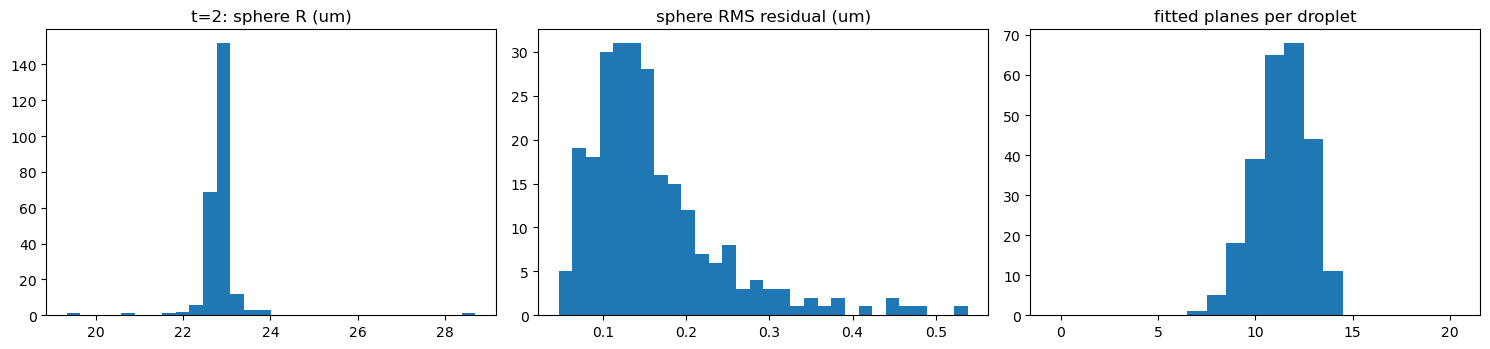

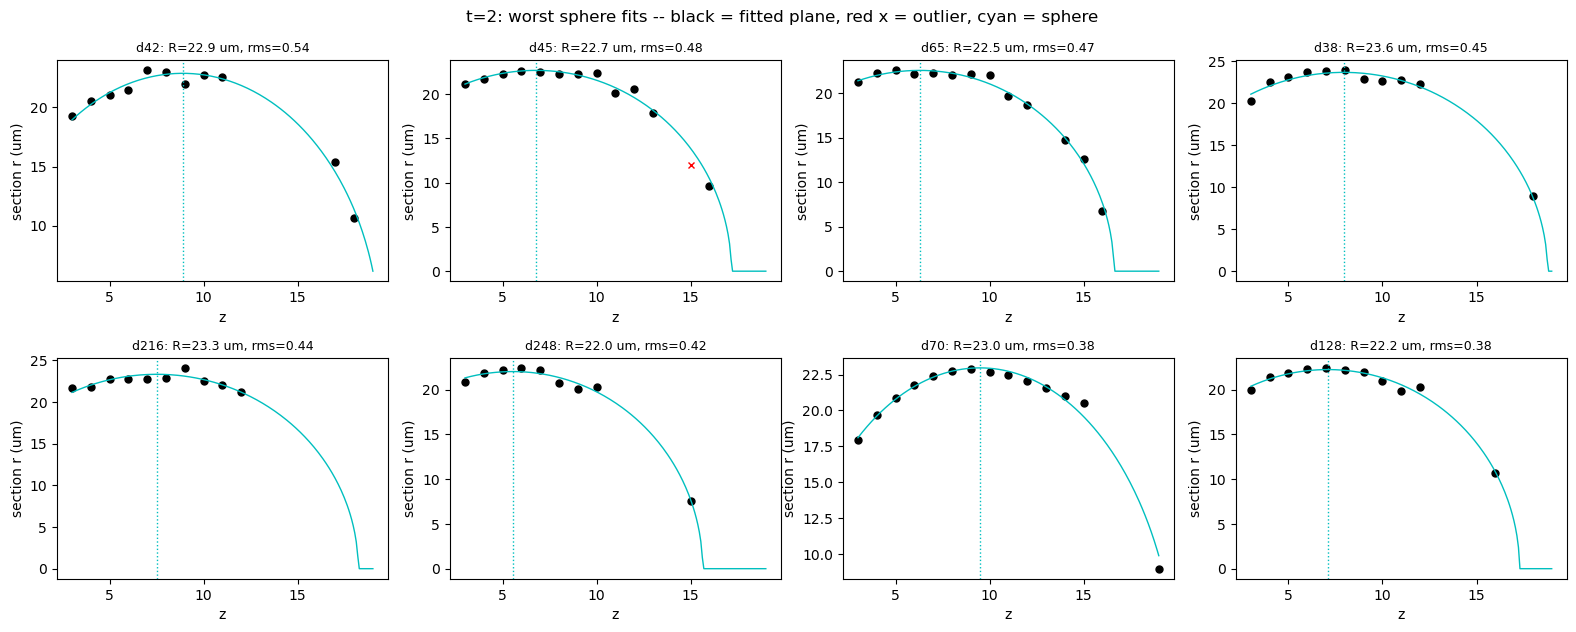

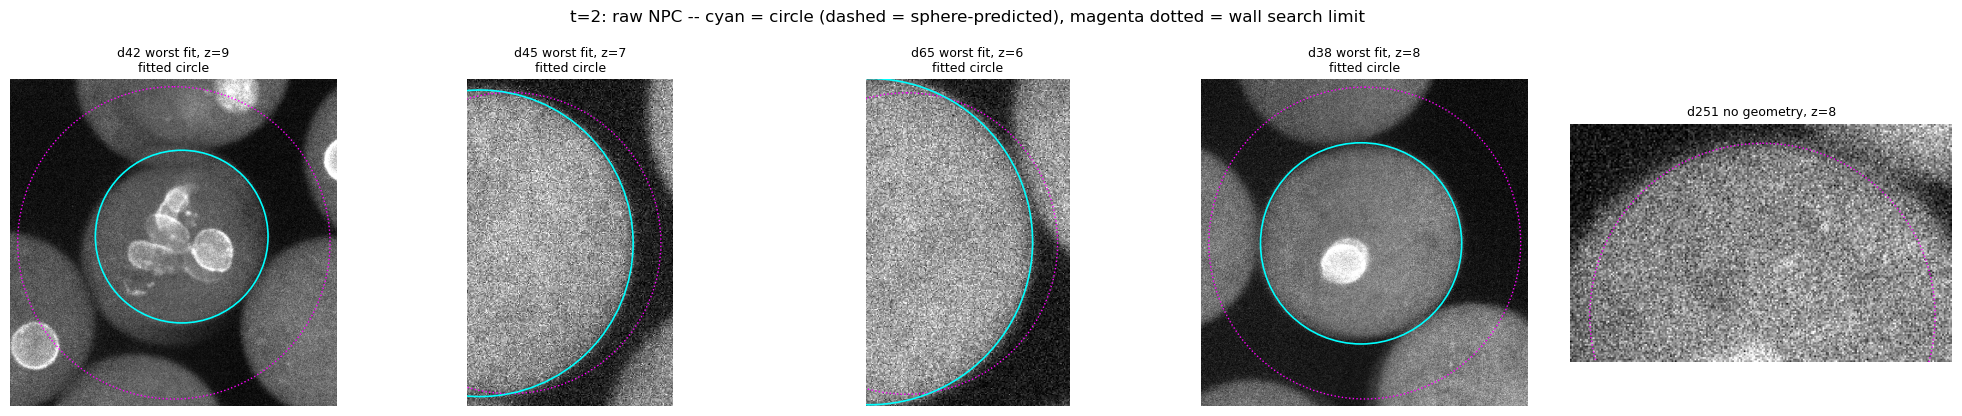

t=9: 180 droplets in the z=15 inventory
t=9: initial geometry z=3 (1/17), 180 droplets
t=9: initial geometry z=4 (2/17), 180 droplets
t=9: initial geometry z=5 (3/17), 180 droplets
t=9: initial geometry z=6 (4/17), 180 droplets
t=9: initial geometry z=7 (5/17), 180 droplets
t=9: initial geometry z=8 (6/17), 180 droplets
t=9: initial geometry z=9 (7/17), 180 droplets
t=9: initial geometry z=10 (8/17), 180 droplets
t=9: initial geometry z=11 (9/17), 180 droplets
t=9: initial geometry z=12 (10/17), 180 droplets
t=9: initial geometry z=13 (11/17), 180 droplets
t=9: initial geometry z=14 (12/17), 180 droplets
t=9: initial geometry z=15 (13/17), 180 droplets
t=9: initial geometry z=16 (14/17), 180 droplets
t=9: initial geometry z=17 (15/17), 180 droplets
t=9: initial geometry z=18 (16/17), 180 droplets
t=9: initial geometry z=19 (17/17), 180 droplets
t=9: population R prior 22.63 um from 155 clean preliminary spheres
t=9: guided round 1: attempted 916, accepted 329, changed 125, geometry 172

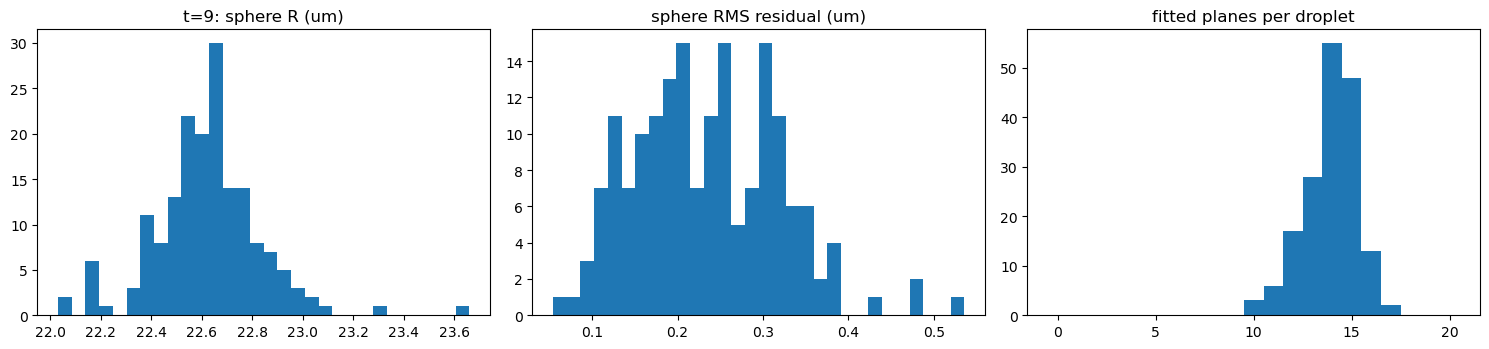

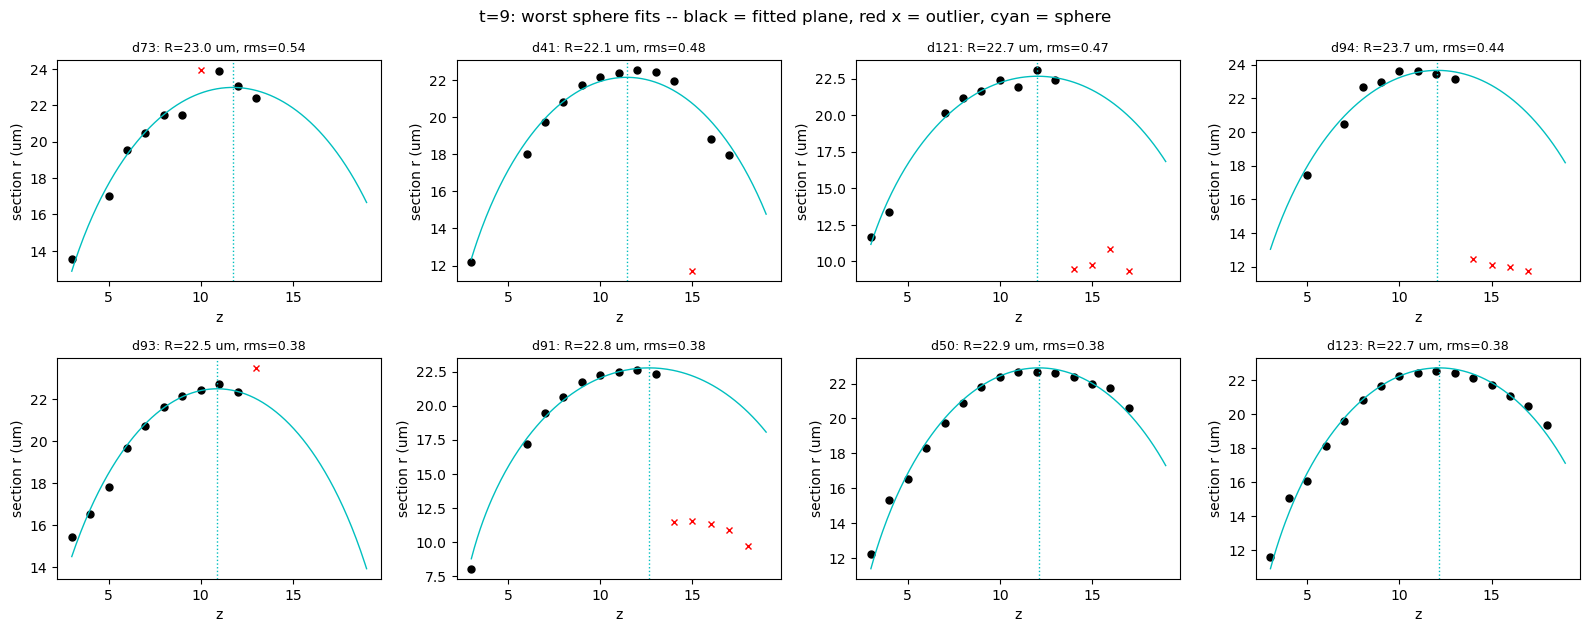

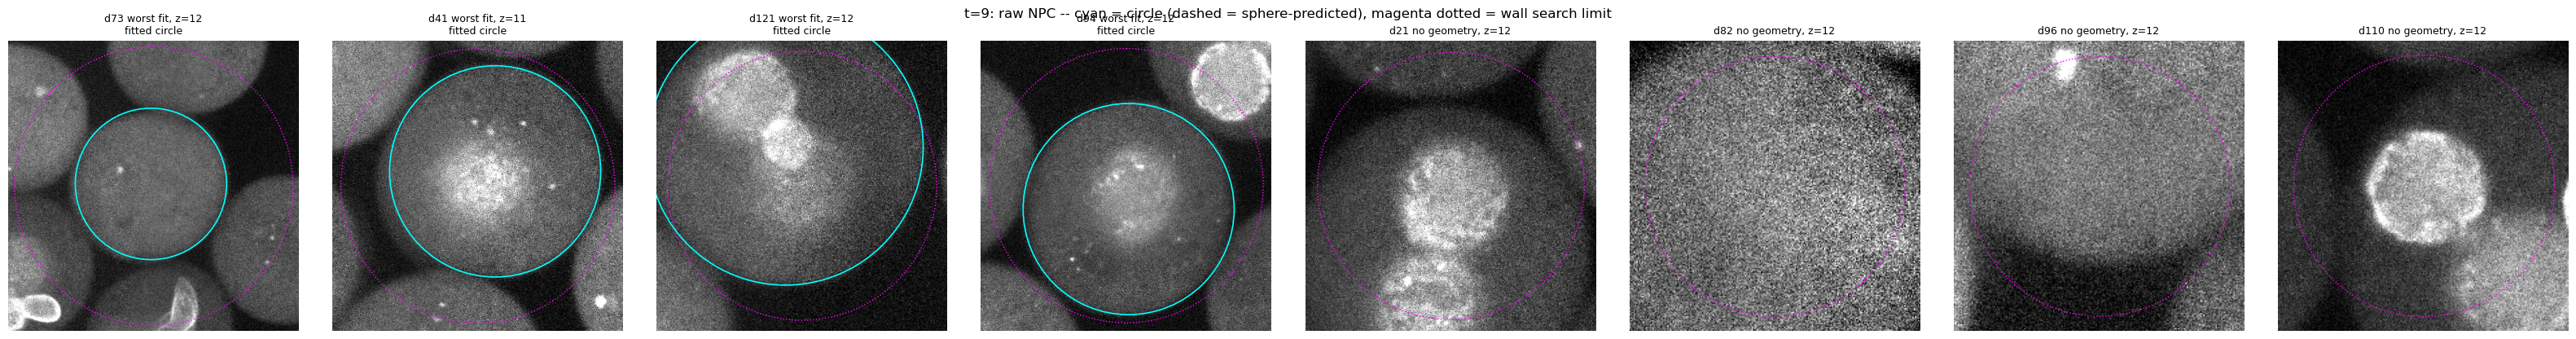

,t,droplet,r_prior,has_geometry,fitted_z,n_fitted,n_used,outlier_z,z_eq,z_eq_argmax,R_um,R_over_prior,sphere_rms_um,extrapolated,cap_z,axial_step_um
42,2,42,106.2,True,"3-11,17-18",11,11,-,8.88,7,22.89,1.33,0.538,False,17-18,2.135261
325,9,73,113.7,True,"3,5-13",10,9,10,11.73,10,22.99,1.24,0.536,False,"3,5",2.097258
45,2,45,59.1,True,"3-13,15-16",13,12,15,6.78,6,22.65,2.36,0.478,False,15-16,2.256385
293,9,41,77.8,True,"3,6-17",13,12,15,11.43,12,22.14,1.75,0.477,False,3,2.324563
373,9,121,60.3,True,"3-4,7-17",13,9,14-17,12.04,12,22.65,2.31,0.475,False,3-4,NaN
65,2,65,54.8,True,"3-12,14-16",13,13,-,6.28,5,22.53,2.53,0.465,False,14-16,2.224733
38,2,38,99.0,True,"3-12,18",11,11,-,7.94,8,23.63,1.47,0.452,False,18,2.185201
216,2,216,88.5,True,3-12,10,10,-,7.51,9,23.34,1.62,0.441,False,-,1.978573
346,9,94,81.5,True,"5,7-17",12,8,14-17,12.05,10,23.66,1.79,0.435,False,5,NaN
248,2,248,58.8,True,"3-10,15",9,9,-,5.54,6,22.02,2.30,0.415,False,15,2.226220


In [14]:
# ============================================================
# E1. Droplet geometry QC
# ============================================================
# CHECK, informational (not a fix). Read-only: writes nothing to disk.
#
# Runs B2 -> B4 on E1_TIMEPOINTS exactly as phase 2 generation will, and reports
# whether the droplet geometry is fit to build labels from:
#   coverage    droplets with geometry (>= geometry_min_planes fitted planes) and
#               the ones without -- phase 2 never labels a droplet without geometry
#   size        R_um distribution. The droplets are monodisperse (T-junction), so
#               a wide spread or a tail points at bad geometry, not biology
#   sphere fit  RMS radius residual, planes set aside as outliers, and z_eq
#               extrapolated outside the fitted planes
#   z_eq        how far the sphere z_eq sits from 2.5.2's largest-circle choice
#   caps        droplets with planes the cap rule (u > cap_u_safe) would mark
#   axial scale geometry uses geometry_z_step_um inside the sample. A free
#               quadratic fit of r^2 against z independently checks that calibration.
#               z_step_um remains the acquisition stage step; z-offset geometry and
#               cap u use the calibrated in-sample value.
# Plots: histograms, r(z) with the fitted sphere for the worst-fitting droplets,
# and raw NPC with the fitted circle for those droplets and for droplets with no
# geometry.
from matplotlib.patches import Circle
from IPython.display import display

E1_TIMEPOINTS = (2, 9)
E1_PROFILE_PLOTS = 8      # worst sphere residuals: r(z) + sphere
E1_OVERLAYS = 4           # worst residuals and no-geometry droplets: raw NPC + circle


def _ranges(zs):
    """[3, 4, 5, 8, 9] -> '3-5,8-9'."""
    zs, out = sorted(zs), []
    for z in zs:
        if out and z == out[-1][1] + 1:
            out[-1][1] = z
        else:
            out.append([z, z])
    return ",".join(f"{a}" if a == b else f"{a}-{b}" for a, b in out) or "-"


def _axial_step_um(g, cfg=cfg):
    """Effective um per plane from a free quadratic r^2(z) fit, or NaN when the
    fitted planes do not bracket the equator well enough to constrain curvature."""
    zs = np.array([z for z in sorted(g["prof"]) if z not in g["sphere_outliers"]], float)
    if len(zs) < 5 or not (zs.min() <= g["z_eq"] - 1 and zs.max() >= g["z_eq"] + 1):
        return np.nan
    r2 = (np.array([g["prof"][int(z)][2] for z in zs]) * cfg.pixel_size_um) ** 2
    c = np.polyfit(zs, r2, 2)[0]
    return float(np.sqrt(-c)) if c < 0 else np.nan


def geometry_qc(t, hs=None):
    hs = load_memmap_tiff(cfg.image_file) if hs is None else hs
    n_z = hs.shape[1]
    valid_zs = [z for z in range(n_z) if z_in_focus_range(z, n_z, cfg=cfg)]
    ref_z = (cfg.inventory_ref_z if cfg.inventory_ref_z in valid_zs
             else valid_zs[len(valid_zs) // 2])
    inv = detect_droplets_npc_watershed(
        extract_plane(hs, t, ref_z, cfg.npc_channel_idx), cfg=cfg, compact=True)
    print(f"t={t}: {len(inv)} droplets in the z={ref_z} inventory", flush=True)
    geom = compute_droplet_geometry(hs, t, inv, cfg=cfg)

    rows = []
    for did, d in enumerate(inv):
        r_prior = float(np.sqrt(d["area"] / np.pi))
        g = geom.get(did)
        if g is None:
            rows.append(dict(t=t, droplet=did, r_prior=round(r_prior, 1), has_geometry=False))
            continue
        caps = [z for z in g["prof"] if cap_u(g, z, cfg) > cfg.cap_u_safe]
        rows.append(dict(
            t=t, droplet=did, r_prior=round(r_prior, 1), has_geometry=True,
            fitted_z=_ranges(g["prof"]), n_fitted=len(g["prof"]), n_used=g["n_planes"],
            outlier_z=_ranges(g["sphere_outliers"]),
            z_eq=round(g["z_eq"], 2), z_eq_argmax=g["z_eq_argmax"],
            R_um=round(g["R_um"], 2), R_over_prior=round(g["R_um"] / cfg.pixel_size_um / r_prior, 2),
            sphere_rms_um=round(g["sphere_rms_um"], 3), extrapolated=g["extrapolated"],
            cap_z=_ranges(caps), axial_step_um=_axial_step_um(g, cfg)))
    df = pd.DataFrame(rows)
    for col in ("n_fitted", "n_used", "z_eq_argmax"):
        if col in df:
            df[col] = df[col].astype("Int64")
    ok = df[df.has_geometry]

    print(f"\n=== t={t} ===")
    print(f"droplets with geometry: {len(ok)} / {len(df)}"
          f"   without: {list(df.droplet[~df.has_geometry])}")
    if ok.empty:
        print("no droplet has geometry -- check the inventory and wall settings before anything else")
        return df, geom
    print("R_um p5/p50/p95:", np.percentile(ok.R_um, [5, 50, 95]).round(2),
          f"  (validate_geometry assumes ~{280 / 2 * cfg.pixel_size_um:.1f})")
    print("sphere RMS um p50/p95/max:", np.percentile(ok.sphere_rms_um, [50, 95, 100]).round(3))
    print(f"droplets with outlier planes: {(ok.outlier_z != '-').sum()}"
          f"   extrapolated z_eq: {ok.extrapolated.sum()}")
    shift = (ok.z_eq - ok.z_eq_argmax).abs()
    print(f"|z_eq - largest-circle plane|: median {shift.median():.2f} planes, "
          f">= 2 planes for {(shift >= 2).sum()} droplets")
    print(f"droplets with cap planes (u > {cfg.cap_u_safe}): {(ok.cap_z != '-').sum()}")
    ax_ok = ok.axial_step_um.dropna()
    if len(ax_ok):
        q = np.percentile(ax_ok, [25, 50, 75]).round(2)
        print(f"axial step from free fits: median {q[1]} um (IQR {q[0]}-{q[2]}, "
              f"{len(ax_ok)} droplets) vs geometry_z_step_um = {cfg.geometry_z_step_um}")
    else:
        print("axial step: no droplet brackets its equator with >= 5 planes")

    # ---- histograms ----
    fig, ax = plt.subplots(1, 3, figsize=(15, 3.6))
    ax[0].hist(ok.R_um, bins=30); ax[0].set_title(f"t={t}: sphere R (um)")
    ax[1].hist(ok.sphere_rms_um, bins=30); ax[1].set_title("sphere RMS residual (um)")
    ax[2].hist(ok.n_fitted, bins=np.arange(0, n_z + 2) - 0.5); ax[2].set_title("fitted planes per droplet")
    plt.tight_layout(); plt.show()

    # ---- r(z) profiles for the worst sphere fits ----
    worst = ok.sort_values("sphere_rms_um", ascending=False).droplet.head(E1_PROFILE_PLOTS).tolist()
    if worst:
        ncol = 4
        nrow = int(np.ceil(len(worst) / ncol))
        fig, axes = plt.subplots(nrow, ncol, figsize=(4 * ncol, 3.2 * nrow), squeeze=False)
        for a in axes.ravel():
            a.axis("off")
        zz = np.linspace(cfg.cap_z_floor, n_z - 1, 200)
        for a, did in zip(axes.ravel(), worst):
            g = geom[did]
            a.axis("on")
            for z, (_, _, rpx) in sorted(g["prof"].items()):
                bad = z in g["sphere_outliers"]
                a.plot(z, rpx * cfg.pixel_size_um, "rx" if bad else "ko", ms=5)
            rr = np.sqrt(np.clip(g["R_um"] ** 2 - (cfg.geometry_z_step_um * (zz - g["z_eq"])) ** 2, 0, None))
            a.plot(zz, rr, "c-", lw=1)
            a.axvline(g["z_eq"], color="c", ls=":", lw=1)
            a.set_title(f"d{did}: R={g['R_um']:.1f} um, rms={g['sphere_rms_um']:.2f}", fontsize=9)
            a.set_xlabel("z"); a.set_ylabel("section r (um)")
        fig.suptitle(f"t={t}: worst sphere fits -- black = fitted plane, red x = outlier, cyan = sphere")
        plt.tight_layout(); plt.show()

    # ---- raw NPC with circles: worst fits, then droplets without geometry ----
    H, W = hs.shape[-2:]
    z_show_default = int(round(float(np.median(ok.z_eq)))) if len(ok) else ref_z
    panels = [(did, "worst fit") for did in worst[:E1_OVERLAYS]]
    panels += [(int(did), "no geometry") for did in df.droplet[~df.has_geometry].head(E1_OVERLAYS)]
    if panels:
        fig, axes = plt.subplots(1, len(panels), figsize=(4 * len(panels), 4.2), squeeze=False)
        for a, (did, kind) in zip(axes[0], panels):
            d = inv[did]
            cy0, cx0 = d["centroid"]
            r_prior = float(np.sqrt(d["area"] / np.pi))
            g = geom.get(did)
            z = int(np.clip(round(g["z_eq"]), 0, n_z - 1)) if g else z_show_default
            half = int(np.ceil(cfg.wall_r_hi_frac * r_prior)) + 10
            y0, x0 = max(0, int(cy0) - half), max(0, int(cx0) - half)
            y1, x1 = min(H, int(cy0) + half + 1), min(W, int(cx0) + half + 1)
            img = read_crop(hs, t, z, cfg.npc_channel_idx, (y0, x0, y1, x1))
            lo, hi = np.percentile(img, [1, 99.5])
            a.imshow(img, cmap="gray", vmin=lo, vmax=max(hi, lo + 1))
            a.add_patch(Circle((cx0 - x0, cy0 - y0), cfg.wall_r_hi_frac * r_prior,
                               fill=False, ec="magenta", ls=":", lw=1))
            if g is not None:
                fitted = z in g["prof"] and z not in g["sphere_outliers"]
                c = g["prof"][z] if fitted else predicted_circle(g, z, cfg)
                if c is not None:
                    a.add_patch(Circle((c[0] - x0, c[1] - y0), c[2], fill=False, ec="cyan",
                                       ls="-" if fitted else "--", lw=1.2))
                a.set_title(f"d{did} {kind}, z={z}\n"
                            f"{'fitted' if fitted else 'sphere-predicted'} circle", fontsize=9)
            else:
                a.set_title(f"d{did} {kind}, z={z}", fontsize=9)
            a.axis("off")
        fig.suptitle(f"t={t}: raw NPC -- cyan = circle (dashed = sphere-predicted), "
                     "magenta dotted = wall search limit")
        plt.tight_layout(); plt.show()
    return df, geom


if RUN_GEOMETRY_QC:
    _hs = load_memmap_tiff(cfg.image_file)
    E1_RESULTS = {t: geometry_qc(t, _hs) for t in E1_TIMEPOINTS}
    del _hs
    display(pd.concat([df for df, _ in E1_RESULTS.values()], ignore_index=True)
            .sort_values("sphere_rms_um", ascending=False).head(20))
if RUN_GEOMETRY_QC:
    E1_CONFIG_HASH = cfg._hash_of(cfg._GEOM_FIELDS + ('pixel_size_um',))


In [15]:
# ============================================================
# E2. Normalization stats check
# ============================================================
# CHECK, informational (not a fix). Read-only: computes the global_t stats in
# memory and writes nothing.
#
# The stats depend only on the image, z_floor and the two strides, so 2.5.3 should
# reproduce 2.5.2's exactly. A mismatch means a normalization input changed, and a
# 2.5.3 model would not see inputs on the same scale as the 2.5.2 / 1.1 baselines.
# Reference: E2_REFERENCE if set; otherwise the norm_stats.json cached beside the
# 2.5.2 classical pool (only an exact training_patches_Vulcan_2.5.2_* match is used).
from IPython.display import display

E2_REFERENCE = None       # or Path(".../norm_stats.json")

def norm_stats_check(cfg=cfg):
    if cfg.normalization_mode == "per_patch":
        print("normalization_mode = per_patch: no global stats to check")
        return None
    ref = E2_REFERENCE
    if ref is None:
        hits = sorted(cfg.out_root.glob("training_patches_Vulcan_2.5.2_*/qc/norm_stats.json"))
        if len(hits) != 1:
            print(f"found {len(hits)} 2.5.2 norm_stats.json files {[str(h) for h in hits]}; "
                  "set E2_REFERENCE to the one the 2.5.2 pools were built with")
            return None
        ref = hits[0]
    old = load_norm_stats(ref)
    print(f"computing 2.5.3 stats in memory (z_floor={cfg.z_floor}, "
          f"strides {cfg.norm_stats_stride}/{cfg.norm_stats_z_stride})...", flush=True)
    new = compute_global_norm_stats(cfg.image_file, cfg)
    rows = []
    for key in sorted(set(old) | set(new)):
        o, n = old.get(key), new.get(key)
        if o is None or n is None:
            rows.append(dict(t=key[0], channel=key[1], status="missing on one side"))
            continue
        span = max(o[1] - o[0], 1e-9)
        rows.append(dict(t=key[0], channel=key[1], lo_252=o[0], hi_252=o[1], lo_253=n[0], hi_253=n[1],
                         max_rel_diff=max(abs(n[0] - o[0]), abs(n[1] - o[1])) / span))
    df = pd.DataFrame(rows)
    worst = df["max_rel_diff"].max() if "max_rel_diff" in df else np.nan
    verdict = "PASS" if (df.get("status") is None or df["status"].isna().all()) and worst < 1e-6 else "DIFFERENT"
    print(f"{verdict}: {len(new)} (t,channel) pairs vs {ref}; largest difference "
          f"{worst:.2e} of the 2.5.2 range")
    if verdict != "PASS":
        display(df.sort_values("max_rel_diff", ascending=False).head(10))
    return df

if RUN_NORM_STATS_CHECK:
    E2_RESULT = norm_stats_check()
if RUN_NORM_STATS_CHECK:
    E2_CONFIG_HASH = cfg._hash_of(cfg._INPUT_FIELDS)


computing 2.5.3 stats in memory (z_floor=6, strides 4/4)...


PASS: 30 (t,channel) pairs vs /data/user/tdeibert/Nuclear_Scaling/Inputs/Training_Data/training_patches_Vulcan_2.5.2_f3f88c49ef/qc/norm_stats.json; largest difference 0.00e+00 of the 2.5.2 range


In [16]:
# ============================================================
# E4b. Empty-droplet and artifact audit (read-only)
# ============================================================
# Requirements:
#   - Run notebook definitions through B6.
#   - Run E1 for t=2 and t=9 so E1_RESULTS contains their geometry.
#
# Purpose:
#   1. Find droplets with no accepted nucleus on any supported z plane.
#   2. Cross-reference the complete gold NLS ROI set.
#   3. Exclude t<=2 droplets containing ambiguous early orphan NPC ROIs.
#   4. Identify gold-confirmed empty droplets suitable for nucleus-negative
#      supervision.
#   5. Show rejected Otsu candidates in red so their artifact status can be
#      checked across the full z profile.
#
# This cell writes nothing.

import roifile
from skimage.draw import polygon as _ed_polygon

try:
    import cv2 as _ed_cv2
except ImportError:
    _ed_cv2 = None


ED_TIMEPOINTS = (2, 9)
ED_NUCLEI_ZIP = ROI_ROOT / "NucleiRoiSet.zip"
ED_NPC_ZIP = ROI_ROOT / "NPCRoiSet.zip"

ED_ROI_INSIDE_FRAC = 0.50
ED_NPC_DROPLET_OVERLAP_FRAC = 0.25
ED_CAP_DZ = 2
ED_NEAR_MIN_FRAC = 0.50

ED_GALLERY_PER_GROUP = 4
ED_MAX_GALLERY_DROPLETS = 16
ED_SEED = 0


def _ed_read_rois(zip_path):
    """Return ROI dictionaries with zero-based t/z and polygon coordinates."""
    items = []
    for i, roi in enumerate(roifile.roiread(str(zip_path))):
        coordinates = roi.coordinates()
        if coordinates is None or len(coordinates) < 3:
            continue
        items.append({
            "i": i,
            "t": int((roi.t_position or 1) - 1),
            "z": int((roi.z_position or 1) - 1),
            "poly": np.asarray(coordinates, dtype=float),
        })
    return items


def _ed_local_mask(poly, H, W):
    """Compact full-image ROI representation: ((r0,c0,r1,c1), mask)."""
    xs, ys = poly[:, 0], poly[:, 1]
    r0 = max(0, int(np.floor(ys.min())))
    c0 = max(0, int(np.floor(xs.min())))
    r1 = min(H, int(np.ceil(ys.max())) + 1)
    c1 = min(W, int(np.ceil(xs.max())) + 1)

    if r1 <= r0 or c1 <= c0:
        return None

    mask = np.zeros((r1 - r0, c1 - c0), dtype=np.uint8)
    points = np.round(poly - [c0, r0]).astype(np.int32)

    if _ed_cv2 is not None:
        _ed_cv2.fillPoly(mask, [points], 1)
    else:
        rr, cc = _ed_polygon(
            points[:, 1],
            points[:, 0],
            shape=mask.shape,
        )
        mask[rr, cc] = 1

    mask = mask.astype(bool)
    return ((r0, c0, r1, c1), mask) if mask.any() else None


def _ed_overlap(a, b):
    """Pixel overlap between two compact masks."""
    if a is None or b is None:
        return 0

    (ar0, ac0, ar1, ac1), am = a
    (br0, bc0, br1, bc1), bm = b

    r0 = max(ar0, br0)
    c0 = max(ac0, bc0)
    r1 = min(ar1, br1)
    c1 = min(ac1, bc1)

    if r0 >= r1 or c0 >= c1:
        return 0

    av = am[r0-ar0:r1-ar0, c0-ac0:c1-ac0]
    bv = bm[r0-br0:r1-br0, c0-bc0:c1-bc0]
    return int((av & bv).sum())


def _ed_mask_in_box(local, box):
    """Rasterize a compact ROI into an existing crop box."""
    r0, c0, r1, c1 = box
    out = np.zeros((r1-r0, c1-c0), dtype=bool)

    if local is None:
        return out

    (ar0, ac0, ar1, ac1), mask = local

    y0 = max(r0, ar0)
    x0 = max(c0, ac0)
    y1 = min(r1, ar1)
    x1 = min(c1, ac1)

    if y0 >= y1 or x0 >= x1:
        return out

    out[y0-r0:y1-r0, x0-c0:x1-c0] = \
        mask[y0-ar0:y1-ar0, x0-ac0:x1-ac0]
    return out


def _ed_prepare_rois(H, W):
    nucleus_items = _ed_read_rois(ED_NUCLEI_ZIP)
    npc_items = _ed_read_rois(ED_NPC_ZIP)

    nuclei = {}
    npc = {}

    for item in nucleus_items:
        item["loc"] = _ed_local_mask(item["poly"], H, W)
        if item["loc"] is not None:
            item["area"] = int(item["loc"][1].sum())
            nuclei.setdefault((item["t"], item["z"]), []).append(item)

    for item in npc_items:
        item["loc"] = _ed_local_mask(item["poly"], H, W)
        if item["loc"] is not None:
            item["area"] = int(item["loc"][1].sum())
            npc.setdefault((item["t"], item["z"]), []).append(item)

    # Reproduce the agreed paired / blur / orphan classification.
    for (t, z), npc_rois in npc.items():
        same_plane_nuclei = nuclei.get((t, z), [])

        for npc_roi in npc_rois:
            paired = False

            for nucleus_roi in same_plane_nuclei:
                inside = (
                    _ed_overlap(npc_roi["loc"], nucleus_roi["loc"])
                    / max(nucleus_roi["area"], 1)
                )
                if inside >= ED_ROI_INSIDE_FRAC:
                    paired = True
                    break

            if paired:
                npc_roi["cls"] = "paired"
                continue

            blur = False
            for dz in range(1, ED_CAP_DZ + 1):
                for sign in (-1, 1):
                    for nucleus_roi in nuclei.get((t, z + sign*dz), []):
                        overlap = (
                            _ed_overlap(npc_roi["loc"], nucleus_roi["loc"])
                            / max(min(npc_roi["area"], nucleus_roi["area"]), 1)
                        )
                        if overlap >= ED_NEAR_MIN_FRAC:
                            blur = True
                            break
                    if blur:
                        break
                if blur:
                    break

            npc_roi["cls"] = "blur" if blur else "orphan"

    print(
        f"Loaded {len(nucleus_items):,} nucleus ROIs and "
        f"{len(npc_items):,} NPC ROIs"
    )
    return nuclei, npc


def _ed_droplet_planes(g, n_z, cfg=cfg):
    """Every in-focus plane for which the fitted sphere predicts a section."""
    planes = []

    for z in range(n_z):
        if not z_in_focus_range(z, n_z, cfg):
            continue

        fitted = z in g["prof"] and z not in g["sphere_outliers"]
        circle = g["prof"][z] if fitted else predicted_circle(g, z, cfg)

        if circle is not None and circle[2] > cfg.erosion_px:
            planes.append((z, circle, fitted))

    return planes


def _ed_pick_gallery(summary, rng):
    groups = [
        "gold-empty: artifact rejected",
        "gold-empty: false positive",
        "gold-positive: detected",
        "gold-positive: detector miss",
        "early-orphan: ambiguous",
    ]

    chosen = []

    for group in groups:
        candidates = summary[summary["audit_group"] == group]

        if candidates.empty:
            continue

        n = min(ED_GALLERY_PER_GROUP, len(candidates))
        indices = rng.choice(len(candidates), n, replace=False)
        chosen.extend(candidates.iloc[indices].to_dict("records"))

    return chosen[:ED_MAX_GALLERY_DROPLETS]


def empty_droplet_audit(cfg=cfg):
    hs = load_memmap_tiff(cfg.image_file)
    H, W = hs.shape[-2:]
    nuclei, npc = _ed_prepare_rois(H, W)
    rng = np.random.default_rng(ED_SEED)

    summaries = []
    profiles = {}

    for t in ED_TIMEPOINTS:
        if t not in globals().get("E1_RESULTS", {}):
            raise RuntimeError(
                f"E1_RESULTS[{t}] is missing. Run E1 for t={t} first."
            )

        geometry = E1_RESULTS[t][1]
        print(f"\nAuditing t={t}: {len(geometry)} accepted droplet geometries")

        for did, g in geometry.items():
            planes = _ed_droplet_planes(g, hs.shape[1], cfg)
            plane_records = []

            gold_nucleus = False
            early_orphan = False
            any_accepted = False
            any_rejected = False
            accepted_pixels = 0
            rejected_pixels = 0

            for z, (cx, cy, radius), fitted in planes:
                pad = 12
                half = int(np.ceil(radius)) + pad
                y0 = max(0, int(np.floor(cy)) - half)
                x0 = max(0, int(np.floor(cx)) - half)
                y1 = min(H, int(np.ceil(cy)) + half + 1)
                x1 = min(W, int(np.ceil(cx)) + half + 1)
                box = (y0, x0, y1, x1)

                nls = read_crop(
                    hs, t, z, cfg.nucleus_channel_idx, box
                )

                yy, xx = np.ogrid[:nls.shape[0], :nls.shape[1]]
                support_radius = max(float(radius) - cfg.erosion_px, 1.0)
                support = (
                    (xx - (cx-x0))**2 + (yy - (cy-y0))**2
                    <= support_radius**2
                )

                result = detect_nucleus(
                    nls,
                    support,
                    support_radius,
                    cfg,
                )

                gold_mask = np.zeros_like(support)
                for roi in nuclei.get((t, z), []):
                    roi_mask = _ed_mask_in_box(roi["loc"], box)
                    inside = int((roi_mask & support).sum()) / max(
                        int(roi_mask.sum()), 1
                    )
                    if inside >= ED_ROI_INSIDE_FRAC:
                        gold_mask |= roi_mask
                        gold_nucleus = True

                orphan_mask = np.zeros_like(support)
                if t <= 2:
                    for roi in npc.get((t, z), []):
                        if roi["cls"] != "orphan":
                            continue

                        roi_mask = _ed_mask_in_box(roi["loc"], box)
                        overlap = int((roi_mask & support).sum()) / max(
                            int(roi_mask.sum()), 1
                        )

                        if overlap >= ED_NPC_DROPLET_OVERLAP_FRAC:
                            orphan_mask |= roi_mask
                            early_orphan = True

                n_accepted = int(result["mask"].sum())
                n_rejected = int(result["unannotated"].sum())

                any_accepted |= n_accepted > 0
                any_rejected |= n_rejected > 0
                accepted_pixels += n_accepted
                rejected_pixels += n_rejected

                plane_records.append({
                    "z": z,
                    "fitted": fitted,
                    "box": box,
                    "nls": nls,
                    "support": support,
                    "gold": gold_mask,
                    "early_orphan": orphan_mask,
                    "result": result,
                })

            detector_empty = not any_accepted
            gold_empty = not gold_nucleus
            negative_eligible = gold_empty and not early_orphan

            if early_orphan and gold_empty:
                audit_group = "early-orphan: ambiguous"
            elif gold_empty and detector_empty and any_rejected:
                audit_group = "gold-empty: artifact rejected"
            elif gold_empty and any_accepted:
                audit_group = "gold-empty: false positive"
            elif gold_empty:
                audit_group = "gold-empty: clean"
            elif gold_nucleus and detector_empty:
                audit_group = "gold-positive: detector miss"
            else:
                audit_group = "gold-positive: detected"

            summaries.append({
                "t": t,
                "droplet": did,
                "n_planes": len(plane_records),
                "gold_nucleus": gold_nucleus,
                "early_orphan": early_orphan,
                "gold_empty": gold_empty,
                "negative_eligible": negative_eligible,
                "detector_empty": detector_empty,
                "has_rejected_artifact": any_rejected,
                "accepted_pixels": accepted_pixels,
                "rejected_pixels": rejected_pixels,
                "audit_group": audit_group,
            })

            profiles[(t, did)] = plane_records

    summary = pd.DataFrame(summaries)

    print("\n=== Droplet-level outcomes ===")
    print(
        summary.groupby(["t", "audit_group"])
        .size()
        .rename("n")
        .to_string()
    )

    print("\n=== Candidate empty-droplet negatives ===")
    eligibility = summary.groupby("t").agg(
        droplets=("droplet", "size"),
        gold_empty=("gold_empty", "sum"),
        early_orphan_ambiguous=("early_orphan", "sum"),
        negative_eligible=("negative_eligible", "sum"),
        detector_empty=("detector_empty", "sum"),
        gold_empty_false_positive=(
            "audit_group",
            lambda s: int((s == "gold-empty: false positive").sum()),
        ),
        gold_empty_artifact_rejected=(
            "audit_group",
            lambda s: int((s == "gold-empty: artifact rejected").sum()),
        ),
        gold_positive_detector_miss=(
            "audit_group",
            lambda s: int((s == "gold-positive: detector miss").sum()),
        ),
    )
    print(eligibility.to_string())

    print(
        "\nInterpretation:\n"
        "  negative_eligible=True means no gold NLS ROI and no ambiguous early\n"
        "  orphan NPC ROI was associated with the droplet. These are the strongest\n"
        "  candidates for explicit empty-droplet nucleus-negative supervision.\n"
        "  Gold-positive detector misses must never become negative examples."
    )

    # ---------------- Gallery ----------------
    selected = _ed_pick_gallery(summary, rng)

    for item in selected:
        t = int(item["t"])
        did = int(item["droplet"])
        plane_records = profiles[(t, did)]

        if not plane_records:
            continue

        pooled = np.concatenate([
            p["nls"][p["support"]]
            for p in plane_records
            if p["support"].any()
        ])
        lo, hi = np.percentile(pooled, [1, 99.5])

        fig, axes = plt.subplots(
            len(plane_records),
            3,
            figsize=(12, 2.8*len(plane_records)),
            squeeze=False,
        )

        for row, plane in enumerate(plane_records):
            z = plane["z"]
            support = plane["support"]
            result = plane["result"]

            panels = (
                ("Raw NLS", plane["nls"]),
                ("Production result", plane["nls"]),
                ("Gold / ambiguity", plane["nls"]),
            )

            for col, (title, image) in enumerate(panels):
                ax = axes[row, col]
                ax.imshow(
                    image,
                    cmap="gray",
                    vmin=lo,
                    vmax=max(hi, lo+1),
                )
                ax.contour(
                    support,
                    levels=[0.5],
                    colors="yellow",
                    linewidths=0.6,
                    linestyles="solid" if plane["fitted"] else "dashed",
                )

                if col == 1:
                    if result["mask"].any():
                        ax.contour(
                            result["mask"],
                            levels=[0.5],
                            colors="cyan",
                            linewidths=1.1,
                        )
                    if result["unannotated"].any():
                        ax.contour(
                            result["unannotated"],
                            levels=[0.5],
                            colors="red",
                            linewidths=1.1,
                        )

                if col == 2:
                    if plane["gold"].any():
                        ax.contour(
                            plane["gold"],
                            levels=[0.5],
                            colors="magenta",
                            linewidths=1.2,
                        )
                    if plane["early_orphan"].any():
                        ax.contour(
                            plane["early_orphan"],
                            levels=[0.5],
                            colors="orange",
                            linewidths=1.2,
                        )

                ax.set_title(f"z={z} | {title}", fontsize=9)
                ax.axis("off")

        fig.suptitle(
            f"T{t}, droplet {did} — {item['audit_group']}\n"
            "cyan=accepted NLS; red=rejected artifact; "
            "magenta=gold NLS; orange=early orphan NPC; "
            "yellow=droplet support",
            fontsize=11,
        )
        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()
        plt.close(fig)

    return {
        "summary": summary,
        "profiles": profiles,
        "nuclei": nuclei,
        "npc": npc,
    }


if RUN_EMPTY_DROPLET_AUDIT:          # A5 flag; read-only but slow
    EMPTY_DROPLET_AUDIT = empty_droplet_audit()

In [17]:
# ============================================================
# E4c. Early-nucleus rejection and component-splitting audit
# ============================================================
# READ-ONLY. Writes nothing.
#
# Run after:
#   1. Notebook definitions through B6
#   2. E1_RESULTS for t=2 and t=9
#   3. EMPTY_DROPLET_AUDIT
#
# Measures gold-NLS coverage at four stages:
#   raw Otsu -> physical baseline -> production filters -> experimental split
#
# The splitter is deliberately diagnostic. It combines normalized NLS intensity
# and distance from the component boundary, creates internal markers, and
# watersheds only within an existing Otsu component.
#
# Primary detection threshold: >= 50% of a gold ROI covered.
# Also reports 25% and 75%.
#
# A linked nucleus object is detected when at least one of its ROI planes reaches
# the requested coverage.

from skimage.segmentation import watershed as _fs_watershed
from skimage.morphology import h_maxima as _fs_h_maxima


FS_EARLY_TIMEPOINTS = (0, 1, 2)
FS_COVERAGE_THRESHOLDS = (0.25, 0.50, 0.75)
FS_PRIMARY_COVERAGE = 0.50

# Adjacent gold ROI planes are linked into one nucleus when this fraction of the
# smaller ROI overlaps.
FS_Z_LINK_MIN_OVERLAP = 0.50

# Experimental splitter settings.
FS_SCORE_INTENSITY_WEIGHT = 0.65
FS_SCORE_DISTANCE_WEIGHT = 0.35
FS_MARKER_H = 0.08
FS_MIN_SEGMENT_PX = 64
FS_MAX_SEGMENTS_PER_COMPONENT = 4

FS_GALLERY_N = 8
FS_SEED = 0

# User-reviewed false-positive controls.
FS_FALSE_POSITIVE_CONTROLS = {
    (2, 9): (18,),
    (9, 128): (19,),
    (2, 68): (16,),
    (2, 232): (16,),
    (9, 41): (6, 7, 8),
    (9, 5): (7, 8, 9, 10),
    (2, 67): (18,),
}

# User-reviewed early-nucleus controls.
FS_EARLY_NUCLEUS_CONTROLS = {
    (2, 34): (10, 11, 12, 13, 14),
    (2, 88): (6, 7, 8),
    (2, 56): (9,),
}


def _fs_geometry_for_t(t, hs, cfg=cfg):
    """Reuse E1 geometry when possible; otherwise compute it read-only."""
    if t in globals().get("E1_RESULTS", {}):
        print(f"t={t}: reusing E1 geometry", flush=True)
        return E1_RESULTS[t][1]

    cache = globals().setdefault("_FS_GEOMETRY_CACHE", {})
    if t in cache:
        print(f"t={t}: reusing diagnostic geometry cache", flush=True)
        return cache[t]

    valid_zs = [
        z for z in range(hs.shape[1])
        if z_in_focus_range(z, hs.shape[1], cfg)
    ]
    ref_z = (
        cfg.inventory_ref_z
        if cfg.inventory_ref_z in valid_zs
        else valid_zs[len(valid_zs)//2]
    )

    print(f"t={t}: computing read-only geometry", flush=True)
    inventory = detect_droplets_npc_watershed(
        extract_plane(hs, t, ref_z, cfg.npc_channel_idx),
        cfg=cfg,
        compact=True,
    )
    geometry = compute_droplet_geometry(
        hs,
        t,
        inventory,
        cfg=cfg,
    )
    cache[t] = geometry
    return geometry


def _fs_circle_for_plane(g, z, cfg=cfg):
    fitted = z in g["prof"] and z not in g["sphere_outliers"]
    circle = g["prof"][z] if fitted else predicted_circle(g, z, cfg)
    return circle, fitted


def _fs_detection_crop(hs, t, z, circle, cfg=cfg):
    """Run production B5 on one droplet plane and retain crop metadata."""
    cx, cy, radius = circle
    H, W = hs.shape[-2:]
    half = int(np.ceil(radius)) + 12

    y0 = max(0, int(np.floor(cy)) - half)
    x0 = max(0, int(np.floor(cx)) - half)
    y1 = min(H, int(np.ceil(cy)) + half + 1)
    x1 = min(W, int(np.ceil(cx)) + half + 1)
    box = (y0, x0, y1, x1)

    image = read_crop(
        hs,
        t,
        z,
        cfg.nucleus_channel_idx,
        box,
    )

    yy, xx = np.ogrid[:image.shape[0], :image.shape[1]]
    support_radius = max(float(radius) - float(cfg.erosion_px), 1.0)
    support = (
        (xx - (cx-x0))**2 + (yy - (cy-y0))**2
        <= support_radius**2
    )

    result = detect_nucleus(
        image,
        support,
        support_radius,
        cfg,
    )

    return {
        "box": box,
        "image": image,
        "support": support,
        "support_radius": support_radius,
        "result": result,
    }


def _fs_candidate_measurement(
    image,
    candidate,
    support,
    raw_foreground,
    cfg=cfg,
):
    """Apply the production enrichment and solidity measurements."""
    candidate = np.asarray(candidate, bool)
    support = np.asarray(support, bool)

    if candidate.sum() < FS_MIN_SEGMENT_PX:
        return {
            "accepted": False,
            "reason": "small_segment",
            "enrichment": np.nan,
            "solidity": np.nan,
            "area_px": int(candidate.sum()),
            "ring_pixels": 0,
        }

    labels = measure.label(candidate)
    regions = measure.regionprops(labels)

    if not regions:
        return {
            "accepted": False,
            "reason": "empty_segment",
            "enrichment": np.nan,
            "solidity": np.nan,
            "area_px": 0,
            "ring_pixels": 0,
        }

    region = max(regions, key=lambda r: r.area)
    candidate = labels == region.label

    gap = max(
        1,
        int(np.ceil(
            cfg.nucleus_ring_gap_um / cfg.pixel_size_um
        )),
    )
    outer = gap + max(
        1,
        int(np.ceil(
            cfg.nucleus_ring_width_um / cfg.pixel_size_um
        )),
    )

    ring = (
        morphology.binary_dilation(
            candidate,
            morphology.disk(outer),
        )
        & ~morphology.binary_dilation(
            candidate,
            morphology.disk(gap),
        )
        & support
        & ~raw_foreground
    )

    n_ring = int(ring.sum())
    inside = float(
        np.mean(image[candidate], dtype=np.float64)
    )
    outside = (
        float(np.mean(image[ring], dtype=np.float64))
        if n_ring else np.nan
    )

    reference_ok = (
        n_ring >= int(cfg.nucleus_min_ring_pixels)
        and np.isfinite(inside)
        and np.isfinite(outside)
        and outside > 0
    )

    enrichment = inside / outside if reference_ok else np.nan
    solidity = float(region.solidity)

    reasons = []

    if not reference_ok:
        reasons.append("unassessable_cytoplasm")
    elif enrichment < cfg.nucleus_min_enrichment:
        reasons.append("enrichment")

    if (
        not np.isfinite(solidity)
        or solidity < cfg.nucleus_min_solidity
    ):
        reasons.append("solidity")

    return {
        "accepted": not reasons,
        "reason": "keep" if not reasons else " + ".join(reasons),
        "enrichment": enrichment,
        "solidity": solidity,
        "area_px": int(candidate.sum()),
        "ring_pixels": n_ring,
        "nucleus_mean": inside,
        "cytoplasm_mean": outside,
    }


def _fs_split_one_component(
    image,
    component,
    support,
    raw_foreground,
    cfg=cfg,
):
    """Split one Otsu component using intensity plus boundary distance."""
    component = np.asarray(component, bool)

    if component.sum() < FS_MIN_SEGMENT_PX:
        return [], np.zeros_like(component), []

    image_f = image.astype(np.float32)
    values = image_f[component]

    if values.size == 0:
        return [], np.zeros_like(component), []

    lo, hi = np.percentile(values, [1, 99.5])
    normalized = np.clip(
        (image_f - lo) / max(float(hi-lo), 1e-6),
        0,
        1,
    )
    normalized[~component] = 0

    smooth = filters.gaussian(
        normalized,
        sigma=1.0,
        preserve_range=True,
    )
    distance = ndimage.distance_transform_edt(component)
    distance /= max(float(distance.max()), 1e-6)

    score = (
        FS_SCORE_INTENSITY_WEIGHT * smooth
        + FS_SCORE_DISTANCE_WEIGHT * distance
    )
    score[~component] = 0

    marker_mask = _fs_h_maxima(
        score,
        FS_MARKER_H,
    ) & component
    markers = measure.label(marker_mask)

    if markers.max() < 2:
        segments = measure.label(component)
    else:
        segments = _fs_watershed(
            -score,
            markers,
            mask=component,
        )

    regions = sorted(
        measure.regionprops(segments),
        key=lambda r: -r.area,
    )[:FS_MAX_SEGMENTS_PER_COMPONENT]

    accepted_segments = []
    records = []

    for segment_number, region in enumerate(regions, start=1):
        segment = segments == region.label

        measurement = _fs_candidate_measurement(
            image,
            segment,
            support,
            raw_foreground,
            cfg,
        )
        measurement.update({
            "segment": segment_number,
            "source_label": int(region.label),
        })
        records.append(measurement)

        if measurement["accepted"]:
            accepted_segments.append({
                "mask": segment,
                "area": int(segment.sum()),
                "measurement": measurement,
            })

    split_mask = np.zeros_like(component)

    for item in sorted(
        accepted_segments,
        key=lambda x: -x["area"],
    ):
        split_mask |= item["mask"]

    return accepted_segments, split_mask, records


def _fs_split_detection(detection, cfg=cfg):
    """Apply experimental splitting to every physical Otsu component."""
    image = detection["image"]
    support = detection["support"]
    result = detection["result"]

    baseline = result["baseline"]
    raw_foreground = result["raw_foreground"]
    labels = measure.label(baseline)

    proposals = []
    records = []

    for component_region in measure.regionprops(labels):
        component = labels == component_region.label

        accepted, component_mask, component_records = \
            _fs_split_one_component(
                image,
                component,
                support,
                raw_foreground,
                cfg,
            )

        for record in component_records:
            record["component"] = int(component_region.label)
            records.append(record)

        for item in accepted:
            item["component"] = int(component_region.label)
            proposals.append(item)

    # Preserve the production two-component constraint.
    keep = np.zeros_like(support)

    for item in sorted(
        proposals,
        key=lambda x: -x["area"],
    )[:int(cfg.nucleus_keep_components)]:
        keep |= item["mask"]

    return {
        "mask": keep,
        "records": records,
        "n_proposals": len(proposals),
    }


def _fs_gold_objects(roi_records):
    """Link early gold ROI planes into nucleus objects."""
    parent = {id(roi): id(roi) for roi in roi_records}

    def find(value):
        while parent[value] != value:
            parent[value] = parent[parent[value]]
            value = parent[value]
        return value

    def union(a, b):
        ra = find(a)
        rb = find(b)
        if ra != rb:
            parent[rb] = ra

    by_tz = {}

    for roi in roi_records:
        by_tz.setdefault(
            (roi["t"], roi["z"]),
            [],
        ).append(roi)

    for t in FS_EARLY_TIMEPOINTS:
        z_values = sorted({
            z for tt, z in by_tz
            if tt == t
        })

        for z in z_values:
            current = by_tz.get((t, z), [])
            following = by_tz.get((t, z+1), [])

            pairs = []

            for a in current:
                for b in following:
                    overlap = _ed_overlap(
                        a["loc"],
                        b["loc"],
                    )
                    fraction = overlap / max(
                        min(a["area"], b["area"]),
                        1,
                    )
                    if fraction >= FS_Z_LINK_MIN_OVERLAP:
                        iou = overlap / max(
                            a["area"] + b["area"] - overlap,
                            1,
                        )
                        pairs.append((iou, a, b))

            # One-to-one adjacent-plane matching.
            used_a = set()
            used_b = set()

            for _, a, b in sorted(
                pairs,
                key=lambda item: -item[0],
            ):
                if id(a) in used_a or id(b) in used_b:
                    continue
                union(id(a), id(b))
                used_a.add(id(a))
                used_b.add(id(b))

    root_to_object = {}

    for roi in roi_records:
        root = find(id(roi))
        if root not in root_to_object:
            root_to_object[root] = len(root_to_object)
        roi["fs_object"] = root_to_object[root]

    return roi_records


def _fs_mask_coverage(prediction, gold):
    denominator = int(gold.sum())
    if denominator == 0:
        return np.nan
    return float((prediction & gold).sum() / denominator)


def _fs_assign_roi_to_droplet(
    roi,
    geometry,
    H,
    W,
    cfg=cfg,
):
    """Find the droplet support containing the largest fraction of a gold ROI."""
    z = roi["z"]
    best = None

    for did, g in geometry.items():
        circle, fitted = _fs_circle_for_plane(g, z, cfg)

        if circle is None:
            continue

        cx, cy, radius = circle
        support_radius = max(
            float(radius) - float(cfg.erosion_px),
            1.0,
        )

        half = int(np.ceil(radius)) + 12
        y0 = max(0, int(np.floor(cy)) - half)
        x0 = max(0, int(np.floor(cx)) - half)
        y1 = min(H, int(np.ceil(cy)) + half + 1)
        x1 = min(W, int(np.ceil(cx)) + half + 1)
        box = (y0, x0, y1, x1)

        yy, xx = np.ogrid[:y1-y0, :x1-x0]
        support = (
            (xx - (cx-x0))**2
            + (yy - (cy-y0))**2
            <= support_radius**2
        )

        support_local = (box, support)
        overlap = _ed_overlap(
            roi["loc"],
            support_local,
        )
        fraction = overlap / max(roi["area"], 1)

        if best is None or fraction > best["fraction"]:
            best = {
                "did": did,
                "circle": circle,
                "fitted": fitted,
                "fraction": fraction,
            }

    return best


def _fs_print_recall_tables(plane_df, object_df):
    print("\n=== Gold ROI-plane recall ===")

    rows = []

    for threshold in FS_COVERAGE_THRESHOLDS:
        for t, sub in plane_df.groupby("t"):
            rows.append({
                "t": t,
                "coverage_threshold": threshold,
                "n_roi_planes": len(sub),
                "raw_otsu_recall": float(
                    (sub.raw_coverage >= threshold).mean()
                ),
                "baseline_recall": float(
                    (sub.baseline_coverage >= threshold).mean()
                ),
                "production_recall": float(
                    (sub.production_coverage >= threshold).mean()
                ),
                "split_recall": float(
                    (sub.split_coverage >= threshold).mean()
                ),
            })

    recall = pd.DataFrame(rows)
    print(recall.round(3).to_string(index=False))

    print("\n=== Linked nucleus-object recall ===")
    print(
        object_df.round(3).to_string(index=False)
    )

    primary = object_df[
        object_df.coverage_threshold == FS_PRIMARY_COVERAGE
    ]

    if not primary.empty:
        print(
            f"\n=== Primary object-level rejection "
            f"at {FS_PRIMARY_COVERAGE:.0%} coverage ==="
        )

        compact = primary[[
            "t",
            "n_objects",
            "production_rejection_fraction",
            "split_rejection_fraction",
            "objects_recovered_by_split",
        ]]
        print(compact.round(3).to_string(index=False))


def _fs_false_positive_controls(
    hs,
    geometry_by_t,
    detection_cache,
    cfg=cfg,
):
    rows = []
    examples = []

    for (t, did), z_values in FS_FALSE_POSITIVE_CONTROLS.items():
        geometry = geometry_by_t.get(t, {})

        if did not in geometry:
            rows.append({
                "t": t,
                "droplet": did,
                "z": np.nan,
                "production_positive": np.nan,
                "split_positive": np.nan,
                "reason": "geometry_missing",
            })
            continue

        for z in z_values:
            circle, fitted = _fs_circle_for_plane(
                geometry[did],
                z,
                cfg,
            )

            if circle is None:
                rows.append({
                    "t": t,
                    "droplet": did,
                    "z": z,
                    "production_positive": False,
                    "split_positive": False,
                    "reason": "no_droplet_section",
                })
                continue

            key = (t, did, z)

            if key not in detection_cache:
                detection_cache[key] = _fs_detection_crop(
                    hs,
                    t,
                    z,
                    circle,
                    cfg,
                )

            detection = detection_cache[key]
            split = _fs_split_detection(
                detection,
                cfg,
            )

            production_positive = bool(
                detection["result"]["mask"].any()
            )
            split_positive = bool(split["mask"].any())

            rows.append({
                "t": t,
                "droplet": did,
                "z": z,
                "production_positive": production_positive,
                "split_positive": split_positive,
                "production_pixels": int(
                    detection["result"]["mask"].sum()
                ),
                "split_pixels": int(split["mask"].sum()),
                "reason": "reviewed_false_positive",
            })

            examples.append({
                "kind": "false-positive control",
                "t": t,
                "did": did,
                "z": z,
                "fitted": fitted,
                "detection": detection,
                "split": split,
            })

    control_df = pd.DataFrame(rows)

    print("\n=== Reviewed false-positive controls ===")
    print(control_df.to_string(index=False))

    if not control_df.empty:
        valid = control_df[
            control_df.reason == "reviewed_false_positive"
        ]

        if not valid.empty:
            print(
                "\nFalse-positive retention:"
                f"\n  production: "
                f"{valid.production_positive.mean():.3f}"
                f"\n  split:      "
                f"{valid.split_positive.mean():.3f}"
            )

    return control_df, examples


def _fs_gallery(examples, title, n=FS_GALLERY_N):
    if not examples:
        print(f"{title}: no examples")
        return

    rng = np.random.default_rng(FS_SEED)

    if len(examples) > n:
        indices = rng.choice(
            len(examples),
            n,
            replace=False,
        )
        examples = [examples[i] for i in indices]

    fig, axes = plt.subplots(
        len(examples),
        4,
        figsize=(16, 3.2*len(examples)),
        squeeze=False,
    )

    for row, example in enumerate(examples):
        detection = example["detection"]
        split = example["split"]
        image = detection["image"]
        support = detection["support"]
        result = detection["result"]
        gold = example.get(
            "gold",
            np.zeros_like(support),
        )

        values = image[support]

        if values.size:
            lo, hi = np.percentile(
                values,
                [1, 99.5],
            )
        else:
            lo, hi = np.percentile(
                image,
                [1, 99.5],
            )

        panels = (
            ("Raw NLS", None),
            ("Otsu baseline", result["baseline"]),
            ("Production", result["mask"]),
            ("Experimental split", split["mask"]),
        )

        for col, (panel_title, mask) in enumerate(panels):
            ax = axes[row, col]
            ax.imshow(
                image,
                cmap="gray",
                vmin=lo,
                vmax=max(hi, lo+1),
            )
            ax.contour(
                support,
                [0.5],
                colors="yellow",
                linewidths=0.6,
            )

            if mask is not None and mask.any():
                ax.contour(
                    mask,
                    [0.5],
                    colors="cyan",
                    linewidths=1.1,
                )

            if result["unannotated"].any() and col == 2:
                ax.contour(
                    result["unannotated"],
                    [0.5],
                    colors="red",
                    linewidths=1.0,
                )

            if gold.any():
                ax.contour(
                    gold,
                    [0.5],
                    colors="magenta",
                    linewidths=1.2,
                )

            ax.set_title(panel_title)
            ax.axis("off")

        axes[row, 0].set_ylabel(
            f"{example['kind']}\n"
            f"T{example['t']} d{example['did']} z{example['z']}",
            fontsize=9,
        )

    fig.suptitle(
        title
        + "\nmagenta=gold; cyan=accepted; red=production rejection",
        fontsize=11,
    )
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()
    plt.close(fig)


def early_nucleus_split_audit(cfg=cfg):
    hs = load_memmap_tiff(cfg.image_file)
    H, W = hs.shape[-2:]

    if "EMPTY_DROPLET_AUDIT" not in globals():
        raise RuntimeError(
            "Run EMPTY_DROPLET_AUDIT first; this diagnostic reuses "
            "its parsed ROI masks."
        )

    nuclei_by_tz = EMPTY_DROPLET_AUDIT["nuclei"]

    early_rois = [
        roi
        for (t, _), rois in nuclei_by_tz.items()
        if t in FS_EARLY_TIMEPOINTS
        for roi in rois
    ]
    early_rois = _fs_gold_objects(early_rois)

    print(
        f"Auditing {len(early_rois):,} early gold ROI planes "
        f"across t={FS_EARLY_TIMEPOINTS}",
        flush=True,
    )

    needed_timepoints = set(FS_EARLY_TIMEPOINTS)
    needed_timepoints.update(
        t for t, _ in FS_FALSE_POSITIVE_CONTROLS
    )

    geometry_by_t = {}

    for t in sorted(needed_timepoints):
        geometry_by_t[t] = _fs_geometry_for_t(
            t,
            hs,
            cfg,
        )

    detection_cache = {}
    rows = []
    gallery_recovered = []
    gallery_missed = []

    for number, roi in enumerate(early_rois, start=1):
        t = roi["t"]
        z = roi["z"]

        assignment = _fs_assign_roi_to_droplet(
            roi,
            geometry_by_t[t],
            H,
            W,
            cfg,
        )

        if (
            assignment is None
            or assignment["fraction"] < ED_ROI_INSIDE_FRAC
        ):
            rows.append({
                "t": t,
                "z": z,
                "roi_i": roi["i"],
                "object": roi["fs_object"],
                "droplet": np.nan,
                "droplet_containment": (
                    np.nan if assignment is None
                    else assignment["fraction"]
                ),
                "raw_coverage": np.nan,
                "baseline_coverage": np.nan,
                "production_coverage": np.nan,
                "split_coverage": np.nan,
                "status": "no_droplet_assignment",
            })
            continue

        did = assignment["did"]
        key = (t, did, z)

        if key not in detection_cache:
            detection_cache[key] = _fs_detection_crop(
                hs,
                t,
                z,
                assignment["circle"],
                cfg,
            )

        detection = detection_cache[key]
        split = _fs_split_detection(
            detection,
            cfg,
        )

        gold = _ed_mask_in_box(
            roi["loc"],
            detection["box"],
        )

        raw_coverage = _fs_mask_coverage(
            detection["result"]["raw_foreground"],
            gold,
        )
        baseline_coverage = _fs_mask_coverage(
            detection["result"]["baseline"],
            gold,
        )
        production_coverage = _fs_mask_coverage(
            detection["result"]["mask"],
            gold,
        )
        split_coverage = _fs_mask_coverage(
            split["mask"],
            gold,
        )

        production_detected = (
            production_coverage >= FS_PRIMARY_COVERAGE
        )
        split_detected = (
            split_coverage >= FS_PRIMARY_COVERAGE
        )

        if production_detected:
            status = "production_detected"
        elif split_detected:
            status = "recovered_by_split"
        elif raw_coverage >= FS_PRIMARY_COVERAGE:
            status = "raw_found_still_rejected"
        else:
            status = "raw_otsu_miss"

        row = {
            "t": t,
            "z": z,
            "roi_i": roi["i"],
            "object": roi["fs_object"],
            "droplet": did,
            "droplet_containment": assignment["fraction"],
            "raw_coverage": raw_coverage,
            "baseline_coverage": baseline_coverage,
            "production_coverage": production_coverage,
            "split_coverage": split_coverage,
            "production_rejected": not production_detected,
            "split_rejected": not split_detected,
            "status": status,
        }
        rows.append(row)

        example = {
            "kind": status,
            "t": t,
            "did": did,
            "z": z,
            "gold": gold,
            "detection": detection,
            "split": split,
        }

        if status == "recovered_by_split":
            gallery_recovered.append(example)
        elif status in (
            "raw_found_still_rejected",
            "raw_otsu_miss",
        ):
            gallery_missed.append(example)

        if number % 250 == 0:
            print(
                f"processed {number:,}/{len(early_rois):,} ROI planes",
                flush=True,
            )

    plane_df = pd.DataFrame(rows)
    assigned = plane_df[
        plane_df.status != "no_droplet_assignment"
    ].copy()

    object_rows = []

    for threshold in FS_COVERAGE_THRESHOLDS:
        for t, time_rows in assigned.groupby("t"):
            per_object = time_rows.groupby("object").agg(
                raw=("raw_coverage", "max"),
                baseline=("baseline_coverage", "max"),
                production=("production_coverage", "max"),
                split=("split_coverage", "max"),
            )

            production_detected = (
                per_object.production >= threshold
            )
            split_detected = (
                per_object.split >= threshold
            )

            object_rows.append({
                "t": t,
                "coverage_threshold": threshold,
                "n_objects": len(per_object),
                "raw_recall": float(
                    (per_object.raw >= threshold).mean()
                ),
                "baseline_recall": float(
                    (per_object.baseline >= threshold).mean()
                ),
                "production_recall": float(
                    production_detected.mean()
                ),
                "split_recall": float(
                    split_detected.mean()
                ),
                "production_rejection_fraction": float(
                    (~production_detected).mean()
                ),
                "split_rejection_fraction": float(
                    (~split_detected).mean()
                ),
                "objects_recovered_by_split": int(
                    ((~production_detected) & split_detected).sum()
                ),
            })

    object_df = pd.DataFrame(object_rows)
    _fs_print_recall_tables(assigned, object_df)

    print("\n=== Primary plane-level failure stages ===")
    print(
        assigned.groupby(["t", "status"])
        .size()
        .rename("n")
        .to_string()
    )

    control_df, control_examples = _fs_false_positive_controls(
        hs,
        geometry_by_t,
        detection_cache,
        cfg,
    )

    _fs_gallery(
        gallery_recovered,
        "Early gold nuclei recovered by experimental splitting",
    )
    _fs_gallery(
        gallery_missed,
        "Early gold nuclei still missed after splitting",
    )
    _fs_gallery(
        control_examples,
        "User-reviewed false-positive controls",
        n=len(control_examples),
    )

    return {
        "planes": plane_df,
        "objects": object_df,
        "false_positive_controls": control_df,
        "recovered_examples": gallery_recovered,
        "missed_examples": gallery_missed,
        "control_examples": control_examples,
        "geometry": geometry_by_t,
    }


if RUN_EARLY_SPLIT_AUDIT:            # A5 flag; read-only but slow
    EARLY_SPLIT_AUDIT = early_nucleus_split_audit()

In [18]:
if "EARLY_SPLIT_AUDIT" in globals():   # summary of E4c; skipped unless E4c ran
    display(EARLY_SPLIT_AUDIT["objects"])
    display(EARLY_SPLIT_AUDIT["false_positive_controls"])

In [19]:
if "EARLY_SPLIT_AUDIT" in globals():   # summary of E4c; skipped unless E4c ran
    objects = EARLY_SPLIT_AUDIT["objects"]

    objects.loc[
        objects["coverage_threshold"] == 0.50,
        [
            "t",
            "n_objects",
            "production_recall",
            "production_rejection_fraction",
            "split_recall",
            "split_rejection_fraction",
            "objects_recovered_by_split",
        ],
    ]

    primary = objects[objects["coverage_threshold"] == 0.50]

    total = primary["n_objects"].sum()

    overall_production_rejection = (
        primary["production_rejection_fraction"]
        * primary["n_objects"]
    ).sum() / total

    print(f"Early nucleus objects: {total}")
    print(
        "Production rejection rate: "
        f"{overall_production_rejection:.1%}"
    )

## C/D. Phase 2 label assembly, source weights, and pool writers

Definitions only. The source is embedded so this notebook is self-contained.


In [20]:
"""Phase 2 notebook cell source. Embedded by build_vulcan_phase2_notebook.py.

Uses the notebook's A/B definitions; this file is not a standalone CLI.
"""
from skimage.draw import polygon as _p2_polygon
from scipy.spatial import ConvexHull
import zipfile


def p2_signature(cfg=cfg):
    return (cfg.gen_hash, cfg.gold_hash, str(cfg.image_file.resolve()),
            cfg.image_file.stat().st_size, cfg.image_file.stat().st_mtime_ns)


def p2_accept_checks(cfg=cfg):
    """Call explicitly ONLY after reviewing current E1 t2/t9 and E2 PASS."""
    if any(t not in globals().get('E1_RESULTS', {}) for t in (2, 9)):
        raise RuntimeError('Run E1 for t=2 and t=9 before accepting Phase 2 checks')
    result = globals().get('E2_RESULT')
    if result is None or result.empty or 'max_rel_diff' not in result:
        raise RuntimeError('E2 has no comparable normalization result')
    if ('status' in result and result.status.notna().any()) or not (
            np.isfinite(result.max_rel_diff).all() and (result.max_rel_diff < 1e-6).all()):
        raise RuntimeError('E2 did not pass')
    if globals().get('E1_CONFIG_HASH') != cfg._hash_of(cfg._GEOM_FIELDS + ('pixel_size_um',)):
        raise RuntimeError('E1 geometry is stale: rerun E1 under the current configuration')
    if globals().get('E2_CONFIG_HASH') != cfg._hash_of(cfg._INPUT_FIELDS):
        raise RuntimeError('E2 normalization is stale: rerun E2')
    globals()['P2_ACCEPTED_SIGNATURE'] = p2_signature(cfg)
    print('Phase 2 checks accepted for current configuration and image')


def p2_roi_local(poly, shape):
    H, W = shape
    y0 = max(0, int(np.floor(poly[:, 1].min())))
    x0 = max(0, int(np.floor(poly[:, 0].min())))
    y1 = min(H, int(np.ceil(poly[:, 1].max())) + 1)
    x1 = min(W, int(np.ceil(poly[:, 0].max())) + 1)
    if y1 <= y0 or x1 <= x0:
        raise ValueError('ROI lies entirely outside the image')
    mask = np.zeros((y1-y0, x1-x0), np.uint8)
    points = np.round(poly - [x0, y0]).astype(np.int32)
    if cv2 is not None:
        cv2.fillPoly(mask, [points], 1)
    else:
        rr, cc = _p2_polygon(points[:, 1], points[:, 0], shape=mask.shape)
        mask[rr, cc] = 1
    if not mask.any():
        raise ValueError('ROI rasterized to an empty mask')
    return (y0, x0, y1, x1), mask.astype(bool)


def p2_overlap(a, b):
    ab, am = a; bb, bm = b
    y0, x0 = max(ab[0], bb[0]), max(ab[1], bb[1])
    y1, x1 = min(ab[2], bb[2]), min(ab[3], bb[3])
    if y0 >= y1 or x0 >= x1:
        return 0
    return int((am[y0-ab[0]:y1-ab[0], x0-ab[1]:x1-ab[1]] &
                bm[y0-bb[0]:y1-bb[0], x0-bb[1]:x1-bb[1]]).sum())


def p2_intersects(a, b):
    return a[0] < b[2] and b[0] < a[2] and a[1] < b[3] and b[1] < a[3]


def p2_expand(local, pixels, hull=False):
    box, mask = local
    mask = np.pad(mask, pixels)
    if hull:
        mask = morphology.convex_hull_image(mask)
    if pixels:
        mask = morphology.binary_dilation(mask, morphology.disk(pixels))
    return (box[0]-pixels, box[1]-pixels, box[2]+pixels, box[3]+pixels), mask


def p2_read_rois(paths, shape, tz_shape, cfg=cfg):
    """Strict import: malformed/missing t/z fails instead of silently shifting labels."""
    rois = {kind: [] for kind in ('nuc', 'drop', 'npc')}
    for kind, path in paths.items():
        if path is None:
            continue
        for index, obj in enumerate(roifile.roiread(str(path))):
            poly = obj.coordinates()
            if poly is None or len(poly) < 3:
                raise ValueError(f'{kind} ROI {index}: not a polygon with >=3 points')
            if not obj.t_position or not obj.z_position:
                raise ValueError(f'{kind} ROI {index}: missing explicit ImageJ t/z positions')
            t, z = int(obj.t_position)-1, int(obj.z_position)-1
            if not (0 <= t < tz_shape[0] and 0 <= z < tz_shape[1]):
                raise ValueError(f'{kind} ROI {index}: t={t}, z={z} outside TIFF')
            poly = np.asarray(poly, float)
            if not np.isfinite(poly).all():
                raise ValueError(f'{kind} ROI {index}: nonfinite coordinates')
            local = p2_roi_local(poly, shape)
            rois[kind].append(dict(i=index, t=t, z=z, poly=poly, loc=local,
                                   area=int(local[1].sum()), name=obj.name,
                                   original=obj, cls='nucleus_interior' if kind == 'nuc' else kind))
    if not rois['nuc']:
        raise ValueError('Gold import requires the complete NucleiRoiSet.zip')
    return rois


def p2_classify_npc(rois, cfg=cfg):
    """Pair with same-plane nuclei, link orphan/blur ROIs through z, apply policy."""
    nuclei = {}
    for n in rois['nuc']:
        nuclei.setdefault((n['t'], n['z']), []).append(n)
    for p in rois['npc']:
        same = nuclei.get((p['t'], p['z']), [])
        paired = [n for n in same if p2_overlap(p['loc'], n['loc']) / n['area'] >= cfg.npc_roi_pair_frac]
        p['paired_ids'] = [n['i'] for n in paired]
        near = any(p2_overlap(p['loc'], n['loc']) / min(p['area'], n['area']) >= cfg.npc_roi_near_frac
                   for dz in range(-cfg.npc_roi_blur_dz, cfg.npc_roi_blur_dz+1) if dz
                   for n in nuclei.get((p['t'], p['z']+dz), []))
        p['policy'] = 'paired' if paired else ('blur' if near else 'orphan')
    remaining = [p for p in rois['npc'] if p['policy'] != 'paired']
    parent = {p['i']: p['i'] for p in remaining}
    def find(i):
        while parent[i] != i:
            parent[i] = parent[parent[i]]; i = parent[i]
        return i
    by_tz = {}
    for p in remaining:
        by_tz.setdefault((p['t'], p['z']), []).append(p)
    for p in remaining:
        for q in by_tz.get((p['t'], p['z']+1), []):
            if p2_overlap(p['loc'], q['loc']) / min(p['area'], q['area']) >= cfg.npc_roi_near_frac:
                parent[find(p['i'])] = find(q['i'])
    groups = {}
    for p in remaining:
        groups.setdefault(find(p['i']), []).append(p)
    for oid, group in groups.items():
        policy = ('blur' if any(p['policy'] == 'blur' for p in group) else
                  'early_unknown' if group[0]['t'] <= cfg.npc_early_max_t else 'late_negative')
        for p in group:
            p['policy'], p['object_id'] = policy, oid
            if policy == 'early_unknown':
                p['unknown_local'] = p2_expand(p['loc'], int(np.ceil(
                    cfg.npc_orphan_dilate_um / cfg.pixel_size_um)), hull=True)
    return pd.DataFrame([dict(roi_index=p['i'], name=p['name'], t=p['t'], z=p['z'],
                              policy=p['policy'], object_id=p.get('object_id', -1),
                              paired_ids=';'.join(map(str, p['paired_ids']))) for p in rois['npc']],
                        columns=['roi_index', 'name', 't', 'z', 'policy', 'object_id', 'paired_ids'])


def p2_gold_circles(items, cfg=cfg):
    circles, flags = {}, []
    for it in items:
        points = it['poly']; reasons = []
        x, y = points.T
        area = .5 * abs(np.dot(x, np.roll(y, 1)) - np.dot(y, np.roll(x, 1)))
        try:
            hull = points[ConvexHull(points).vertices]
            diameter2 = ((hull[:, None] - hull[None, :])**2).sum(-1).max()
            roundness = 4*area / max(np.pi*diameter2, 1e-9)
        except Exception:
            roundness = 0
        if area * cfg.pixel_size_um**2 < cfg.roi_droplet_min_area_um2:
            reasons.append('small')
        if roundness < cfg.roi_droplet_min_roundness:
            reasons.append('roundness')
        fit = None if reasons else fit_circle_ransac(points, cfg.ransac_tol_px,
            cfg.ransac_n_iter, cfg.ransac_min_inlier_frac)
        if not reasons:
            if fit is None:
                reasons.append('fit_failed')
            else:
                cx, cy, r, inliers = fit
                prior = np.sqrt(area / np.pi)
                if not (cfg.fit_radius_min_frac*prior <= r <= cfg.fit_radius_max_frac*prior
                        and np.hypot(cx-x.mean(), cy-y.mean()) <= cfg.fit_centre_max_frac*prior
                        and inliers.mean() >= cfg.fit_min_final_inlier_frac and r > cfg.erosion_px):
                    reasons.append('fit_geometry')
        if not reasons:
            circles[it['i']] = tuple(map(float, fit[:3]))
        flags.append(dict(roi_index=it['i'], t=it['t'], z=it['z'],
                          accepted=not reasons, reason=';'.join(reasons) or 'keep'))
    return circles, pd.DataFrame(flags)


def p2_geometry(hs, t, cfg=cfg):
    """(geometry, inventory) for timepoint t. Geometry is reused from E1 when E1 ran
    under the current geometry config. The inventory is always rebuilt (one plane,
    deterministic, same indices as E1) because droplets WITHOUT geometry must be
    marked unknown, and E1 keeps geometry only for droplets that have it."""
    inventory = detect_droplets_npc_watershed(extract_plane(hs, t, cfg.inventory_ref_z,
                                         cfg.npc_channel_idx), cfg=cfg, compact=True)
    stamp = cfg._hash_of(cfg._GEOM_FIELDS + ('pixel_size_um',))
    if globals().get('E1_CONFIG_HASH') == stamp and t in globals().get('E1_RESULTS', {}):
        return E1_RESULTS[t][1], inventory
    return compute_droplet_geometry(hs, t, inventory, cfg=cfg), inventory


def p2_circle(g, z, cfg=cfg):
    """('fitted', circle) on sphere-inlier planes, ('predicted', circle) where the
    sphere reaches but no inlier circle exists, else None. Only fitted circles may
    be painted as droplet labels; predicted ones are support for detection and
    occupancy only. Never read g['prof'] directly: it still holds outlier circles."""
    if z in g['prof'] and z not in g['sphere_outliers']:
        return 'fitted', tuple(map(float, g['prof'][z]))
    c = predicted_circle(g, z, cfg)
    return None if c is None else ('predicted', c)


def p2_detect_plane(hs, t, z, circle, cfg=cfg):
    local = _compact_circle(*circle, hs.shape[-2:]); box, full = local
    yy, xx = np.ogrid[box[0]:box[2], box[1]:box[3]]
    cx, cy, radius = circle
    support = (xx-cx)**2 + (yy-cy)**2 <= max(radius-cfg.erosion_px, 0)**2
    image = read_crop(hs, t, z, cfg.nucleus_channel_idx, box)
    result = detect_nucleus(image, support, radius-cfg.erosion_px, cfg)
    # Include physical-gate and cleanup failures as uncertainty, not only the
    # enrichment/solidity failures reported by B5. Filled interiors remain unknown.
    rejected = ndimage.binary_fill_holes(result['raw_foreground']) & ~result['mask'] & support
    result['unannotated'] |= rejected
    npc = detect_npc_on_envelope(read_crop(hs, t, z, cfg.npc_channel_idx, box), result, support, cfg)
    return dict(box=box, circle=circle, support=support, result=result, npc=npc)


def p2_z_columns(items, cfg=cfg):
    if not items:
        return None
    # z_offset / equator targets and column validation use the acquisition stage
    # step (cfg.z_step_um). geometry_z_step_um describes droplet flattening only.
    return assign_z(items, cfg, verbose=False)


def p2_prepare(hs, timepoints, paths=None, cfg=cfg):
    """Read-only context. No generation directories or caches are written."""
    times = tuple(sorted(set(map(int, timepoints))))
    if not times or any(t < 0 or t >= hs.shape[0] for t in times):
        raise ValueError('Invalid or empty timepoint selection')
    if not (0<=cfg.empty_droplet_sample_fraction<=1 and 0<=cfg.empty_focal_sample_fraction<=1):
        raise ValueError('Negative sampling fractions must be between 0 and 1')
    if not (cfg.gold_roi_weight>cfg.classical_filler_weight>0 and cfg.negative_patch_weight>0):
        raise ValueError('Require gold weight > classical weight > 0 and positive negative-patch weight')
    if paths is None:
        paths = dict(nuc=ROI_ROOT/'NucleiRoiSet.zip', drop=ROI_ROOT/'DropletRoiSet.zip',
                     npc=ROI_ROOT/'NPCRoiSet.zip')
    rois = p2_read_rois(paths, hs.shape[-2:], hs.shape[:2], cfg)
    flags = p2_classify_npc(rois, cfg)
    circles, drop_flags = p2_gold_circles(rois['drop'], cfg)
    zcols = p2_z_columns(rois['nuc'], cfg)
    return dict(hs=hs, times=times, paths=paths, rois=rois, npc_flags=flags,
                gold_circles=circles, drop_flags=drop_flags, zcols=zcols,
                signature=p2_signature(cfg))


def p2_timepoint(context, t, cfg=cfg):
    """All inventory droplets; compact plane masks, no retained image crops."""
    hs = context['hs']; geometry, inventory = p2_geometry(hs, t, cfg)
    state = dict(t=t, geometry=geometry, planes={}, qc=[], occupied=set(), ambiguous=set())
    # Droplets without geometry are never labeled: every plane gets an unknown disc
    # as far as the wall search reached (wall_r_hi_frac x r_prior).
    state['no_geometry'] = [(float(d['centroid'][1]), float(d['centroid'][0]),
                             cfg.wall_r_hi_frac * float(np.sqrt(d['area'] / np.pi)))
                            for did, d in enumerate(inventory) if did not in geometry]
    for did, g in geometry.items():
        # Union in XY across ALL acquisition planes; this assignment is independent
        # of z_floor and covers nuclei whose section extends beyond sphere caps.
        circles = [kc[1] for kc in (p2_circle(g, z, cfg) for z in range(hs.shape[1]))
                   if kc is not None and kc[1][2] > 0]
        if not circles:
            continue
        footprints = [_compact_circle(*c, hs.shape[-2:]) for c in circles]
        matching = [n for n in context['rois']['nuc'] if n['t'] == t and
                    any(p2_overlap(n['loc'], footprint) > 0 for footprint in footprints)]
        if matching:
            state['occupied'].add(did)
        if any(p['t'] == t and p['policy'] == 'early_unknown' and
               any(p2_overlap(p['unknown_local'], footprint) > 0 for footprint in footprints)
               for p in context['rois']['npc']):
            state['ambiguous'].add(did)
        state.setdefault('gold_z', {})[did] = {n['z'] for n in matching}
        for z in range(hs.shape[1]):
            kc = p2_circle(g, z, cfg)
            if kc is None or kc[1][2] <= cfg.erosion_px:
                continue
            kind, circle = kc
            if z_in_focus_range(z, hs.shape[1], cfg):
                plane = p2_detect_plane(hs, t, z, circle, cfg)
                for record in plane['result']['records']:
                    state['qc'].append(dict(t=t, z=z, droplet=did, **record))
            else:
                plane = dict(box=_compact_circle(*circle, hs.shape[-2:])[0], circle=circle,
                             result=None, npc=None)
            plane['kind'] = kind
            state['planes'][(did, z)] = plane
    # Gold circles replace geometrically matched NPC circles, and add untracked
    # gold droplets. Matching uses centre distance plus radius compatibility.
    # Link accepted classical components by the same one-to-one, validated z
    # column method used for gold. Contours are only an identity/axial proxy;
    # the exact accepted pixel masks are retained for labels.
    classical_items=[]
    for (did,z),plane in state['planes'].items():
        if plane['result'] is None: continue
        labels=measure.label(plane['result']['mask'])
        for region in measure.regionprops(labels):
            mask=labels==region.label
            contours=measure.find_contours(np.pad(mask,1),.5)
            if not contours: continue
            contour=max(contours,key=len)-1
            poly=np.c_[contour[:,1]+plane['box'][1],contour[:,0]+plane['box'][0]]
            classical_items.append(dict(t=t,z=z,did=did,poly=poly,
                loc=(plane['box'],mask),cls='nucleus_interior'))
    # Link within droplets to prevent an adjacent droplet's component becoming
    # the same nucleus after a drift or segmentation failure.
    state['classical_zcols']={}
    for did in geometry:
        items=[it for it in classical_items if it['did']==did]
        state['classical_zcols'][did]=p2_z_columns(items,cfg)
    state['classical_items']=classical_items
    state['gold_overrides'] = {}
    for it in context['rois']['drop']:
        if it['t'] != t or it['i'] not in context['gold_circles']:
            continue
        circle = context['gold_circles'][it['i']]
        matches = [(np.hypot(p['circle'][0]-circle[0], p['circle'][1]-circle[1]), did)
                   for (did, z), p in state['planes'].items() if z == it['z']
                   and abs(p['circle'][2]-circle[2]) <= cfg.gold_match_radius_tol*circle[2]]
        best = min(matches) if matches else None
        did = (best[1] if best and best[0] <= cfg.gold_match_centre_frac*circle[2]
               else 100000+it['i'])
        state['gold_overrides'][(did, it['z'])] = circle
    return state


def p2_edge(mask, cfg=cfg):
    a = max(1, cfg.edge_band_px//2); b = max(1, cfg.edge_band_px-a)
    return (morphology.binary_dilation(mask, morphology.disk(a)) &
            ~morphology.binary_erosion(mask, morphology.disk(b)))


def p2_compose(context, state, z, box, mode='gold', cfg=cfg):
    """Compose every object intersecting a padded window; never label crop padding."""
    if mode not in ('gold', 'classical'):
        raise ValueError(mode)
    y0, x0, y1, x1 = box; shape = (y1-y0, x1-x0)
    lab = np.full(shape+(N_LABEL_CHANNELS,), UNANNOTATED, np.uint8)
    lab[..., DROPLET_SOURCE_IDX] = DSRC_NONE
    weights = np.zeros(shape+(N_HEADS,), np.float32)
    yy, xx = np.ogrid[y0:y1, x0:x1]
    H, W = context['hs'].shape[-2:]
    valid = np.broadcast_to((yy >= 0) & (yy < H) & (xx >= 0) & (xx < W), shape)
    t = state['t']
    # Bound work to nearby ROIs before allocating patch-sized masks.
    margin = max(cfg.edge_band_px+2, int(np.ceil(
        (cfg.npc_orphan_dilate_um+cfg.npc_band_width_um)/cfg.pixel_size_um))+2)
    nearby_box = (y0-margin,x0-margin,y1+margin,x1+margin)
    rois = {kind:[it for it in items if it['t']==t and
                  (abs(it['z']-z)<=cfg.empty_plane_guard_dz if kind=='nuc' else it['z']==z)
                  and p2_intersects(it.get('unknown_local',it['loc'])[0],nearby_box)]
            for kind,items in context['rois'].items()}
    def put(head, where, value, weight):
        idx = HEAD_INDEX[head]; where = where & valid
        lab[..., idx][where] = value
        weights[..., idx][where] = weight if value != UNANNOTATED else 0
    def paint(local):
        return _compact_crop(local, box)
    def unknown(heads, mask):
        for h in heads:
            put(h, mask, UNANNOTATED, 0)
    nuc_heads = ('nucleus_interior', 'nucleus_edge', 'nucleus_equatorial', 'z_offset')
    planes_z = [(did, p) for (did, zz), p in state['planes'].items() if zz == z]
    overridden = ({did for (did, zz) in state['gold_overrides'] if zz == z}
                  if mode == 'gold' else set())
    # Only fitted (sphere-inlier) circles are painted. Predicted circles are handled
    # as droplet uncertainty below.
    drops = [(did, p['circle'], DSRC_NPC) for did, p in planes_z
             if p.get('kind') == 'fitted' and did not in overridden]
    predicted = [p['circle'] for did, p in planes_z
                 if p.get('kind') == 'predicted' and did not in overridden]
    gold_here = ([c for (did, zz), c in state['gold_overrides'].items() if zz == z]
                 if mode == 'gold' else [])
    drops += [(did, c, DSRC_ROI) for (did, zz), c in state['gold_overrides'].items()
              if zz == z and mode == 'gold']
    union_drop = np.zeros(shape, bool); union_inner = union_drop.copy(); union_edge = union_drop.copy()
    exterior = union_drop.copy(); exterior_source = np.zeros(shape,np.uint8)
    droplet_source = np.zeros(shape, np.uint8)
    # Paint classical first, ROI last; erode and derive edges per instance.
    for did, (cx, cy, r), source in sorted(drops, key=lambda item: item[2] == DSRC_ROI):
        if cx+r < x0 or cx-r >= x1 or cy+r < y0 or cy-r >= y1:
            continue
        distance = np.sqrt((xx-cx)**2 + (yy-cy)**2)
        full = distance <= r
        interior = distance <= max(0, r-cfg.erosion_px)
        edge = np.abs(distance-r) <= max(1, cfg.edge_band_px/2)
        outside = (distance > r+cfg.edge_band_px) & (distance <= r+cfg.edge_band_px+cfg.erosion_px)
        exterior |= outside; exterior_source[outside] = source
        union_drop |= full; union_inner |= interior; union_edge |= edge
        droplet_source[interior | edge] = source
    exterior &= ~union_drop & ~union_edge
    droplet_source[exterior] = exterior_source[exterior]
    known_drop = union_inner | union_edge | exterior
    # The uncertain eroded band and unmodelled field remain unknown for droplet
    # heads; missing geometry is never used to assert exterior background.
    for h, value in [('background', 0), ('droplet_interior', 0), ('droplet_edge', 0)]:
        put(h, known_drop, value, cfg.classical_filler_weight)
    put('droplet_interior', union_inner, 1, cfg.classical_filler_weight)
    put('droplet_edge', union_edge, 1, cfg.classical_filler_weight)
    put('background', exterior, 1, cfg.classical_filler_weight)
    roi_drop = (droplet_source == DSRC_ROI) & valid
    for h in DROPLET_HEADS:
        weights[..., HEAD_INDEX[h]][roi_drop] = cfg.gold_roi_weight
    lab[..., DROPLET_SOURCE_IDX][valid] = droplet_source[valid]

    # Droplet uncertainty, applied after painting so it always wins: sphere-predicted
    # planes (circle dilated), droplets without geometry (search disc), and any
    # overlap between a manual circle and a fitted circle it did not replace.
    drop_unknown = np.zeros(shape, bool)
    for cx, cy, r in predicted:
        drop_unknown |= (xx-cx)**2 + (yy-cy)**2 <= (r + cfg.droplet_predicted_dilate_px)**2
    no_geometry = np.zeros(shape, bool)
    for cx, cy, r in state.get('no_geometry', []):
        no_geometry |= (xx-cx)**2 + (yy-cy)**2 <= r**2
    drop_unknown |= no_geometry
    for gcx, gcy, gr in gold_here:
        g_full = (xx-gcx)**2 + (yy-gcy)**2 <= gr**2
        for _, (cx, cy, r), src in drops:
            if src == DSRC_NPC:
                drop_unknown |= g_full & ((xx-cx)**2 + (yy-cy)**2 <= r**2)
    unknown(DROPLET_HEADS, drop_unknown)
    lab[..., DROPLET_SOURCE_IDX][drop_unknown & valid] = DSRC_NONE

    if mode == 'classical' and t not in cfg.gold_complete_timepoints:
        for (did, zz), p in state['planes'].items():
            if zz != z or p['result'] is None or not p2_intersects(p['box'], box):
                continue
            result = p['result']; nucleus = paint((p['box'], result['mask']))
            support = paint((p['box'], p['support']))
            if result['mask'].any():
                put('nucleus_interior', support, 0, cfg.classical_filler_weight)
                put('nucleus_edge', support, 0, cfg.classical_filler_weight)
                put('nucleus_interior', nucleus, 1, cfg.classical_filler_weight)
                put('nucleus_edge', p2_edge(nucleus, cfg) & support, 1, cfg.classical_filler_weight)
            uncertain = paint((p['box'], result['unannotated']))
            unknown(nuc_heads, p2_expand_mask(uncertain, cfg.edge_band_px))
            npc = p['npc']; put('npc', support, 0, cfg.classical_filler_weight)
            put('npc', paint((p['box'], npc['mask'])), 1, cfg.classical_filler_weight)
            unknown(('npc',), paint((p['box'], npc['unannotated'])))
        for item in state.get('classical_items',[]):
            if item['z']!=z: continue
            columns=state['classical_zcols'].get(item['did'])
            if columns is None: continue
            offset,equatorial,supervised=columns.z_labels_for(
                t,z,float(item['poly'][:,1].mean()),float(item['poly'][:,0].mean()))
            if supervised and 0<=offset*Z_OFFSET_SCALE<=254:
                m=paint(item['loc']) & (lab[...,HEAD_INDEX['nucleus_interior']]==1)
                put('nucleus_equatorial',m,int(equatorial),cfg.classical_filler_weight)
                put('z_offset',m,int(round(offset*Z_OFFSET_SCALE)),cfg.classical_filler_weight)
        unknown(nuc_heads + ('npc',), no_geometry)
        return lab, weights

    # Complete gold nucleus annotation gives frame-wide NLS negatives. Every
    # positive ROI on an eligible center plane is preserved outside droplet geometry.
    # All-z ROIs remain loaded for occupancy, column identity and boundary guards.
    gold = np.zeros(shape, bool)
    for n in rois['nuc']:
        if n['t'] == t and n['z'] == z:
            gold |= paint(n['loc'])
    for h in ('nucleus_interior', 'nucleus_edge', 'nucleus_equatorial'):
        put(h, valid, 0, cfg.gold_roi_weight)
    guards = np.zeros(shape, bool)
    for n in rois['nuc']:
        if n['t'] == t and 0 < abs(n['z']-z) <= cfg.empty_plane_guard_dz:
            guards |= paint(p2_expand(n['loc'], cfg.edge_band_px))
    early_unknown = np.zeros(shape, bool); npc_unknown = np.zeros(shape, bool)
    for p in rois['npc']:
        if p['t'] != t or p['z'] != z:
            continue
        if p['policy'] == 'early_unknown':
            early_unknown |= paint(p['unknown_local'])
        elif p['policy'] == 'blur':
            npc_unknown |= paint(p['loc'])
    unknown(nuc_heads, guards | early_unknown)
    # Exact manual interior wins over any overlapping uncertainty.
    put('nucleus_interior', gold, 1, cfg.gold_roi_weight)
    gold_edge = p2_edge(gold, cfg)
    put('nucleus_edge', gold_edge, 1, cfg.gold_roi_weight)
    put('nucleus_edge', gold & ~gold_edge, 0, cfg.gold_roi_weight)
    unknown(('nucleus_equatorial', 'z_offset'), gold)
    if cfg.roi_z_supervision and context['zcols'] is not None:
        for n in rois['nuc']:
            if n['t'] != t or n['z'] != z:
                continue
            offset, equatorial, supervised = context['zcols'].z_labels_for(
                t, z, float(n['poly'][:, 1].mean()), float(n['poly'][:, 0].mean()))
            if supervised and 0 <= offset*Z_OFFSET_SCALE <= 254:
                m = paint(n['loc'])
                put('nucleus_equatorial', m, int(equatorial), cfg.gold_roi_weight)
                put('z_offset', m, int(round(offset*Z_OFFSET_SCALE)), cfg.gold_roi_weight)

    # NPC (B6): a fixed band just inside the traced outline. Paired NPC ROIs give the
    # outline at gold weight; every other traced nucleus uses its own outline at the
    # lower weight. The rest of the traced frame is NPC-negative at the lower weight
    # (nucleus interiors included); late cytoplasmic puncta are negative at gold weight.
    put('npc', valid, 0, cfg.classical_filler_weight)
    paired_nuclei = set()
    manual_region = np.zeros(shape, bool); manual_band = np.zeros(shape, bool)
    for p in rois['npc']:
        if p['t'] == t and p['z'] == z and p['policy'] == 'paired':
            paired_nuclei.update(p['paired_ids'])
            manual_region |= paint(p['loc'])
            manual_band |= paint((p['loc'][0], npc_band_inside(p['loc'][1], cfg)))
    calc_band = np.zeros(shape, bool)
    for n in rois['nuc']:
        if n['t'] == t and n['z'] == z and n['i'] not in paired_nuclei:
            calc_band |= paint((n['loc'][0], npc_band_inside(n['loc'][1], cfg)))
    put('npc', calc_band & ~manual_region, 1, cfg.classical_filler_weight)
    put('npc', manual_region, 0, cfg.gold_roi_weight)
    put('npc', manual_band, 1, cfg.gold_roi_weight)
    for p in rois['npc']:
        if p['t'] == t and p['z'] == z and p['policy'] == 'late_negative':
            put('npc', paint(p['loc']) & ~manual_region & ~calc_band, 0, cfg.gold_roi_weight)
    unknown(('npc',), (npc_unknown | early_unknown | guards) & ~manual_region & ~calc_band)
    return lab, weights


def p2_expand_mask(mask, pixels):
    return morphology.binary_dilation(mask, morphology.disk(max(1, pixels))) if mask.any() else mask


def p2_samples(context, state, mode='gold', cfg=cfg):
    """Sample eligible centers (z >= z_floor), retaining all-z occupancy evidence."""
    H, W = context['hs'].shape[-2:]; t = state['t']; seen = set()
    candidates = []
    for (did, z), plane in sorted(state['planes'].items()):
        cx, cy, radius = plane['circle']
        gold_z = state.get('gold_z', {}).get(did, set())
        if mode == 'classical':
            if plane['result'] is None or not plane['result']['mask'].any():
                continue  # no detector-empty or extrapolated cap negatives
            kind = 'classical_positive'
        elif did in state['ambiguous'] and not gold_z:
            kind = 'ambiguous_plane'
        elif not gold_z:
            kind = 'empty_droplet'
        elif z in gold_z:
            kind = 'occupied_plane'
        elif min(gold_z) <= z <= max(gold_z) or min(abs(z-q) for q in gold_z) <= cfg.empty_plane_guard_dz:
            kind = 'ambiguous_plane'
        else:
            kind = 'empty_focal_plane'
        candidates.append((z, did, cy, cx, kind))
    if mode == 'gold':
        for n in context['rois']['nuc']:
            if n['t'] == t:
                candidates.append((n['z'], 200000+n['i'], n['poly'][:,1].mean(),
                                   n['poly'][:,0].mean(), 'gold_nucleus'))
        for (did, z), (cx, cy, r) in state['gold_overrides'].items():
            candidates.append((z, did, cy, cx, 'gold_droplet'))
    rng = np.random.default_rng(cfg.seed+t)
    for z, did, cy, cx, kind in candidates:
        # One common gate covers detector, gold-nucleus and manual-droplet centers,
        # including the preview, before sampling randomness or deduplication.
        if not z_in_focus_range(z, context['hs'].shape[1], cfg):
            continue
        # Negative sampling controls are independent of label meaning.
        probability = (cfg.empty_droplet_sample_fraction if kind == 'empty_droplet' else
                       cfg.empty_focal_sample_fraction if kind == 'empty_focal_plane' else 1.)
        if rng.random() > probability:
            continue
        cy, cx = int(round(cy)), int(round(cx))
        key = (z, cy, cx)
        if key in seen:
            continue
        seen.add(key)
        yield dict(t=t, z=z, droplet=did, cy=cy, cx=cx, sample_class=kind,
                   sample_weight=cfg.negative_patch_weight if kind.startswith('empty_') else 1.)


def p2_patch(context, state, sample, mode='gold', cfg=cfg):
    if not z_in_focus_range(sample['z'], context['hs'].shape[1], cfg):
        raise ValueError(f"Center z={sample['z']} is outside the training range "
                         f"[{cfg.z_floor}, {context['hs'].shape[1]-1}]")
    # Input neighbors retain the acquisition bounds, not the center-plane floor.
    ps = cfg.patch_size; cy, cx = sample['cy'], sample['cx']
    pad = max(cfg.edge_band_px+2, int(np.ceil(cfg.npc_orphan_dilate_um/cfg.pixel_size_um))+2)
    box = (cy-ps//2-pad, cx-ps//2-pad, cy-ps//2+ps+pad, cx-ps//2+ps+pad)
    lab, weight = p2_compose(context, state, sample['z'], box, mode, cfg)
    lab = lab[pad:pad+ps, pad:pad+ps].copy()
    weight = weight[pad:pad+ps, pad:pad+ps].copy()*sample['sample_weight']
    x = extract_input_stack(context['hs'], sample['t'], sample['z'], cy, cx, cfg=cfg)
    p2_validate_arrays(x, lab, weight, cfg)
    return x, lab, weight


def p2_validate_arrays(x, lab, weight, cfg=cfg):
    assert lab.shape == (cfg.patch_size, cfg.patch_size, N_LABEL_CHANNELS)
    assert weight.shape == lab.shape[:2]+(N_HEADS,)
    assert x.shape == lab.shape[:2]+(cfg.n_channels*cfg.n_z_context,)
    assert np.isfinite(x).all() and np.isfinite(weight).all() and (weight >= 0).all()
    assert (x >= 0).all() and (x <= 1).all()
    for name in HEAD_NAMES:
        if name != 'z_offset':
            assert np.isin(lab[..., HEAD_INDEX[name]], [0,1,255]).all(), name
    assert np.isin(lab[..., DROPLET_SOURCE_IDX], [0,1,2]).all()
    assert (weight[lab[...,:N_HEADS] == UNANNOTATED] == 0).all()


def p2_preview(timepoints=(2,9), per_class=2, cfg=cfg):
    """Read-only gold label/unknown/weight review, with class counts."""
    hs = load_memmap_tiff(cfg.image_file)
    if cfg.normalization_mode == 'global_t' and cfg.norm_stats is None:
        cfg.norm_stats = compute_global_norm_stats(cfg.image_file, cfg)
    if any(t not in cfg.gold_complete_timepoints for t in timepoints):
        raise ValueError('Gold preview requires declared complete timepoints')
    context = p2_prepare(hs, timepoints, cfg=cfg); counts=[]
    for t in context['times']:
        state = p2_timepoint(context, t, cfg); selected={}
        for sample in p2_samples(context, state, cfg=cfg):
            kind=sample['sample_class']; counts.append(sample)
            if selected.get(kind,0) >= per_class:
                continue
            selected[kind]=selected.get(kind,0)+1
            x, lab, weight = p2_patch(context,state,sample,cfg=cfg)
            fig, axes=plt.subplots(1,4,figsize=(15,4))
            axes[0].imshow(x[..., (cfg.n_z_context//2)*3],cmap='gray')
            axes[0].set_title(f"T{t} z{sample['z']} {kind}")
            for ax, head in zip(axes[1:],('nucleus_interior','npc','droplet_interior')):
                v=lab[...,HEAD_INDEX[head]]
                ax.imshow(np.where(v==255,2,v),vmin=0,vmax=2,
                          cmap=ListedColormap(['black','cyan','red']))
                ax.set_title(head+' (red=unknown)')
            for ax in axes: ax.axis('off')
            plt.tight_layout(); plt.show(); plt.close(fig)
    result=pd.DataFrame(counts)
    if not result.empty: print(result.groupby(['t','sample_class']).size().to_string())
    return result


def p2_file_digest(path):
    h=hashlib.sha256()
    with Path(path).open('rb') as f:
        for block in iter(lambda:f.read(1024*1024),b''): h.update(block)
    return h.hexdigest()


def p2_build(mode='gold', timepoints=None, cfg=cfg):
    """Explicit write stage. Refuses existing pools; unfinished pools are never trained."""
    if globals().get('P2_ACCEPTED_SIGNATURE') != p2_signature(cfg):
        raise RuntimeError('Review E1/E2, then explicitly call p2_accept_checks()')
    if mode not in ('gold','classical'): raise ValueError(mode)
    hs=load_memmap_tiff(cfg.image_file)
    times=tuple(range(hs.shape[0])) if timepoints is None else tuple(timepoints)
    if mode=='gold' and any(t not in cfg.gold_complete_timepoints for t in times):
        raise ValueError('Gold negatives require complete annotation for every selected timepoint')
    context=p2_prepare(hs,times,cfg=cfg)
    root=cfg.reviewed_root if mode=='gold' else cfg.training_root
    # Never append to, overwrite, or silently reuse any earlier/partial pool.
    if root.exists() and any(root.iterdir()):
        raise FileExistsError(f'{root} is not empty; choose a fresh pool path/version')
    if cfg.normalization_mode=='global_t':
        cfg.norm_stats=compute_global_norm_stats(cfg.image_file,cfg)
    root.mkdir(parents=True,exist_ok=True)
    for sub in ('images','labels','weights','qc'): (root/sub).mkdir(exist_ok=False)
    manifest=dict(status='building',mode=mode,gen_hash=cfg.gen_hash,gold_hash=cfg.gold_hash,
                  storage_channels=STORAGE_CHANNELS,weight_heads=HEAD_NAMES,
                  geometry_z_step_um=cfg.geometry_z_step_um,z_target_step_um=cfg.z_step_um,
                  weight_dtype='float16',timepoints=list(times),
                  roi_sha256={k:p2_file_digest(p) for k,p in context['paths'].items() if p is not None},
                  roi_paths={k:str(Path(p).resolve()) for k,p in context['paths'].items() if p is not None},
                  config={k:str(v) if isinstance(v,Path) else v for k,v in vars(cfg).items()
                          if not k.startswith('_') and k!='norm_stats'},
                  phase3_requires_weight_sidecars=True)
    manifest_path=root/'manifest.json'
    manifest_path.write_text(json.dumps(manifest,indent=2,default=str),encoding='utf8')
    if cfg.norm_stats: save_norm_stats(cfg.norm_stats,root/'qc'/'norm_stats.json')
    context['npc_flags'].to_csv(root/'npc_roi_flags.csv',index=False)
    context['drop_flags'].to_csv(root/'droplet_roi_flags.csv',index=False)
    with zipfile.ZipFile(root/'NPCRoiSet_orphans.zip','x',compression=zipfile.ZIP_DEFLATED) as archive:
        for p in context['rois']['npc']:
            if p['policy']!='paired':
                archive.writestr(f"npc_{p['i']:06d}.roi",p['original'].tobytes())
    metadata=[]; qc=[]; n=0; classical_column_flags=[]
    for t in context['times']:
        state=p2_timepoint(context,t,cfg); qc.extend(state['qc'])
        if t not in cfg.gold_complete_timepoints:
            for did,columns in state['classical_zcols'].items():
                if columns is not None:
                    classical_column_flags.append(columns.columns.assign(droplet=did,source='classical'))
        for sample in p2_samples(context,state,mode,cfg):
            x,lab,weights=p2_patch(context,state,sample,mode,cfg)
            stem=(f"t{t:03d}_z{sample['z']:03d}_d{sample['droplet']:06d}_"
                  f"y{sample['cy']:05d}_x{sample['cx']:05d}_{'roi' if mode=='gold' else 'pos'}_p{n:08d}")
            # Individual files use exclusive creation; manifest remains building
            # until every triplet, metadata, and QC artifact has been checked.
            # Weights are stored as float16 (0, 0.2, 0.4, 0.5, 1.0 ... are exact enough);
            # float32 added 9.4 MB per patch.
            for folder,prefix,array in [('images','img',x),('labels','lab',lab),
                                        ('weights','wgt',weights.astype(np.float16))]:
                with (root/folder/f'{prefix}_{stem}.npy').open('xb') as stream:
                    np.save(stream,array,allow_pickle=False)
            metadata.append(dict(stem=stem,**sample)); n+=1
        print(f'{mode}: t={t} complete; {n} patches',flush=True)
    pd.DataFrame(metadata).to_csv(root/'patch_metadata.csv',index=False)
    pd.DataFrame(qc).to_csv(root/'candidate_qc.csv',index=False)
    if n==0: raise RuntimeError('No patches emitted; pool left incomplete')
    gold_columns=(context['zcols'].columns[
        context['zcols'].columns.t.isin(context['times']) &
        context['zcols'].columns.t.isin(cfg.gold_complete_timepoints)].assign(source='gold')
        if cfg.roi_z_supervision and context['zcols'] is not None else pd.DataFrame())
    column_frames=([gold_columns] if not gold_columns.empty else [])+classical_column_flags
    all_columns=pd.concat(column_frames,ignore_index=True) if column_frames else pd.DataFrame()
    zsummary=dict(n_columns=len(all_columns),
                  n_validated=int(all_columns.validated.sum()) if len(all_columns) else 0,
                  z_target_step_um=cfg.z_step_um,geometry_z_step_um=cfg.geometry_z_step_um)
    (root/'z_cluster_summary.json').write_text(json.dumps(zsummary,indent=2),encoding='utf8')
    all_columns.to_csv(root/'z_cluster_flags.csv',index=False)
    p2_pool_files(root,require_complete=False)
    manifest.update(status='complete',n_patches=n)
    manifest_path.write_text(json.dumps(manifest,indent=2,default=str),encoding='utf8')
    cfg._z_label_cache=None
    return manifest


def p2_pool_files(root, require_complete=True):
    root=Path(root)
    manifest=json.loads((root/'manifest.json').read_text(encoding='utf8'))
    if require_complete and manifest.get('status')!='complete':
        raise RuntimeError(f'{root}: incomplete Phase 2 pool')
    sets=[]
    for folder,prefix in [('images','img_'),('labels','lab_'),('weights','wgt_')]:
        sets.append({p.name[len(prefix):-4]:p for p in (root/folder).glob(prefix+'*.npy')})
    if not sets[0] or set(sets[0])!=set(sets[1]) or set(sets[0])!=set(sets[2]):
        raise RuntimeError('Image/label/weight triplets missing or orphaned')
    metadata=pd.read_csv(root/'patch_metadata.csv')
    if metadata.stem.duplicated().any() or set(metadata.stem)!=set(sets[0]):
        raise RuntimeError('Patch metadata does not match file triplets')
    return [(sets[0][k],sets[1][k],sets[2][k]) for k in sorted(sets[0])]


def list_phase2_patch_files(cfg=cfg):
    """Phase 3 MUST consume weights; stale or partial pools are refused."""
    roots=([cfg.reviewed_root] if cfg.label_source=='roi' else
           [cfg.reviewed_root,cfg.training_root])
    result=[]; seen=set()
    for root in roots:
        if not root.exists(): continue
        manifest=json.loads((root/'manifest.json').read_text(encoding='utf8'))
        if manifest.get('gen_hash')!=cfg.gen_hash or manifest.get('gold_hash')!=cfg.gold_hash:
            raise RuntimeError(f'{root}: stale configuration hashes')
        for kind, path in manifest['roi_paths'].items():
            if p2_file_digest(path) != manifest['roi_sha256'][kind]:
                raise RuntimeError(f'{root}: {kind} ROI source changed; rebuild required')
        for triple in p2_pool_files(root):
            # Gold supersedes the same spatial sample regardless of droplet ID.
            stem=triple[0].stem
            match=re.search(r't(\d+)_z(\d+)_d\d+_y(-?\d+)_x(-?\d+)',stem)
            if match is None: raise ValueError(f'Unrecognized Phase 2 patch stem: {stem}')
            key=match.groups()
            if key not in seen: result.append(triple); seen.add(key)
    return result


def list_patch_files(cfg=cfg, include_reviewed=True):
    raise RuntimeError('Phase 2 requires per-head weight sidecars. Use list_phase2_patch_files(); '
                       'the Phase 3 loader/loss must consume all three arrays.')

## E5. Phase 2 preview and explicit write stages

Run `PHASE2_PREVIEW = p2_preview((2, 9))` for the read-only label review.
After accepting current E1/E2 and the preview, run `p2_accept_checks()`.
Set `RUN_GOLD_IMPORT=True` to build the gold pool. Classical generation is optional;
gold NLS precedence still applies within declared complete timepoints, so the two
pools cannot teach contradictory labels. All patches require their weight sidecar.

The preview and writer compute geometry outside the E1 cache as needed. Do not use
Run All to approve checks automatically; no acceptance call is hidden here.


In [21]:
if RUN_PHASE2_PREVIEW:
    PHASE2_PREVIEW = p2_preview((2, 9))

if RUN_GOLD_IMPORT:
    GOLD_BUILD = p2_build('gold', PHASE2_TIMEPOINTS)

if RUN_CLASSICAL_GENERATION:
    CLASSICAL_BUILD = p2_build('classical', PHASE2_TIMEPOINTS)


## F. Phase 3 — dataset

Patches are read as (image, label, weight) triplets from the Phase 2 pools. The weight sidecar is the only source of confidence: it is 0 on unknown pixels and carries the source weight and the patch's sampling weight. Validation is gold-only, from the spatial holdout tile; the temporal holdout is reported separately as interpolation. Augmentation never blends the 255 sentinel and never invents supervision outside the patch.

In [22]:
# ============================================================
# F1. Phase 3 layout, split, sampling and class weights (definitions)
# ============================================================
# Patches come from the Phase 2 pools as (image, label, weight) triplets through
# list_phase2_patch_files(), which refuses stale or partial pools and lets a gold
# patch supersede a classical one at the same (t, z, y, x). The weight sidecar
# already carries everything about confidence: 0 where a label is UNANNOTATED,
# the source weight (gold ROI 1.0, NPC circle / calculated / classical 0.4) and
# the patch's sampling weight (empty patches x negative_patch_weight). Phase 3
# never re-derives source weights from paths.
#
# Split (contract unchanged from 2.5.2):
#   spatial   gold patches centred in cfg.holdout_tile -> validation and model
#             selection. Patches within holdout_margin_px of that tile's seam go
#             to neither split.
#   temporal  gold patches at cfg.holdout_timepoint -> held out of training and
#             reported separately as interpolation (neighbouring timepoints share
#             droplets, so it leaks).
#   Classical patches inside either holdout are discarded, never validated on.
#   No random fallback: an empty gold validation set is an error.
_P3_STEM = re.compile(r"t(\d+)_z(\d+)_d(\d+)_y(-?\d+)_x(-?\d+)_([a-z]+)_p(\d+)")
SPLITS = {}


def p3_layout(cfg=cfg):
    """Channel layout shared by the model, loss and metrics.

    Computed on demand, never at import: the z heads switch on only once a gold
    pool with validated z columns exists (cfg.z_supervised_labels()), so a layout
    computed before the pool was built would be stale.

    Packed training target, per pixel: [labels (n_y) | weights (n_y) | droplet_source].
    """
    cfg._z_label_cache = None
    mask_heads = cfg.active_mask_heads()
    has_z = cfg.has_z_head()
    n_mask = len(mask_heads)
    return dict(mask_heads=mask_heads, has_z=has_z, n_mask=n_mask, n_y=n_mask + int(has_z),
                mask_idx=np.array([HEAD_INDEX[h] for h in mask_heads], np.int64),
                nuc_col=mask_heads.index("nucleus_interior"),
                n_pred=n_mask + int(has_z) + (2 * n_mask if cfg.deep_supervision else 0))


def tile_of(cy, cx, cfg=cfg):
    step = cfg.mosaic_tile_px - cfg.mosaic_overlap_px
    return int(cy // step), int(cx // step)


def tile_box(tile, H, W, cfg=cfg):
    """(y0, x0, y1, x1) of a mosaic tile, clipped to the frame."""
    step = cfg.mosaic_tile_px - cfg.mosaic_overlap_px
    r, c = tile
    return (r * step, c * step, min(H, r * step + cfg.mosaic_tile_px), min(W, c * step + cfg.mosaic_tile_px))


def near_tile_seam(cy, cx, tile, cfg=cfg):
    step = cfg.mosaic_tile_px - cfg.mosaic_overlap_px
    r, c = tile
    y0, y1 = r * step, r * step + cfg.mosaic_tile_px
    x0, x1 = c * step, c * step + cfg.mosaic_tile_px
    m = cfg.holdout_margin_px
    inside = (y0 - m <= cy <= y1 + m) and (x0 - m <= cx <= x1 + m)
    deep = (y0 + m <= cy <= y1 - m) and (x0 + m <= cx <= x1 - m)
    return inside and not deep


def p3_rows(cfg=cfg):
    """Every patch in the active pools as a dict (paths, source, t, z, centre, sample class)."""
    meta = {}
    for root, source in ((cfg.reviewed_root, "gold"), (cfg.training_root, "classical")):
        if (root / "patch_metadata.csv").exists():
            for r in pd.read_csv(root / "patch_metadata.csv").to_dict("records"):
                meta[(source, r["stem"])] = r
    rows = []
    for ip, lp, wp in list_phase2_patch_files(cfg):
        ip, lp, wp = Path(ip), Path(lp), Path(wp)
        source = "gold" if ip.parent.parent == cfg.reviewed_root else "classical"
        stem = ip.stem[len("img_"):]
        m = _P3_STEM.search(stem)
        if m is None:
            raise ValueError(f"unparseable patch stem {stem}")
        t, z, d, cy, cx = (int(m.group(k)) for k in range(1, 6))
        rows.append(dict(img=ip, lab=lp, wgt=wp, source=source, stem=stem, t=t, z=z, droplet=d,
                         cy=cy, cx=cx, sample_class=meta.get((source, stem), {}).get("sample_class", "unknown")))
    return rows


def p3_split(cfg=cfg, verbose=True):
    rows = p3_rows(cfg)
    if not rows:
        raise ValueError("No Phase 2 patches: build the gold pool first (section E5).")
    train, spatial, temporal, dropped = [], [], [], 0
    for r in rows:
        if near_tile_seam(r["cy"], r["cx"], cfg.holdout_tile, cfg):
            dropped += 1
        elif tile_of(r["cy"], r["cx"], cfg) == tuple(cfg.holdout_tile):
            if r["source"] == "gold":
                spatial.append(r)
            else:
                dropped += 1          # never validate on detector labels; never train in the tile
        elif r["t"] == cfg.holdout_timepoint:
            if r["source"] == "gold":
                temporal.append(r)
            else:
                dropped += 1
        else:
            train.append(r)
    val = {"spatial": spatial, "temporal": temporal, "union": spatial + temporal}[cfg.holdout_mode]
    if not val:
        raise ValueError(f"No gold validation patches for holdout_mode={cfg.holdout_mode!r}. Check the gold "
                         "pool, holdout tile/timepoint and seam margin. Random fallback is disabled.")
    if any(r["source"] != "gold" for r in val):
        raise ValueError("Validation contains non-gold patches; aborting.")
    if not train:
        raise ValueError("No training patches outside the holdouts.")
    SPLITS.clear()
    SPLITS.update(train=train, spatial=spatial, temporal=temporal, val=val, independent=[])
    if verbose:
        def census(rs):
            return pd.Series([f"{r['source']}:{r['sample_class']}" for r in rs]).value_counts().to_dict()
        print(f"train {len(train)} | holdout seam / classical-in-holdout dropped {dropped}")
        print("  train classes   :", census(train))
        print(f"  spatial val     : {len(spatial)} (tile {tuple(cfg.holdout_tile)}, primary)", census(spatial))
        print(f"  temporal holdout: {len(temporal)} (t={cfg.holdout_timepoint}, interpolation only)")
        print(f"  holdout_mode={cfg.holdout_mode} -> val = {len(val)} patches")
    return train, val


def p3_stratify_by_timepoint(rows, rng):
    """Resample so every timepoint contributes the same number of patches per epoch."""
    by_t = {}
    for r in rows:
        by_t.setdefault(r["t"], []).append(r)
    target = max(len(v) for v in by_t.values())
    out = []
    for t, v in sorted(by_t.items()):
        reps = target // len(v)
        rem = target - reps * len(v)
        out += v * reps + [v[i] for i in rng.choice(len(v), rem, replace=False)]
    print("stratified per-epoch count per timepoint:", target, "x", len(by_t))
    return out


def p3_class_weights(rows, layout, cfg=cfg, max_files=400):
    """Tempered inverse class frequency, counted with the sidecar weights (so unknown
    pixels count nothing and a classical pixel counts 0.4 of a gold one)."""
    heads = layout["mask_heads"]
    rng = np.random.default_rng(cfg.seed)
    pick = rng.choice(len(rows), min(max_files, len(rows)), replace=False)
    pos, tot = np.zeros(len(heads)), np.zeros(len(heads))
    for i in pick:
        lab = np.load(rows[i]["lab"])
        w = np.load(rows[i]["wgt"]).astype(np.float32)
        for k, h in enumerate(heads):
            wh = w[..., HEAD_INDEX[h]]
            pos[k] += float((wh * (lab[..., HEAD_INDEX[h]] == 1)).sum())
            tot[k] += float(wh.sum())
    p = np.clip(pos / np.maximum(tot, 1e-9), 1e-5, 1 - 1e-5)
    w = np.sqrt((1 - p) / p)
    w = np.clip(w / w[heads.index("droplet_interior")] * 0.5, 0.2, 8.0)
    print("weighted positive fraction:", dict(zip(heads, p.round(4))))
    print("class weights             :", dict(zip(heads, w.round(2))))
    return tuple(float(x) for x in w)

In [23]:
# ============================================================
# F2. Phase 3 data pipeline and augmentation (definitions)
# ============================================================
# Each example is (x, packed) where packed = [labels | weights | droplet_source]:
#   labels   active mask heads as 0 / 1 / 255, then z_offset in um (255 = no target)
#   weights  the matching sidecar channels (0 wherever the label is unknown)
#   droplet_source  1 = hand-traced droplet circle, 2 = fitted circle, 0 = none;
#                   used only by the ROI-only droplet metric
# Augmentation is sentinel-safe:
#   elongation  input bilinear; labels, weights and z nearest-neighbour, so 255 is
#               never blended into a real value; pixels mapped from outside the
#               patch get weight 0 instead of invented labels
#   defocus     blurs the input and adds dz to z_offset only where the pixel is a
#               supervised nucleus AND has a real z target (never to 255)
#   dihedral    flips / rot90 applied to input and packed target together
# The defocus proxy is a blur, not an optical model.
def p3_load_numpy(img_path, lab_path, wgt_path, layout, cfg=cfg):
    dec = lambda p: p.decode() if isinstance(p, bytes) else p
    x = np.load(dec(img_path)).astype(np.float32)
    if not cfg.use_2p5d_input:
        x = x[..., centre_plane_slice(cfg.n_z_context, cfg.n_channels)]
    lab = np.load(dec(lab_path))
    w = np.load(dec(wgt_path)).astype(np.float32)
    y = lab[..., layout["mask_idx"]].astype(np.float32)
    wy = w[..., layout["mask_idx"]]
    if layout["has_z"]:
        zr = lab[..., HEAD_INDEX["z_offset"]].astype(np.float32)
        z = np.where(zr == UNANNOTATED, float(UNANNOTATED), zr / Z_OFFSET_SCALE)
        y = np.concatenate([y, z[..., None]], -1)
        wy = np.concatenate([wy, w[..., HEAD_INDEX["z_offset"]][..., None]], -1)
    src = lab[..., DROPLET_SOURCE_IDX].astype(np.float32)[..., None]
    return x, np.concatenate([y, wy, src], -1).astype(np.float32)


def p3_augment_numpy(x, packed, seed, layout, cfg=cfg):
    rng = np.random.default_rng(int(seed))
    H, W = x.shape[:2]
    n_y = layout["n_y"]
    if cfg.aug_elongation and rng.random() < cfg.aug_elongation_prob:
        sx = rng.uniform(*cfg.aug_elongation_scale_range)
        sh = rng.uniform(-cfg.aug_elongation_shear_max, cfg.aug_elongation_shear_max)
        th = rng.uniform(0, np.pi)
        R = np.array([[np.cos(th), -np.sin(th)], [np.sin(th), np.cos(th)]])
        A = R @ np.array([[1.0, sh], [0.0, sx]]) @ R.T            # output -> input map
        c = np.array([H / 2, W / 2]); off = c - A @ c
        x = np.stack([affine_transform(x[..., i], A, offset=off, order=1, mode="reflect")
                      for i in range(x.shape[-1])], -1)
        inside = affine_transform(np.ones((H, W), np.float32), A, offset=off, order=0,
                                  mode="constant", cval=0.0)
        packed = np.stack([affine_transform(packed[..., i], A, offset=off, order=0, mode="nearest")
                           for i in range(packed.shape[-1])], -1)
        packed[..., n_y:2 * n_y] *= inside[..., None]               # no invented supervision
    if cfg.aug_defocus and rng.random() < cfg.aug_defocus_prob:
        dz = rng.uniform(0, cfg.aug_defocus_max_um)
        sig = dz * cfg.aug_defocus_sigma_px_per_um
        if sig > 0.3:
            x = np.stack([gaussian_filter(x[..., i], sig) for i in range(x.shape[-1])], -1)
        if layout["has_z"]:
            zc = layout["n_mask"]
            real_z = (packed[..., layout["nuc_col"]] == 1) & (packed[..., zc] != UNANNOTATED) \
                     & (packed[..., n_y + zc] > 0)
            packed[..., zc] = np.where(real_z, packed[..., zc] + dz, packed[..., zc])
    return x.astype(np.float32), packed.astype(np.float32)


def p3_dataset(rows, layout, shuffle, augment, cfg=cfg):
    ps, cin = cfg.patch_size, cfg.n_input_channels
    n_pack = 2 * layout["n_y"] + 1

    def load(ip, lp, wp):
        x, y = tf.numpy_function(lambda a, b, c: p3_load_numpy(a, b, c, layout, cfg),
                                 [ip, lp, wp], [tf.float32, tf.float32])
        x.set_shape((ps, ps, cin)); y.set_shape((ps, ps, n_pack))
        return x, y

    def aug(x, y):
        seed = tf.random.uniform([], 0, 2 ** 31 - 1, dtype=tf.int32)
        if cfg.aug_elongation or cfg.aug_defocus:
            x, y = tf.numpy_function(lambda a, b, s: p3_augment_numpy(a, b, s, layout, cfg),
                                     [x, y, seed], [tf.float32, tf.float32])
            x.set_shape((ps, ps, cin)); y.set_shape((ps, ps, n_pack))
        comb = tf.concat([x, y], -1)
        comb = tf.image.random_flip_left_right(comb)
        comb = tf.image.random_flip_up_down(comb)
        comb = tf.image.rot90(comb, k=tf.random.uniform([], 0, 4, dtype=tf.int32))
        return comb[..., :cin], comb[..., cin:]

    ds = tf.data.Dataset.from_tensor_slices(([str(r["img"]) for r in rows], [str(r["lab"]) for r in rows],
                                             [str(r["wgt"]) for r in rows]))
    if shuffle:
        ds = ds.shuffle(len(rows), seed=cfg.seed, reshuffle_each_iteration=True)
    ds = ds.map(load, num_parallel_calls=tf.data.AUTOTUNE)
    if augment:
        ds = ds.map(aug, num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(cfg.batch_size).prefetch(tf.data.AUTOTUNE)

## G. Phase 3 — model, loss and training

The loss and metrics read the per-pixel weights. Source weighting survives normalisation, so a classical patch pulls 0.4× as hard as a gold one in BCE, Dice and focal Tversky alike. Droplet Dice is also reported on hand-traced (ROI) pixels only, which is the honest droplet number. Checkpointing uses `val_nucleus_quality` (Dice minus the false-positive rate on empty patches). Training runs only when `RUN_TRAIN` (A5) is True; on Cheaha, run it as a batch job.

In [24]:
# ============================================================
# G1. Model (definitions)
# ============================================================
# U-Net, 4 levels. Mask heads emit LOGITS (the loss applies sigmoid where it needs
# probabilities); z_offset is softplus, a distance in um.
def conv_block(x, f, dropout_rate=0.0, mc=False):
    x = layers.Conv2D(f, 3, padding="same")(x); x = layers.BatchNormalization()(x); x = layers.ReLU()(x)
    x = layers.Conv2D(f, 3, padding="same")(x); x = layers.BatchNormalization()(x); x = layers.ReLU()(x)
    if dropout_rate > 0:
        d = layers.SpatialDropout2D(dropout_rate)
        x = d(x, training=True) if mc else d(x)      # mc=True keeps dropout on at inference
    return x


def encoder_block(x, f, name, dr=0.0):
    c = conv_block(x, f, dr)
    return c, layers.MaxPooling2D(2, name=f"{name}_pool")(c)


def decoder_block(x, skip, f, dr=0.0, mc=False):
    x = layers.Conv2DTranspose(f, 2, strides=2, padding="same")(x)
    x = layers.Concatenate()([x, skip])
    return conv_block(x, f, dr, mc=mc)


def build_unet(layout, cfg=cfg):
    F, mc, n_mask = cfg.base_filters, cfg.mc_dropout, layout["n_mask"]
    inp = layers.Input((cfg.patch_size, cfg.patch_size, cfg.n_input_channels))
    c1, p1 = encoder_block(inp, F, "enc1"); c2, p2 = encoder_block(p1, 2 * F, "enc2")
    c3, p3 = encoder_block(p2, 4 * F, "enc3"); c4, p4 = encoder_block(p3, 8 * F, "enc4")
    bn = conv_block(p4, 16 * F, 0.5, mc=mc)
    d1 = decoder_block(bn, c4, 8 * F, 0.3, mc=mc); d2 = decoder_block(d1, c3, 4 * F, 0.3, mc=mc)
    d3 = decoder_block(d2, c2, 2 * F); d4 = decoder_block(d3, c1, F)
    outs = [layers.Conv2D(n_mask, 1, activation=None, name="masks_logits")(d4)]
    if layout["has_z"]:
        outs.append(layers.Conv2D(1, 1, activation="softplus", name="z_offset")(d4))
    if cfg.deep_supervision:
        for d, up, nm in [(d2, 4, "aux2"), (d3, 2, "aux3")]:
            a = layers.Conv2D(n_mask, 1, activation=None)(d)
            outs.append(layers.UpSampling2D(up, interpolation="bilinear", name=nm)(a))
    out = outs[0] if len(outs) == 1 else layers.Concatenate(name="out")(outs)
    m = models.Model(inp, out, name=f"{cfg.model_name}_{cfg.caps_tag}")
    if cfg.pretrained_encoder:
        src, n = models.load_model(str(cfg.pretrained_encoder), compile=False), 0
        for l in m.layers:
            try:
                sl = src.get_layer(l.name)
                if [w.shape for w in sl.get_weights()] == [w.shape for w in l.get_weights()]:
                    l.set_weights(sl.get_weights()); n += 1
            except ValueError:
                pass
        print(f"loaded {n} layers from {cfg.pretrained_encoder}")
    assert m.output_shape[-1] == layout["n_pred"]
    return m


# ============================================================
# G2. Loss and metrics (definitions)
# ============================================================
# Every term reads the per-pixel sidecar weight w (0 = unknown). Normalisation keeps
# source weighting intact across patches: BCE is summed with w and divided by the
# COUNT of supervised pixels, and Dice / focal Tversky are scaled by the patch's
# mean weight for that head. A classical patch (w = 0.4) therefore pulls 0.4x as
# hard as a gold one -- 2.5.2's per-patch normalisation would have cancelled that.
def _gauss_kernel(sigma, size=None):
    size = size or int(6 * sigma + 1) | 1
    ax = np.arange(size) - size // 2
    k = np.exp(-ax ** 2 / (2 * sigma ** 2)); k = np.outer(k, k); k /= k.sum()
    return tf.constant(k[:, :, None, None], tf.float32)


def p3_unpack(y_true, layout):
    n_y = layout["n_y"]
    return y_true[..., :n_y], y_true[..., n_y:2 * n_y], y_true[..., 2 * n_y]


def p3_make_loss(layout, class_weights, cfg=cfg):
    """Returns (loss_fn, z_weight variable for the ramp callback)."""
    n_mask, nuc = layout["n_mask"], layout["nuc_col"]
    W = tf.constant(class_weights, tf.float32)
    z_weight = tf.Variable(cfg.z_offset_weight_initial, trainable=False, dtype=tf.float32, name="z_offset_weight")
    edge_cols = [i for i, h in enumerate(layout["mask_heads"]) if h.endswith("_edge")]
    K = _gauss_kernel(cfg.edge_distance_sigma_px)
    blur = lambda m: tf.nn.conv2d(m[..., None], K, 1, "SAME")[..., 0]

    def mask_loss(yt, w, logits):
        valid = tf.cast(w > 0, tf.float32)
        yt = tf.where(valid > 0, yt, tf.zeros_like(yt))
        n_valid = tf.reduce_sum(valid, [1, 2])                                  # (B, heads)
        has = tf.cast(n_valid > 0, tf.float32)
        mean_w = tf.reduce_sum(w, [1, 2]) / tf.maximum(n_valid, 1.0)
        pix = None
        if cfg.edge_distance_weighting and edge_cols:
            pix = tf.stack([1.0 + cfg.edge_distance_gain * blur(yt[..., c]) if c in edge_cols
                            else tf.ones_like(yt[..., c]) for c in range(n_mask)], -1)
        bce = tf.nn.sigmoid_cross_entropy_with_logits(labels=yt, logits=logits) * w
        if pix is not None:
            bce = bce * pix
        bce_h = tf.reduce_sum(bce, [1, 2]) / tf.maximum(n_valid, 1.0)
        p = tf.sigmoid(logits)
        inter = tf.reduce_sum(w * yt * p, [1, 2])
        denom = tf.reduce_sum(w * (yt + p), [1, 2])
        dice_h = (1.0 - (2 * inter + 1e-6) / (denom + 1e-6)) * mean_w * has
        loss = tf.reduce_sum((bce_h + dice_h) * W, -1) / tf.reduce_sum(W)
        if cfg.use_focal_tversky_nucleus:
            wn, yn, pn = w[..., nuc], yt[..., nuc], p[..., nuc]
            tp = tf.reduce_sum(wn * yn * pn, [1, 2])
            fn = tf.reduce_sum(wn * yn * (1 - pn), [1, 2])
            fp = tf.reduce_sum(wn * (1 - yn) * pn, [1, 2])
            ti = (tp + 1e-6) / (tp + cfg.tversky_alpha * fp + cfg.tversky_beta * fn + 1e-6)
            # Clamp: d/dx x^g is infinite at 0 for g < 1, which NaNs a perfect or empty batch.
            loss += tf.pow(tf.maximum(1.0 - ti, 1e-6), cfg.tversky_gamma) * mean_w[..., nuc] * has[..., nuc]
        return loss

    def loss_fn(y_true, y_pred):
        yt, w, _ = p3_unpack(y_true, layout)
        loss = mask_loss(yt[..., :n_mask], w[..., :n_mask], y_pred[..., :n_mask])
        k = n_mask
        if layout["has_z"]:
            zt, wz, zp = yt[..., n_mask], w[..., n_mask], y_pred[..., k]; k += 1
            # A z target counts only on a supervised nucleus pixel with a real value.
            use = tf.cast((yt[..., nuc] == 1) & (wz > 0) & (zt != UNANNOTATED), tf.float32)
            zt = tf.where(use > 0, zt, tf.zeros_like(zt))
            l1 = tf.reduce_sum(tf.abs(zt - zp) * wz * use, [1, 2]) / tf.maximum(tf.reduce_sum(use, [1, 2]), 1.0)
            loss += z_weight * l1
        if cfg.deep_supervision:
            for _ in range(2):
                loss += cfg.deep_supervision_weight * mask_loss(yt[..., :n_mask], w[..., :n_mask],
                                                                y_pred[..., k:k + n_mask]); k += n_mask
        return loss

    return loss_fn, z_weight


class P3ClassDice(tf.keras.metrics.Metric):
    """Dice of logit > 0 on supervised pixels (w > 0), over patches with positives.
    roi_droplets=True restricts to pixels whose droplet label came from a hand-traced
    circle, so validation never scores the model against fitted circles."""
    def __init__(self, ch, layout, roi_droplets=False, name="dice", **kw):
        super().__init__(name=name, **kw)
        self.ch, self.layout, self.roi = ch, layout, roi_droplets
        self.total = self.add_weight(name="t", initializer="zeros")
        self.count = self.add_weight(name="c", initializer="zeros")

    def update_state(self, y_true, y_pred, sample_weight=None):
        yt, w, src = p3_unpack(y_true, self.layout)
        valid = tf.cast(w[..., self.ch] > 0, tf.float32)
        if self.roi:
            valid *= tf.cast(tf.equal(src, float(DSRC_ROI)), tf.float32)
        t = tf.where(valid > 0, yt[..., self.ch], 0.0)
        p = tf.cast(y_pred[..., self.ch] > 0.0, tf.float32) * valid
        inter = tf.reduce_sum(t * p, [1, 2]); denom = tf.reduce_sum(t, [1, 2]) + tf.reduce_sum(p, [1, 2])
        has = tf.cast(tf.reduce_sum(t, [1, 2]) > 0, tf.float32)
        self.total.assign_add(tf.reduce_sum((2 * inter + 1e-6) / (denom + 1e-6) * has))
        self.count.assign_add(tf.reduce_sum(has))

    def result(self):
        return tf.math.divide_no_nan(self.total, self.count)

    def reset_state(self):
        self.total.assign(0.); self.count.assign(0.)


class P3EmptyFPRate(tf.keras.metrics.Metric):
    """Fraction of supervised pixels predicted positive on patches with NO positives
    for this head -- the empty droplets and empty focal planes."""
    def __init__(self, ch, layout, name="fp", **kw):
        super().__init__(name=name, **kw)
        self.ch, self.layout = ch, layout
        self.total = self.add_weight(name="t", initializer="zeros")
        self.count = self.add_weight(name="c", initializer="zeros")

    def update_state(self, y_true, y_pred, sample_weight=None):
        yt, w, _ = p3_unpack(y_true, self.layout)
        valid = tf.cast(w[..., self.ch] > 0, tf.float32)
        t = tf.where(valid > 0, yt[..., self.ch], 0.0)
        p = tf.cast(y_pred[..., self.ch] > 0.0, tf.float32) * valid
        empty = tf.cast(tf.reduce_sum(t, [1, 2]) <= 0, tf.float32) * tf.cast(tf.reduce_sum(valid, [1, 2]) > 0, tf.float32)
        fp = tf.reduce_sum(p, [1, 2]) / tf.maximum(tf.reduce_sum(valid, [1, 2]), 1.0)
        self.total.assign_add(tf.reduce_sum(fp * empty)); self.count.assign_add(tf.reduce_sum(empty))

    def result(self):
        return tf.math.divide_no_nan(self.total, self.count)

    def reset_state(self):
        self.total.assign(0.); self.count.assign(0.)


class P3Quality(tf.keras.metrics.Metric):
    """Dice minus empty-patch false-positive rate: the checkpoint monitor."""
    def __init__(self, ch, layout, name="quality", **kw):
        super().__init__(name=name, **kw)
        self.d = P3ClassDice(ch, layout, name=f"_{name}_d"); self.f = P3EmptyFPRate(ch, layout, name=f"_{name}_f")

    def update_state(self, y_true, y_pred, sample_weight=None):
        self.d.update_state(y_true, y_pred); self.f.update_state(y_true, y_pred)

    def result(self):
        return self.d.result() - self.f.result()

    def reset_state(self):
        self.d.reset_state(); self.f.reset_state()


class P3ZOffsetMAE(tf.keras.metrics.Metric):
    def __init__(self, layout, name="z_offset_mae", **kw):
        super().__init__(name=name, **kw)
        self.layout = layout
        self.total = self.add_weight(name="t", initializer="zeros")
        self.count = self.add_weight(name="c", initializer="zeros")

    def update_state(self, y_true, y_pred, sample_weight=None):
        yt, w, _ = p3_unpack(y_true, self.layout)
        n = self.layout["n_mask"]
        use = tf.cast((yt[..., self.layout["nuc_col"]] == 1) & (w[..., n] > 0) & (yt[..., n] != UNANNOTATED), tf.float32)
        err = tf.abs(tf.where(use > 0, yt[..., n], 0.0) - y_pred[..., n]) * use
        self.total.assign_add(tf.reduce_sum(err)); self.count.assign_add(tf.reduce_sum(use))

    def result(self):
        return tf.math.divide_no_nan(self.total, self.count)

    def reset_state(self):
        self.total.assign(0.); self.count.assign(0.)


def p3_metrics(layout):
    ms = []
    for i, h in enumerate(layout["mask_heads"]):
        if h == "background":
            continue
        ms.append(P3ClassDice(i, layout, name=f"{h}_dice"))
        if h in DROPLET_HEADS:
            ms.append(P3ClassDice(i, layout, roi_droplets=True, name=f"{h}_roi_dice"))
        if h in ("npc", "nucleus_interior", "nucleus_edge"):
            ms.append(P3EmptyFPRate(i, layout, name=f"{h}_fp"))
    ms.append(P3Quality(layout["nuc_col"], layout, name="nucleus_quality"))
    if layout["has_z"]:
        ms.append(P3ZOffsetMAE(layout))
    return ms

In [25]:
# ============================================================
# G3. Training (definitions; the stage call is in G5)
# ============================================================
# Adam with cosine warm restarts and EMA, checkpoint on val_nucleus_quality (gold
# spatial holdout), early stopping, NaN fail-fast, z_offset loss ramp, one model per
# seed.
#
# Resumable across SLURM jobs (Cheaha's 4 h limit is shorter than a full run).
# Per seed, cfg.run_dir/resume/s<seed>/ holds a tf.train.Checkpoint of the model AND
# optimizer (moments, EMA, step count -> the learning-rate schedule continues where
# it stopped) plus state.json: epochs done, best monitor value and its epoch, the
# early-stopping counter, done flag. A rerun with the same config picks up at the
# next epoch. time_budget_s stops cleanly at an epoch boundary once the budget is
# spent; p3_train then returns status "incomplete" and the next job continues.
#
# Outputs in cfg.run_dir: config.json (stale_guard), phase3_run.json, the best
# checkpoint per seed (*_best.keras, the model to evaluate), *_final.keras when a
# seed finishes, qc/history_s<seed>.csv (appended across jobs).
class ZOffsetRamp(tf.keras.callbacks.Callback):
    """Raise the z_offset loss weight linearly over the ramp window."""
    def __init__(self, z_weight, layout, cfg=cfg):
        super().__init__(); self.zw, self.layout, self.cfg = z_weight, layout, cfg

    def on_epoch_begin(self, epoch, logs=None):
        c = self.cfg
        if not self.layout["has_z"]:
            return
        a, n = c.z_offset_ramp_start_epoch, max(1, c.z_offset_ramp_epochs)
        f = float(np.clip((epoch - a) / n, 0, 1))
        self.zw.assign(c.z_offset_weight_initial + f * (c.z_offset_weight_final - c.z_offset_weight_initial))


class ResumeState(tf.keras.callbacks.Callback):
    """Saves model + optimizer and the early-stopping state after every epoch, and
    stops when patience runs out or the time budget is spent."""
    def __init__(self, manager, state_path, state, monitor, patience, deadline):
        super().__init__()
        self.manager, self.path, self.state = manager, state_path, state
        self.monitor, self.patience, self.deadline = monitor, patience, deadline

    def on_epoch_end(self, epoch, logs=None):
        s, value = self.state, (logs or {}).get(self.monitor)
        if value is not None and np.isfinite(value) and (s["best"] is None or value > s["best"]):
            s["best"], s["best_epoch"], s["wait"] = float(value), epoch + 1, 0
        else:
            s["wait"] += 1
        s["epoch"] = epoch + 1
        if s["wait"] >= self.patience:
            s["done"], s["reason"] = True, f"early stop: no {self.monitor} gain in {self.patience} epochs"
            self.model.stop_training = True
        elif s["epoch"] >= self.params.get("epochs", np.inf):
            s["done"], s["reason"] = True, "epoch limit"
        self.manager.save()
        self.path.write_text(json.dumps(s, indent=2))
        if not s["done"] and self.deadline is not None and time.time() > self.deadline:
            print(f"time budget spent after epoch {s['epoch']}: stopping; the next job resumes here")
            self.model.stop_training = True


def p3_compile_and_train(model, train_ds, val_ds, seed, loss_fn, z_weight, layout, cfg=cfg, deadline=None):
    """Train one seed, resuming from cfg.run_dir/resume/s<seed> if present. Returns the state dict."""
    steps = max(int(tf.data.experimental.cardinality(train_ds).numpy()), 1)
    sched = tf.keras.optimizers.schedules.CosineDecayRestarts(
        cfg.learning_rate, first_decay_steps=cfg.cosine_first_cycle_epochs * steps,
        t_mul=cfg.cosine_t_mul, m_mul=0.8, alpha=0.02)
    # EMA weights are swapped in once per epoch so validation and the checkpoint
    # score the averaged weights (Keras 2 does not do this on its own).
    opt = tf.keras.optimizers.Adam(sched, use_ema=cfg.use_ema, ema_momentum=cfg.ema_momentum,
                                   ema_overwrite_frequency=steps if cfg.use_ema else None)
    model.compile(optimizer=opt, loss=loss_fn, metrics=p3_metrics(layout))
    rdir = cfg.run_dir / "resume" / f"s{seed}"
    rdir.mkdir(parents=True, exist_ok=True)
    state_path = rdir / "state.json"
    state = (json.loads(state_path.read_text()) if state_path.exists()
             else dict(epoch=0, best=None, best_epoch=None, wait=0, done=False, reason=None))
    ckpt = tf.train.Checkpoint(model=model, optimizer=opt)
    manager = tf.train.CheckpointManager(ckpt, str(rdir), max_to_keep=1)
    if state["done"]:
        print(f"seed {seed}: already finished ({state['reason']}); best {state['best']} at epoch {state['best_epoch']}")
        return state
    if state["epoch"] > 0:
        if manager.latest_checkpoint is None:
            raise RuntimeError(f"{state_path} says {state['epoch']} epochs ran but no checkpoint exists in {rdir}")
        ckpt.restore(manager.latest_checkpoint).expect_partial()
        print(f"seed {seed}: resuming after epoch {state['epoch']} (best {state['best']} at {state['best_epoch']}, "
              f"wait {state['wait']}/{cfg.early_stop_patience})")
    mon = cfg.checkpoint_monitor
    best_kw = {} if state["best"] is None else {"initial_value_threshold": state["best"]}
    cbs = [tf.keras.callbacks.ModelCheckpoint(str(cfg.model_path(seed, "best")), monitor=mon,
                                              save_best_only=True, mode="max", verbose=1, **best_kw),
           ResumeState(manager, state_path, state, mon, cfg.early_stop_patience, deadline),
           tf.keras.callbacks.CSVLogger(str(cfg.qc_dir / f"history_s{seed}.csv"), append=True),
           tf.keras.callbacks.TerminateOnNaN(),
           ZOffsetRamp(z_weight, layout, cfg)]
    print(f"seed {seed}: monitoring {mon}, {steps} steps/epoch, ema={cfg.use_ema}, epochs {state['epoch']}->{cfg.epochs}")
    hist = model.fit(train_ds, validation_data=val_ds, epochs=cfg.epochs, initial_epoch=state["epoch"],
                     callbacks=cbs, verbose=2)
    if hist.history.get("loss") and not np.isfinite(hist.history["loss"][-1]):
        raise FloatingPointError(f"seed {seed}: NaN loss at epoch {state['epoch']}; resume state left at the last good epoch")
    if state["done"]:
        model.save(cfg.model_path(seed, "final"))
        print(f"seed {seed}: finished ({state['reason']}); best {mon} {state['best']:.4f} at epoch {state['best_epoch']}")
    return state


def p3_train(cfg=cfg, time_budget_s=None):
    """Explicit training stage. Requires complete, current Phase 2 pools.

    time_budget_s: stop at the first epoch boundary after this many seconds (for
    SLURM jobs). Returns dict(status="complete" | "incomplete", states per seed, ...).
    """
    t0 = time.time()
    deadline = None if time_budget_s is None else t0 + float(time_budget_s)
    layout = p3_layout(cfg)
    train_rows, val_rows = p3_split(cfg)
    cfg.stale_guard(write=True)
    for d in (cfg.qc_dir, cfg.model_path(cfg.seeds[0], "best").parent):
        d.mkdir(parents=True, exist_ok=True)
    run_record = cfg.run_dir / "phase3_run.json"
    if run_record.exists() and not cfg.class_weights:
        cw = tuple(json.loads(run_record.read_text())["class_weights"])   # identical across resumed jobs
    else:
        cw = tuple(cfg.class_weights) if cfg.class_weights else p3_class_weights(train_rows, layout, cfg)
    rng = np.random.default_rng(cfg.seed)
    epoch_rows = p3_stratify_by_timepoint(train_rows, rng) if cfg.stratify_by_timepoint else train_rows
    train_ds = p3_dataset(epoch_rows, layout, shuffle=True, augment=cfg.use_augmentation, cfg=cfg)
    val_ds = p3_dataset(val_rows, layout, shuffle=False, augment=False, cfg=cfg)
    if not run_record.exists():
        pools = {}
        for name, root in (("gold", cfg.reviewed_root), ("classical", cfg.training_root)):
            if (root / "manifest.json").exists():
                m = json.loads((root / "manifest.json").read_text(encoding="utf8"))
                pools[name] = dict(root=str(root), n_patches=m.get("n_patches"), gen_hash=m.get("gen_hash"),
                                   gold_hash=m.get("gold_hash"))
        record = dict(pools=pools, label_source=cfg.label_source, class_weights=cw,
                      mask_heads=layout["mask_heads"], has_z=layout["has_z"], seeds=list(cfg.seeds),
                      split={k: len(v) for k, v in SPLITS.items()},
                      val_classes=pd.Series([r["sample_class"] for r in val_rows]).value_counts().to_dict())
        run_record.write_text(json.dumps(record, indent=2, default=str), encoding="utf8")
    states = {}
    for s in cfg.seeds:
        if deadline is not None and time.time() > deadline:
            break
        np.random.seed(s); tf.random.set_seed(s)
        loss_fn, z_weight = p3_make_loss(layout, cw, cfg)
        m = build_unet(layout, cfg)
        states[s] = p3_compile_and_train(m, train_ds, val_ds, s, loss_fn, z_weight, layout, cfg, deadline)
        del m; gc.collect(); tf.keras.backend.clear_session()
        if not states[s]["done"]:
            break
    status = "complete" if all(states.get(s, {}).get("done") for s in cfg.seeds) else "incomplete"
    print(f"training {status} after {(time.time() - t0) / 60:.1f} min; run_dir {cfg.run_dir}")
    return dict(status=status, states=states, layout=layout, class_weights=cw)


# ============================================================
# G4. Training history (definitions)
# ============================================================
class _CsvHistory:
    """History-like wrapper around qc/history_s<seed>.csv (batch runs leave only the CSV)."""
    def __init__(self, df):
        self.history = {c: df[c].tolist() for c in df.columns if c != "epoch"}


def load_history(seed=None, cfg=cfg, run_dir=None):
    seed = cfg.seeds[0] if seed is None else seed
    qc = (Path(run_dir) / "qc") if run_dir is not None else cfg.qc_dir
    p = qc / f"history_s{seed}.csv"
    if not p.exists():
        found = sorted((cfg.model_root / "runs").glob(f"{cfg.model_name}_*/qc/history_s{seed}.csv"))
        msg = f"no history at {p}"
        if found:
            msg += "\n  runs that have one:" + "".join(f'\n    run_dir=Path(r"{c.parent.parent}")' for c in found)
        raise FileNotFoundError(msg)
    return _CsvHistory(pd.read_csv(p))


def plot_history(hist, cfg=cfg):
    h = hist.history; ep = range(1, len(h["loss"]) + 1)
    mon = cfg.checkpoint_monitor
    best_ep = int(np.nanargmax(h[mon])) + 1 if mon in h else None
    fig, ax = plt.subplots(1, 3, figsize=(17, 4.5))
    ax[0].plot(ep, h["loss"], label="train"); ax[0].plot(ep, h["val_loss"], label="val"); ax[0].set_title("loss"); ax[0].legend()
    for k in h:
        if k.startswith("val_") and k.endswith("_dice"):
            ax[1].plot(ep, h[k], label=k[4:-5], ls="--" if "_roi" in k else "-")
    ax[1].set_title("val Dice (patches with positives; dashed = ROI droplets only)"); ax[1].legend(fontsize=7)
    for k in h:
        if k.startswith("val_") and k.endswith("_fp"):
            ax[2].plot(ep, h[k], label=k[4:-3])
    if "val_z_offset_mae" in h:
        ax[2].plot(ep, h["val_z_offset_mae"], "k--", label="z_offset MAE (um)")
    ax[2].set_title("val FP rate on empty patches"); ax[2].legend(fontsize=7)
    if best_ep is not None:
        for a in ax:
            a.axvline(best_ep, color="crimson", ls=":", lw=1.2)
    plt.tight_layout(); plt.show()

In [26]:
# Reconcile the audited gold manifest after the configuration-hash schema update.
# This does not modify any image, label, or weight arrays.

import json
import shutil
from pathlib import Path
from datetime import datetime

manifest_path = cfg.reviewed_root / "manifest.json"
backup_path = cfg.reviewed_root / "manifest.pre_hash_migration.json"

manifest = json.loads(manifest_path.read_text(encoding="utf8"))

assert manifest["status"] == "complete"
assert manifest["n_patches"] == 42101
assert float(manifest["z_target_step_um"]) == 2.0
assert manifest["weight_dtype"] == "float16"

# Confirm every currently hashed patch-generation field agrees.
differences = {}
recorded_cfg = manifest["config"]

for field in cfg._GEN_FIELDS:
    current = getattr(cfg, field)
    if isinstance(current, Path):
        current = str(current)
    if isinstance(current, tuple):
        current = list(current)

    recorded = recorded_cfg.get(field, "<missing>")
    if isinstance(recorded, tuple):
        recorded = list(recorded)

    if recorded != current:
        differences[field] = {
            "gold_manifest": recorded,
            "current": current,
        }

if differences:
    raise RuntimeError(
        "Gold pool has real patch-generation differences; do not migrate:\n"
        + json.dumps(differences, indent=2, default=str)
    )

if not backup_path.exists():
    shutil.copy2(manifest_path, backup_path)

old_hashes = {
    "gen_hash": manifest["gen_hash"],
    "gold_hash": manifest["gold_hash"],
}

manifest["gen_hash"] = cfg.gen_hash
manifest["gold_hash"] = cfg.gold_hash
manifest["hash_migration"] = {
    "from": old_hashes,
    "to": {
        "gen_hash": cfg.gen_hash,
        "gold_hash": cfg.gold_hash,
    },
    "reason": (
        "Hash-schema reconciliation after notebook merge; all currently hashed "
        "patch-generation fields matched."
    ),
    "timestamp": datetime.now().isoformat(),
}

manifest_path.write_text(
    json.dumps(manifest, indent=2, default=str) + "\n",
    encoding="utf8",
)

print("Gold manifest reconciled:", old_hashes, "->", cfg.gen_hash)
print("Backup:", backup_path)

Gold manifest reconciled: {'gen_hash': 'eae075a6dc', 'gold_hash': 'eae075a6dc'} -> eae075a6dc
Backup: /data/user/tdeibert/Nuclear_Scaling/Inputs/Training_Data/reviewed_patches_Vulcan_2.5.3_phase2/manifest.pre_hash_migration.json


In [27]:
def list_phase2_patch_files(cfg=cfg):
    """Phase 3 MUST consume weights; stale or partial pools are refused."""
    roots = (
        [cfg.reviewed_root]
        if cfg.label_source == "roi"
        else [cfg.reviewed_root, cfg.training_root]
    )

    result = []
    seen = set()

    for root in roots:
        if not root.exists():
            continue

        manifest = json.loads(
            (root / "manifest.json").read_text(encoding="utf8")
        )

        if (
            manifest.get("gen_hash") != cfg.gen_hash
            or manifest.get("gold_hash") != cfg.gold_hash
        ):
            raise RuntimeError(f"{root}: stale configuration hashes")

        for kind, path in manifest["roi_paths"].items():
            if p2_file_digest(path) != manifest["roi_sha256"][kind]:
                raise RuntimeError(
                    f"{root}: {kind} ROI source changed; rebuild required"
                )

        for triple in p2_pool_files(root):
            # Gold supersedes the same spatial sample regardless of droplet ID.
            stem = triple[0].stem
            match = re.search(
                r"t(\d+)_z(\d+)_d\d+_y(-?\d+)_x(-?\d+)",
                stem,
            )

            if match is None:
                raise RuntimeError(
                    f"Unrecognized Phase 2 patch stem: {stem}"
                )

            key = match.groups()
            if key not in seen:
                result.append(triple)
                seen.add(key)

    return result

In [28]:
_P3_STEM = re.compile(
    r"t(\d+)_z(\d+)_d(\d+)_y(-?\d+)_x(-?\d+)_([a-z]+)_p(\d+)"
)

In [29]:
# ============================================================
# G5. Training stage (explicit; writes models into cfg.run_dir)
# ============================================================
if RUN_TRAIN:
    P3_TRAINED = p3_train(cfg)          # resumes automatically if a run was interrupted
    for _seed in P3_TRAINED["states"]:
        print("seed", _seed); plot_history(load_history(_seed))
elif RUN_PLOT_HISTORY:
    plot_history(load_history())      # after a batch run: reads qc/history_s<seed>.csv

train 28747 | holdout seam / classical-in-holdout dropped 5061
  train classes   : {'gold:empty_droplet': 10169, 'gold:gold_nucleus': 8229, 'gold:occupied_plane': 6110, 'gold:empty_focal_plane': 2537, 'gold:ambiguous_plane': 1698, 'gold:gold_droplet': 4}
  spatial val     : 4526 (tile (1, 2), primary) {'gold:empty_droplet': 1710, 'gold:gold_nucleus': 1304, 'gold:occupied_plane': 848, 'gold:ambiguous_plane': 372, 'gold:empty_focal_plane': 292}
  temporal holdout: 3767 (t=5, interpolation only)
  holdout_mode=spatial -> val = 4526 patches
stratified per-epoch count per timepoint: 3750 x 9


2026-10-05 09:32:35.674687: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 79078 MB memory:  -> device: 0, name: NVIDIA A100 80GB PCIe, pci bus id: 0000:25:00.0, compute capability: 8.0


seed 42: resuming after epoch 11 (best 0.9492383599281311 at 6, wait 5/40)
seed 42: monitoring val_nucleus_quality, 16875 steps/epoch, ema=True, epochs 11->200
Epoch 12/200


2026-10-05 09:32:48.500344: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inVulcan_2.5.3_iezqw/spatial_dropout2d/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
2026-10-05 09:32:50.644512: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8904
2026-10-05 09:32:57.108401: I external/local_xla/xla/service/service.cc:168] XLA service 0x2aae1c0ea630 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-10-05 09:32:57.108444: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA A100 80GB PCIe, Compute Capability 8.0
2026-10-05 09:32:57.257642: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1791210777.412094   29880 device_compiler.h:186] Compiled 


Epoch 12: val_nucleus_quality did not improve from 0.94924
16875/16875 - 1815s - loss: 0.2558 - droplet_interior_dice: 0.9812 - droplet_interior_roi_dice: 0.6348 - droplet_edge_dice: 0.7279 - droplet_edge_roi_dice: 0.1252 - npc_dice: 0.7476 - npc_fp: 2.8400e-04 - nucleus_interior_dice: 0.9750 - nucleus_interior_fp: 5.9774e-04 - nucleus_edge_dice: 0.7115 - nucleus_edge_fp: 1.7969e-04 - nucleus_equatorial_dice: 0.7591 - nucleus_quality: 0.9744 - z_offset_mae: 1.2879 - val_loss: 0.3886 - val_droplet_interior_dice: 0.9804 - val_droplet_interior_roi_dice: 0.0000e+00 - val_droplet_edge_dice: 0.7246 - val_droplet_edge_roi_dice: 0.0000e+00 - val_npc_dice: 0.6735 - val_npc_fp: 3.8930e-04 - val_nucleus_interior_dice: 0.9284 - val_nucleus_interior_fp: 0.0071 - val_nucleus_edge_dice: 0.4949 - val_nucleus_edge_fp: 1.4819e-04 - val_nucleus_equatorial_dice: 0.5988 - val_nucleus_quality: 0.9214 - val_z_offset_mae: 1.3969 - 1815s/epoch - 108ms/step
Epoch 13/200

Epoch 13: val_nucleus_quality did not i

KeyboardInterrupt: 

## H. Phase 3 — inference and segmentation test

Everything here runs on data the model never trained on.
1. **Patch test** on the gold validation patches: per-head Dice and the empty-patch false-positive rate, split by sample class (occupied plane, empty droplet, empty focal plane, gold nucleus, gold droplet). Droplet heads are also scored on ROI pixels only, and z_offset error is reported on real z targets.
2. **Instance test** in the holdout tile: full-region inference (tiled, test-time augmentation, ensemble) → watershed nuclei → one-to-one IoU matching against your nucleus ROIs. Reported per timepoint as precision, recall, F1, matched IoU and area ratio.
3. **2.5.2 acceptance gates** on the tile's detections. On a single tile these are indicative only.

Inference uses the gold pool's normalisation stats. Predicted droplets go through the same RANSAC circle and robust-sphere geometry as labelling, with the 5 px erosion added back.

In [30]:
# ============================================================
# H1. Inference over a region (definitions)
# ============================================================
# Tiled, Hann-blended, dihedral TTA, seed ensemble. Inputs are built exactly as the
# training patches were (build_input_patch, plane-major [NLS, NPC, Mem]) with the
# normalisation stats saved in the gold pool, read from memmap crops of the region
# only. Output: a float16 memmap (t, z, channel, y, x) over the region, channels =
# mask heads (probabilities), z_offset (um) if active, nucleus disagreement.
# Default region: the spatial holdout tile -- the segmentation test never scores
# pixels the model trained on.
_DIHEDRAL = [(k, f) for k in range(4) for f in (False, True)]
_fwd = lambda x, k, f: np.rot90(np.flip(x, 1) if f else x, k, axes=(0, 1))


def _inv(y, k, f):
    y = np.rot90(y, -k, axes=(0, 1))
    return np.flip(y, 1) if f else y


def _tile_origins(n, p, s):
    if n <= p:
        return [0]
    xs = list(range(0, n - p + 1, s))
    if xs[-1] != n - p:
        xs.append(n - p)
    return xs


def p3_load_members(cfg=cfg, which="best", run_dir=None):
    rd = Path(run_dir) if run_dir is not None else cfg.run_dir
    paths = [rd / cfg.model_path(s, which).name for s in cfg.seeds]
    missing = [p for p in paths if not p.exists()]
    if missing:
        raise FileNotFoundError(f"missing models: {missing}")
    return [models.load_model(str(p), compile=False) for p in paths]


def p3_use_pool_norm_stats(cfg=cfg):
    """Inference must normalise with the stats the training patches were built with."""
    p = cfg.reviewed_root / "qc" / "norm_stats.json"
    if not p.exists():
        raise FileNotFoundError(f"{p}: gold pool norm stats missing")
    cfg.norm_stats = load_norm_stats(p)
    return cfg.norm_stats


def p3_predict_batch(members, tiles, layout, cfg=cfg):
    """(B, ps, ps, Cin) -> mean probabilities (+ z) and nucleus std over members x TTA."""
    n_out = layout["n_mask"] + int(layout["has_z"])
    preds = []
    for m in members:
        for k, f in (_DIHEDRAL if cfg.tta else [(0, False)]):
            xb = np.stack([_fwd(t, k, f) for t in tiles])
            for _ in range(8 if cfg.mc_dropout else 1):
                p = m(tf.constant(xb), training=False).numpy()[..., :n_out]
                p[..., :layout["n_mask"]] = 1.0 / (1.0 + np.exp(-p[..., :layout["n_mask"]]))
                preds.append(np.stack([_inv(pi, k, f) for pi in p]))
    P = np.stack(preds)
    return P.mean(0), P[..., layout["nuc_col"]].std(0)


def p3_region_input(hs, t, z, box, cfg=cfg):
    y0, x0, y1, x1 = box
    planes = []
    for zz in context_planes(z, hs.shape[1], cfg.n_z_context):
        crop = lambda c: read_crop(hs, t, zz, c, box)
        planes.append(build_input_patch(crop(cfg.membrane_channel_idx), crop(cfg.nucleus_channel_idx),
                                        crop(cfg.npc_channel_idx),
                                        mem_stats=_stats_for(cfg, t, cfg.membrane_channel_idx),
                                        nuc_stats=_stats_for(cfg, t, cfg.nucleus_channel_idx),
                                        npc_stats=_stats_for(cfg, t, cfg.npc_channel_idx)))
    x = np.concatenate(planes, -1)
    return x if cfg.use_2p5d_input else x[..., centre_plane_slice(cfg.n_z_context, cfg.n_channels)]


def p3_predict_region(members, hs, t, z, box, layout, cfg=cfg):
    ps = cfg.patch_size
    full = p3_region_input(hs, t, z, box, cfg)
    h, w = full.shape[:2]
    if h < ps or w < ps:
        raise ValueError(f"region {box} is smaller than one patch ({ps})")
    win = (np.hanning(ps)[:, None] * np.hanning(ps)[None, :]).astype(np.float32)[..., None] + 1e-6
    n_out = layout["n_mask"] + int(layout["has_z"])
    acc = np.zeros((h, w, n_out), np.float32); dis = np.zeros((h, w), np.float32); ws = np.zeros((h, w, 1), np.float32)
    origins = [(y, x) for y in _tile_origins(h, ps, cfg.tile_stride) for x in _tile_origins(w, ps, cfg.tile_stride)]
    for i in range(0, len(origins), cfg.infer_batch):
        chunk = origins[i:i + cfg.infer_batch]
        pm, pstd = p3_predict_batch(members, np.stack([full[y:y + ps, x:x + ps] for y, x in chunk]), layout, cfg)
        for (y, x), p, s in zip(chunk, pm, pstd):
            acc[y:y + ps, x:x + ps] += p * win; dis[y:y + ps, x:x + ps] += s * win[..., 0]; ws[y:y + ps, x:x + ps] += win
    out = acc / np.maximum(ws, 1e-6)
    return np.concatenate([out, (dis / np.maximum(ws[..., 0], 1e-6))[..., None]], -1)


def p3_run_inference(members, layout, cfg=cfg, box=None, t_range=None, z_range=None, tag="segtest"):
    hs = load_memmap_tiff(cfg.image_file)
    n_t, n_z, _, H, W = hs.shape
    box = tuple(box) if box is not None else tile_box(cfg.holdout_tile, H, W, cfg)
    t_range = list(range(n_t) if t_range is None else t_range)
    z_range = list([z for z in range(n_z) if z_in_focus_range(z, n_z, cfg)] if z_range is None else z_range)
    channels = layout["mask_heads"] + (["z_offset"] if layout["has_z"] else []) + ["disagreement"]
    path = cfg.qc_dir / f"{tag}_prob.tif"
    path.parent.mkdir(parents=True, exist_ok=True)
    mm = tiff.memmap(str(path), shape=(len(t_range), len(z_range), len(channels), box[2] - box[0], box[3] - box[1]),
                     dtype=np.float16, bigtiff=True)
    print(f"{len(t_range) * len(z_range)} planes over region {box}, {len(members)} members, tta={cfg.tta} -> {path} "
          f"(~{mm.nbytes / 1e9:.1f} GB)")
    for ti, t in enumerate(tqdm(t_range, desc="t")):
        for zi, z in enumerate(z_range):
            mm[ti, zi] = np.transpose(p3_predict_region(members, hs, t, z, box, layout, cfg), (2, 0, 1)).astype(np.float16)
        mm.flush()
    meta = dict(box=list(box), t_range=t_range, z_range=z_range, channels=channels)
    path.with_suffix(".json").write_text(json.dumps(meta, indent=2), encoding="utf8")
    del mm
    return path


# ============================================================
# H2. Post-processing (definitions)
# ============================================================
# Nuclei: watershed on (1 - core) seeded from distance peaks of the core, elevation =
# NLS edge sharpness + predicted edge. Droplets: the SAME machinery as labelling --
# RANSAC circle on each predicted droplet section, + erosion_px (the interior label
# was eroded), linked through z, robust sphere with the population-radius floor.
# Coordinates in the detection table are frame coordinates.
def normalized_sharpness(img, win=None, cfg=cfg):
    """|grad| / local (max - min): edge sharpness independent of step height."""
    win = win or cfg.sharpness_window_px
    g = filters.sobel(img)
    rng = ndimage.maximum_filter(img, win) - ndimage.minimum_filter(img, win)
    return g / (rng + 1e-3 * (img.max() - img.min() + 1e-9))


def watershed_nuclei(nls, p_core, p_edge, cfg=cfg):
    core = morphology.binary_erosion(p_core > cfg.watershed_core_thresh, morphology.disk(2))
    dist = distance_transform_edt(core)
    comp = measure.label(core)
    peaks = peak_local_max(dist, min_distance=int(cfg.watershed_min_marker_dist_px), labels=comp, exclude_border=False)
    markers = np.zeros(core.shape, np.int32)
    for i, (py, px_) in enumerate(peaks, 1):
        markers[py, px_] = i
    if markers.max() == 0:
        markers = comp
    mask = (p_core > cfg.mask_threshold) | (p_edge > cfg.mask_threshold)
    return watershed(normalized_sharpness(nls, cfg=cfg) + cfg.watershed_edge_weight * p_edge, markers, mask=mask)


def p3_droplet_geometry(drop_prob, z_range, box, cfg=cfg):
    """drop_prob (Z, h, w) droplet_interior probability -> spheres in frame coords."""
    y0, x0 = box[:2]
    dets = []
    for zi, z in enumerate(z_range):
        lab = measure.label(drop_prob[zi] > cfg.mask_threshold)
        for r in measure.regionprops(lab):
            if r.area < cfg.min_droplet_area_px() * 0.25:
                continue
            sub = np.pad(lab[r.slice] == r.label, 1)
            contour = max(measure.find_contours(sub.astype(float), 0.5), key=len)
            pts = np.c_[contour[:, 1] + r.slice[1].start - 1 + x0, contour[:, 0] + r.slice[0].start - 1 + y0]
            fit = fit_circle_ransac(pts, tol_px=cfg.ransac_tol_px, n_iter=cfg.ransac_n_iter,
                                    min_inlier_frac=cfg.ransac_min_inlier_frac)
            if fit is not None:
                dets.append((z, fit[0], fit[1], fit[2] + cfg.erosion_px))
    if not dets:
        return []
    xy = np.array([[d[1], d[2]] for d in dets])
    groups = DBSCAN(eps=cfg.drift_tolerance_um / cfg.pixel_size_um, min_samples=cfg.dbscan_min_planes).fit_predict(xy)
    spheres = []
    for g in set(groups) - {-1}:
        prof = {}
        for d, gi in zip(dets, groups):
            if gi == g and d[3] > prof.get(d[0], (0, 0, 0))[2]:
                prof[d[0]] = (d[1], d[2], d[3])
        spheres.append(prof)
    prior = np.median([max(p.values(), key=lambda c: c[2])[2] for p in spheres]) * cfg.pixel_size_um
    out = []
    for prof in spheres:
        s = fit_sphere_ransac(prof, prior, cfg)
        if s is None:
            continue
        out.append(dict(z_eq=s["z_eq"], R_um=s["R_um"], prof=prof,
                        cx=float(np.mean([c[0] for c in prof.values()])), cy=float(np.mean([c[1] for c in prof.values()]))))
    return out


def p3_extract_detections(prob_path, cfg=cfg, gold=None):
    """Per-plane nucleus instances -> DataFrame with 3D ids, droplet context, best-z.
    gold: optional {(t, z): [frame-coordinate local masks]} -> per-plane matching rows."""
    meta = json.loads(Path(prob_path).with_suffix(".json").read_text(encoding="utf8"))
    ch = {n: i for i, n in enumerate(meta["channels"])}
    box = tuple(meta["box"]); y0, x0 = box[:2]
    mm = tiff.memmap(str(prob_path)); hs = load_memmap_tiff(cfg.image_file)
    rows, matches = [], []
    px2 = cfg.pixel_size_um ** 2
    for ti, t in enumerate(meta["t_range"]):
        drops = p3_droplet_geometry(np.asarray(mm[ti, :, ch["droplet_interior"]], np.float32), meta["z_range"], box, cfg)
        dxy = np.array([[d["cx"], d["cy"]] for d in drops]) if drops else np.empty((0, 2))
        prev, prev_area, nxt = None, {}, 1
        for zi, z in enumerate(meta["z_range"]):
            p_core = np.asarray(mm[ti, zi, ch["nucleus_interior"]], np.float32)
            p_edge = (np.asarray(mm[ti, zi, ch["nucleus_edge"]], np.float32) if "nucleus_edge" in ch
                      else np.zeros_like(p_core))
            nls = read_crop(hs, t, z, cfg.nucleus_channel_idx, box).astype(np.float32)
            lab = (watershed_nuclei(nls, p_core, p_edge, cfg) if cfg.use_watershed_postproc
                   else measure.label(p_core > cfg.mask_threshold))
            if gold is not None:
                matches.append(dict(t=t, z=z, **p3_match_instances(lab, gold.get((t, z), []), box, cfg)))
            zo = np.asarray(mm[ti, zi, ch["z_offset"]], np.float32) if "z_offset" in ch else None
            dis = np.asarray(mm[ti, zi, ch["disagreement"]], np.float32)
            cur = np.zeros_like(lab)
            for r in measure.regionprops(lab):
                m = lab == r.label
                nid = None
                if prev is not None:
                    ov = prev[m]; ov = ov[ov > 0]
                    if ov.size:
                        cand = int(np.bincount(ov).argmax())
                        if (ov == cand).sum() > 0.3 * min(r.area, prev_area.get(cand, r.area)):
                            nid = cand
                if nid is None:
                    nid = nxt; nxt += 1
                cur[m] = nid
                cy, cx = r.centroid[0] + y0, r.centroid[1] + x0
                rho0, R_um, did, chord_ok = np.nan, np.nan, -1, True
                if len(dxy):
                    did = int(np.argmin(((dxy - [cx, cy]) ** 2).sum(1))); d = drops[did]
                    rho0 = abs(z - d["z_eq"]) * cfg.geometry_z_step_um / d["R_um"]; R_um = d["R_um"]
                    r_sec = d["prof"].get(z, (0, 0, d["R_um"] / cfg.pixel_size_um))[2]
                    chord_ok = r.feret_diameter_max <= 2 * r_sec * (1 + cfg.chord_tol_frac)
                rows.append(dict(t=t, z=z, nucleus_id=nid, droplet_id=did, area_um2=r.area * px2, cx=cx, cy=cy,
                                 rho0=rho0, R_um=R_um, chord_ok=chord_ok, mean_p=float(p_core[m].mean()),
                                 mean_disagreement=float(dis[m].mean()),
                                 mean_z_offset=float(zo[m].mean()) if zo is not None else np.nan))
            prev = cur
            prev_area = {int(k): int(v) for k, v in zip(*np.unique(cur[cur > 0], return_counts=True))}
    df = pd.DataFrame(rows)
    if not df.empty:
        key = ["t", "nucleus_id"]
        df["best_z_max_area"] = df.groupby(key)["area_um2"].transform("max") == df["area_um2"]
        df["best_z_argmin_zoff"] = (df.groupby(key)["mean_z_offset"].transform("min") == df["mean_z_offset"]
                                    if "z_offset" in ch else df["best_z_max_area"])
        df["is_best_z"] = df["best_z_argmin_zoff"] if cfg.best_z_mode == "argmin_z_offset" else df["best_z_max_area"]
        df["n_planes"] = df.groupby(key)["z"].transform("count")
        df["epoch"] = np.where(df.t <= 2, "early", np.where(df.t >= 7, "late", "mid"))
    return df, pd.DataFrame(matches)


# ============================================================
# H3. Segmentation test (definitions)
# ============================================================
# Three views, all on data the model never trained on:
#  1. Patch test on the gold validation patches: per head, Dice and empty-patch FP
#     rate on supervised pixels, broken down by sample class -- occupied planes,
#     empty droplets and empty focal planes are scored separately, so it shows
#     directly whether the model learned that a plane can be empty. Droplet heads
#     are also scored on hand-traced pixels only. z_offset MAE on real z targets.
#  2. Instance test in the holdout tile: watershed instances vs your nucleus ROIs,
#     greedy IoU matching at P3_MATCH_IOU -> precision / recall / F1 / matched IoU /
#     area ratio per timepoint. Gold nuclei touching the tile border are excluded,
#     and so are predictions touching it.
#  3. The 2.5.2 acceptance gates on the tile's detections (area CV, plateau,
#     stability, impossible-plane FP, final median area). On one tile they are
#     indicative only.
P3_MATCH_IOU = 0.5


def p3_patch_test(members, rows, layout, cfg=cfg, batch=8):
    out = []
    n_mask, n_y = layout["n_mask"], layout["n_y"]
    for i in range(0, len(rows), batch):
        chunk = rows[i:i + batch]
        xs, ys = zip(*(p3_load_numpy(str(r["img"]), str(r["lab"]), str(r["wgt"]), layout, cfg) for r in chunk))
        pm = np.mean([m(tf.constant(np.stack(xs)), training=False).numpy() for m in members], 0)
        for r, y, p in zip(chunk, ys, pm):
            lab, w, src = y[..., :n_y], y[..., n_y:2 * n_y], y[..., 2 * n_y]
            rec = dict(t=r["t"], z=r["z"], sample_class=r["sample_class"], stem=r["stem"])
            for k, h in enumerate(layout["mask_heads"]):
                valid = w[..., k] > 0
                if not valid.any():
                    continue
                truth, pred = lab[..., k][valid] == 1, p[..., k][valid] > 0
                rec[f"{h}_pos"] = int(truth.sum())
                rec[f"{h}_dice"] = (2 * (truth & pred).sum() / (truth.sum() + pred.sum())) if truth.any() else np.nan
                rec[f"{h}_fp"] = float(pred.mean()) if not truth.any() else np.nan
                if h in DROPLET_HEADS:
                    roi = valid & (src == DSRC_ROI)
                    if roi.any() and (lab[..., k][roi] == 1).any():
                        t2, p2_ = lab[..., k][roi] == 1, p[..., k][roi] > 0
                        rec[f"{h}_roi_dice"] = 2 * (t2 & p2_).sum() / (t2.sum() + p2_.sum())
            if layout["has_z"]:
                use = (lab[..., layout["nuc_col"]] == 1) & (w[..., n_mask] > 0) & (lab[..., n_mask] != UNANNOTATED)
                if use.any():
                    rec["z_mae_um"] = float(np.abs(lab[..., n_mask][use] - p[..., n_mask][use]).mean())
            out.append(rec)
    df = pd.DataFrame(out)
    cols = [c for c in df.columns if c.endswith(("_dice", "_fp")) or c == "z_mae_um"]
    print("patch test: means by sample class (Dice on patches with positives, FP on patches without)")
    print(df.groupby("sample_class")[cols].mean().round(3).T.to_string())
    print("\nnucleus by timepoint:")
    keep = [c for c in ("nucleus_interior_dice", "nucleus_interior_fp", "z_mae_um") if c in df]
    print(df.groupby("t")[keep].mean().round(3).to_string())
    return df


def p3_gold_in_box(box, t_range, z_range, cfg=cfg):
    """Gold nucleus ROIs fully inside the box, as frame-coordinate local masks per (t, z)."""
    hs = load_memmap_tiff(cfg.image_file)
    paths = {"nuc": ROI_ROOT / "NucleiRoiSet.zip", "drop": None, "npc": None}
    rois = p2_read_rois(paths, hs.shape[-2:], hs.shape[:2], cfg)
    gold = {}
    for n in rois["nuc"]:
        (a, b, c, d), m = n["loc"]
        if n["t"] in t_range and n["z"] in z_range and a > box[0] and b > box[1] and c < box[2] and d < box[3]:
            gold.setdefault((n["t"], n["z"]), []).append(n["loc"])
    return gold


def p3_match_instances(lab, gold_locs, box, cfg=cfg):
    """Greedy one-to-one IoU matching of predicted instances to gold ROI masks."""
    y0, x0 = box[:2]
    border = np.unique(np.r_[lab[0], lab[-1], lab[:, 0], lab[:, -1]])
    preds = [r for r in measure.regionprops(lab) if r.label not in border]
    pairs = []
    for gi, ((a, b, c, d), gm) in enumerate(gold_locs):
        g_area = gm.sum()
        for r in preds:
            pa, pb, pc, pd_ = r.bbox
            ya, xa = max(a - y0, pa), max(b - x0, pb); yb, xb = min(c - y0, pc), min(d - x0, pd_)
            if ya >= yb or xa >= xb:
                continue
            inter = int((gm[ya - (a - y0):yb - (a - y0), xa - (b - x0):xb - (b - x0)] &
                         (lab[ya:yb, xa:xb] == r.label)).sum())
            if inter:
                pairs.append((inter / (g_area + r.area - inter), gi, r.label, r.area / g_area))
    used_g, used_p, ious, ratios = set(), set(), [], []
    for iou, gi, pl, ratio in sorted(pairs, reverse=True):
        if iou < P3_MATCH_IOU:
            break
        if gi in used_g or pl in used_p:
            continue
        used_g.add(gi); used_p.add(pl); ious.append(iou); ratios.append(ratio)
    return dict(tp=len(ious), fp=len(preds) - len(used_p), fn=len(gold_locs) - len(used_g),
                sum_iou=float(np.sum(ious)), area_ratios=ratios)


def p3_instance_summary(matches):
    if matches.empty:
        print("instance test: no planes"); return pd.DataFrame()
    g = matches.groupby("t").agg(tp=("tp", "sum"), fp=("fp", "sum"), fn=("fn", "sum"), sum_iou=("sum_iou", "sum"),
                                 area_ratios=("area_ratios", lambda s: [x for l in s for x in l]))
    g["precision"] = g.tp / (g.tp + g.fp).clip(lower=1)
    g["recall"] = g.tp / (g.tp + g.fn).clip(lower=1)
    g["f1"] = 2 * g.precision * g.recall / (g.precision + g.recall).replace(0, np.nan)
    g["matched_iou"] = g.sum_iou / g.tp.clip(lower=1)
    g["median_area_ratio"] = g.area_ratios.map(lambda l: float(np.median(l)) if l else np.nan)
    tot = g[["tp", "fp", "fn"]].sum()
    print(f"instance test (IoU >= {P3_MATCH_IOU}): precision {tot.tp / max(tot.tp + tot.fp, 1):.3f}  "
          f"recall {tot.tp / max(tot.tp + tot.fn, 1):.3f}  ({int(tot.tp)} matched, {int(tot.fp)} extra, {int(tot.fn)} missed)")
    out = g.drop(columns=["sum_iou", "area_ratios"]).round(3)
    print(out.to_string())
    return out


def evaluate_inference(det_df, cfg=cfg, label=None):
    """2.5.2 acceptance gates on the detections (indicative on a single tile)."""
    d = det_df.copy(); best = d[d.is_best_z]
    t_max = int(d.t.max())
    counts = best.groupby("t")["nucleus_id"].nunique().reindex(range(t_max + 1), fill_value=0)
    plateau = counts.loc[3:].median() if t_max >= 3 else np.nan
    fin = best[best.t == t_max]["area_um2"]
    imp = d[(d.rho0 >= cfg.rho0_impossible_window[0]) & (d.rho0 <= cfg.rho0_impossible_window[1])]
    gates = {
        "area_cv_final": (fin.std() / fin.mean() if len(fin) > 1 else np.nan, "<=", cfg.gate_area_cv_final),
        "plateau_frac_t2": (counts.get(2, 0) / plateau if plateau else np.nan, ">=", cfg.gate_plateau_frac_t2),
        "stability_t3_end": (counts.loc[3:].max() / max(counts.loc[3:].min(), 1) if t_max >= 3 else np.nan,
                             "<=", cfg.gate_stability_ratio),
        "impossible_plane_fp": (len(imp) / max(len(d), 1), "<", cfg.gate_impossible_fp),
        "median_area_final": (fin.median() if len(fin) else np.nan, ">=", cfg.gate_median_area_final_um2),
    }
    report = dict(label=label or cfg.run_dir.name, gates={}, detections_per_t=counts.to_dict(),
                  chord_violation_frac=float((~d.chord_ok).mean()))
    print(f"== gates: {report['label']} (holdout tile only -- indicative) ==")
    for k, (v, op, gate) in gates.items():
        ok = None if not np.isfinite(v) else bool(v <= gate if op in ("<=", "<") else v >= gate)
        report["gates"][k] = dict(value=float(v), op=op, gate=gate, passed=ok)
        print(f"  {k:22s} {v:8.3f}  {op} {gate:<6}  {'PASS' if ok else 'FAIL' if ok is not None else 'n/a'}")
    print("  detections per t:", report["detections_per_t"])
    return report


def p3_segmentation_test(cfg=cfg, which="best", run_dir=None, t_range=None, z_range=None):
    """Runs all three views and writes qc/segtest_*.csv and segtest_report.json."""
    layout = p3_layout(cfg)
    train_rows, val_rows = p3_split(cfg, verbose=False)
    members = p3_load_members(cfg, which, run_dir)
    p3_use_pool_norm_stats(cfg)
    qc = (Path(run_dir) / "qc") if run_dir is not None else cfg.qc_dir
    qc.mkdir(parents=True, exist_ok=True)
    print(f"== 1. patch test: {len(SPLITS['spatial'])} spatial gold patches ==")
    patch_df = p3_patch_test(members, SPLITS["spatial"], layout, cfg)
    patch_df.to_csv(qc / "segtest_patches_spatial.csv", index=False)
    if SPLITS["temporal"]:
        print(f"\n== 1b. temporal holdout (t={cfg.holdout_timepoint}, interpolation only) ==")
        p3_patch_test(members, SPLITS["temporal"], layout, cfg).to_csv(qc / "segtest_patches_temporal.csv", index=False)
    hs = load_memmap_tiff(cfg.image_file)
    box = tile_box(cfg.holdout_tile, *hs.shape[-2:], cfg)
    t_range = list(range(hs.shape[0]) if t_range is None else t_range)
    z_range = list([z for z in range(hs.shape[1]) if z_in_focus_range(z, hs.shape[1], cfg)] if z_range is None else z_range)
    print(f"\n== 2. instance test in holdout tile {box} ==")
    prob = p3_run_inference(members, layout, cfg, box=box, t_range=t_range, z_range=z_range)
    det_df, matches = p3_extract_detections(prob, cfg, gold=p3_gold_in_box(box, t_range, z_range, cfg))
    det_df.to_csv(qc / "segtest_detections.csv", index=False)
    inst = p3_instance_summary(matches)
    inst.to_csv(qc / "segtest_instances.csv")
    report = dict(patch_means=patch_df.groupby("sample_class").mean(numeric_only=True).round(4).to_dict(),
                  instances=inst.to_dict())
    if not det_df.empty:
        print("\n== 3. acceptance gates ==")
        report["gates"] = evaluate_inference(det_df, cfg)
    (qc / "segtest_report.json").write_text(json.dumps(report, indent=2, default=str), encoding="utf8")
    return dict(patches=patch_df, detections=det_df, instances=inst, report=report)

In [31]:
# ============================================================
# H4. Segmentation test stage (explicit; writes qc/segtest_* in the run dir)
# ============================================================
if RUN_SEGMENTATION_TEST:
    SEGTEST = p3_segmentation_test(cfg, which="best")

== 1. patch test: 4526 spatial gold patches ==
patch test: means by sample class (Dice on patches with positives, FP on patches without)
sample_class             ambiguous_plane  empty_droplet  empty_focal_plane  gold_nucleus  occupied_plane
background_dice                    0.685          0.839              0.704         0.907           0.909
background_fp                        NaN            NaN                NaN           NaN             NaN
droplet_interior_dice              0.948          0.961              0.792         0.992           0.993
droplet_interior_fp                0.000          0.140              0.152           NaN             NaN
droplet_edge_dice                  0.423          0.664              0.442         0.760           0.754
droplet_edge_fp                      NaN          0.000              0.000           NaN             NaN
npc_dice                           0.762          0.698              0.672         0.772           0.761
npc_fp                 

t:   0%|          | 0/10 [00:00<?, ?it/s]

instance test (IoU >= 0.5): precision 0.714  recall 0.931  (1846 matched, 738 extra, 136 missed)
    tp   fp  fn  precision  recall     f1  matched_iou  median_area_ratio
t                                                                        
0    0  173   0      0.000   0.000    NaN        0.000                NaN
1   85   46   6      0.649   0.934  0.766        0.741              1.292
2  184   69  27      0.727   0.872  0.793        0.777              1.224
3  232   62  11      0.789   0.955  0.864        0.826              1.133
4  245   52  13      0.825   0.950  0.883        0.846              1.102
5  223   65  15      0.774   0.937  0.848        0.847              1.074
6  229   56  14      0.804   0.942  0.867        0.838              1.079
7  220   78  15      0.738   0.936  0.826        0.836              1.081
8  216   56  14      0.794   0.939  0.861        0.836              1.100
9  212   81  21      0.724   0.910  0.806        0.813              1.102

== 3. acceptan

Reusing /home/tdeibert/Projects/Nuclear_Scaling/Models/runs/Vulcan_2.5.3_iezqw_ddfccb93b8/qc/segtest_prob.tif; channels=['background', 'droplet_interior', 'droplet_edge', 'npc', 'nucleus_interior', 'nucleus_edge', 'nucleus_equatorial', 'z_offset', 'disagreement']
Gold ROIs in holdout: 1982; no model/pool files will change

== component confidence / minimum-area sweep ==


,mean_p,min_area_um2,tp,fp,fn,sum_iou,precision,recall,f1,matched_iou,t0_fp
43,0.75,25.0,1817,354,165,1502.1339,0.8369,0.9168,0.8750,0.8267,48
36,0.70,25.0,1819,359,163,1503.4034,0.8352,0.9178,0.8745,0.8265,49
29,0.65,25.0,1819,360,163,1503.4034,0.8348,0.9178,0.8743,0.8265,49
8,0.50,25.0,1819,361,163,1503.4034,0.8344,0.9178,0.8741,0.8265,49
1,0.45,25.0,1819,361,163,1503.4034,0.8344,0.9178,0.8741,0.8265,49
22,0.60,25.0,1819,361,163,1503.4034,0.8344,0.9178,0.8741,0.8265,49
15,0.55,25.0,1819,361,163,1503.4034,0.8344,0.9178,0.8741,0.8265,49
16,0.55,50.0,1720,256,262,1432.4949,0.8704,0.8678,0.8691,0.8328,34
2,0.45,50.0,1720,256,262,1432.4949,0.8704,0.8678,0.8691,0.8328,34
30,0.65,50.0,1720,256,262,1432.4949,0.8704,0.8678,0.8691,0.8328,34


Base recommendation: mean_p >= 0.75, area >= 25 um2; precision=0.837, recall=0.917, F1=0.875, T0 FP=48

== optional equatorial / z-offset rejection ==


,eq_min,zmax_um,tp,fp,fn,sum_iou,precision,recall,f1,matched_iou,t0_fp
0,-1.0,-1.0,1817,354,165,1502.1339,0.8369,0.9168,0.8750,0.8267,48
3,-1.0,6.0,1068,189,914,919.6302,0.8496,0.5388,0.6595,0.8611,48
4,0.4,-1.0,795,144,1187,686.4443,0.8466,0.4011,0.5443,0.8635,33
7,0.4,6.0,794,144,1188,685.5484,0.8465,0.4006,0.5438,0.8634,33
8,0.5,-1.0,735,120,1247,636.9243,0.8596,0.3708,0.5182,0.8666,20
11,0.5,6.0,735,120,1247,636.9243,0.8596,0.3708,0.5182,0.8666,20
2,-1.0,4.0,711,125,1271,615.6677,0.8505,0.3587,0.5046,0.8659,24
6,0.4,4.0,707,124,1275,612.3120,0.8508,0.3567,0.5027,0.8661,23
10,0.5,4.0,701,117,1281,607.8897,0.8570,0.3537,0.5007,0.8672,19
12,0.6,-1.0,684,106,1298,594.1797,0.8658,0.3451,0.4935,0.8687,14


Final recommendation: eq_min=None, |z_offset| max=None; precision=0.837, recall=0.917, F1=0.875, T0 FP=48

== recommended operating point by timepoint ==


,eq_min,zmax_um,t,tp,fp,fn,precision,recall,f1,matched_iou
0,-1.0,-1.0,0,0,48,0,0.0000,0.0000,NaN,0.0000
1,-1.0,-1.0,1,82,9,9,0.9011,0.9011,0.9011,0.7423
2,-1.0,-1.0,2,184,40,27,0.8214,0.8720,0.8460,0.7772
3,-1.0,-1.0,3,227,36,16,0.8631,0.9342,0.8972,0.8260
4,-1.0,-1.0,4,243,27,15,0.9000,0.9419,0.9205,0.8461
5,-1.0,-1.0,5,216,34,22,0.8640,0.9076,0.8852,0.8533
6,-1.0,-1.0,6,224,29,19,0.8854,0.9218,0.9032,0.8419
7,-1.0,-1.0,7,215,44,20,0.8301,0.9149,0.8704,0.8392
8,-1.0,-1.0,8,216,36,14,0.8571,0.9391,0.8963,0.8364
9,-1.0,-1.0,9,210,51,23,0.8046,0.9013,0.8502,0.8152


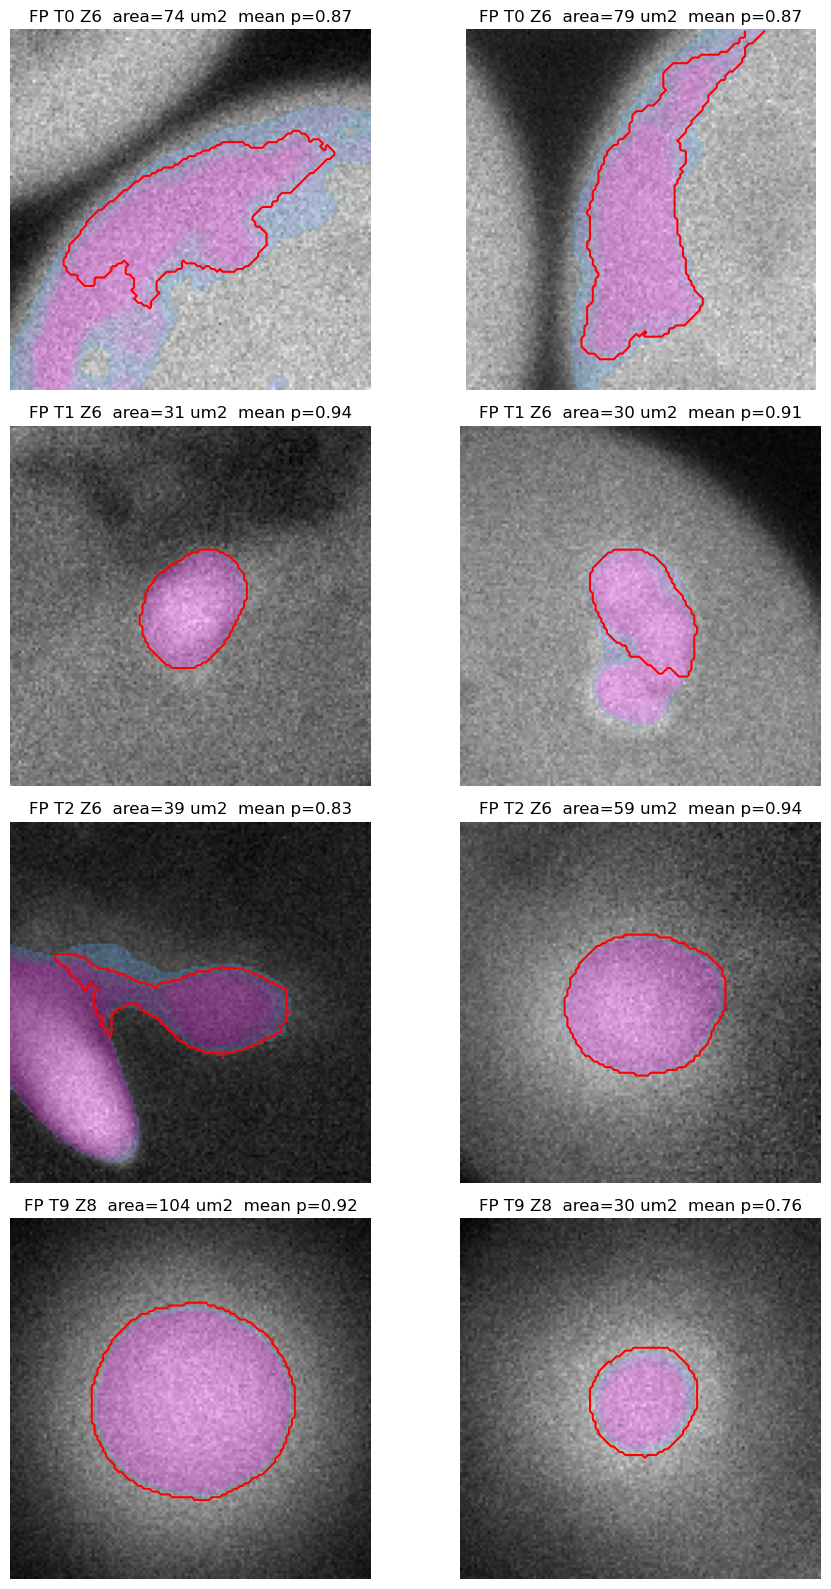


== legacy area gates measured on gold nuclei ==


,value
gold_column_n_final,19
gold_area_cv_final,0.18889
gold_median_area_final_um2,385.856084
legacy_area_cv_gate,0.12
legacy_median_area_gate_um2,320.0
gold_pass_area_cv,False
gold_pass_median_area,True
gold_plane_roi_n_final,233
gold_plane_roi_median_um2,235.094844


Saved post-audit tables/report to /home/tdeibert/Projects/Nuclear_Scaling/Models/runs/Vulcan_2.5.3_iezqw_ddfccb93b8/qc


In [32]:
"""Drop-in post-training operating-point audit for Vulcan 2.5.3.

Run after H1-H4. Reuses segtest_prob.tif; it never reruns inference or changes
models/pools. It writes compact QC tables and figures under cfg.qc_dir.
"""

from IPython.display import display


def _pa_match(lab, gold_locs, box, iou_min=P3_MATCH_IOU, keep_fp=False):
    """Exact H3 matching, with optional unmatched predicted regions."""
    y0, x0 = box[:2]
    border = set(np.unique(np.r_[lab[0], lab[-1], lab[:, 0], lab[:, -1]]))
    preds = [r for r in measure.regionprops(lab) if r.label not in border]
    pairs = []
    for gi, ((a, b, c, d), gm) in enumerate(gold_locs):
        ga = int(gm.sum())
        for r in preds:
            pa, pb, pc, pd_ = r.bbox
            ya, xa = max(a-y0, pa), max(b-x0, pb)
            yb, xb = min(c-y0, pc), min(d-x0, pd_)
            if ya >= yb or xa >= xb:
                continue
            inter = int((gm[ya-(a-y0):yb-(a-y0), xa-(b-x0):xb-(b-x0)] &
                         (lab[ya:yb, xa:xb] == r.label)).sum())
            if inter:
                pairs.append((inter/(ga+r.area-inter), gi, r.label, r.area/ga))
    ug, up, ious, ratios = set(), set(), [], []
    for iou, gi, pl, ratio in sorted(pairs, reverse=True):
        if iou < iou_min:
            break
        if gi in ug or pl in up:
            continue
        ug.add(gi); up.add(pl); ious.append(iou); ratios.append(ratio)
    out = dict(tp=len(ious), fp=len(preds)-len(up), fn=len(gold_locs)-len(ug),
               sum_iou=float(np.sum(ious)), area_ratios=ratios)
    if keep_fp:
        out["fp_regions"] = [r for r in preds if r.label not in up]
    return out


def _pa_filter_lab(lab, core, eq=None, zoff=None, mean_p=0.0, min_px=0,
                   eq_min=None, zmax=None):
    out = np.zeros_like(lab)
    for r in measure.regionprops(lab):
        m = lab[r.slice] == r.label
        if r.area < min_px or float(core[r.slice][m].mean()) < mean_p:
            continue
        if eq_min is not None and (eq is None or float(eq[r.slice][m].mean()) < eq_min):
            continue
        if zmax is not None and (zoff is None or float(np.abs(zoff[r.slice][m]).mean()) > zmax):
            continue
        out[r.slice][m] = r.label
    return out


def _pa_summary(plane_rows, keys):
    d = pd.DataFrame(plane_rows)
    g = d.groupby(keys, dropna=False).agg(tp=("tp", "sum"), fp=("fp", "sum"),
                                          fn=("fn", "sum"), sum_iou=("sum_iou", "sum"))
    g["precision"] = g.tp / (g.tp + g.fp).clip(lower=1)
    g["recall"] = g.tp / (g.tp + g.fn).clip(lower=1)
    g["f1"] = 2*g.precision*g.recall/(g.precision+g.recall).replace(0, np.nan)
    g["matched_iou"] = g.sum_iou/g.tp.clip(lower=1)
    return g.reset_index()


def _pa_pick(overall, recall_floor=0.90):
    ok = overall[overall.recall >= recall_floor]
    pool = ok if len(ok) else overall
    return pool.sort_values(["f1", "precision", "fp"], ascending=[False, False, True]).iloc[0]


def _pa_gold_gate_benchmark(gold, meta, box, cfg):
    """Gold equatorial ROI areas, one validated Z-column per biological nucleus."""
    p = cfg.reviewed_root / "z_cluster_flags.csv"
    out = {}
    if p.exists():
        zc = pd.read_csv(p)
        valid = zc.validated.astype(str).str.lower().isin(["true", "1"])
        inside = ((zc.cx > box[1]) & (zc.cx < box[3]) &
                  (zc.cy > box[0]) & (zc.cy < box[2]))
        zc = zc[valid & inside & zc.t.isin(meta["t_range"])]
        zc["gold_eq_area_um2"] = np.pi*(zc.r_eq_px*cfg.pixel_size_um)**2
        final = zc[zc.t == max(meta["t_range"])].gold_eq_area_um2
        out["gold_column_n_final"] = int(len(final))
        out["gold_area_cv_final"] = float(final.std()/final.mean()) if len(final) > 1 else np.nan
        out["gold_median_area_final_um2"] = float(final.median()) if len(final) else np.nan
        out["legacy_area_cv_gate"] = float(cfg.gate_area_cv_final)
        out["legacy_median_area_gate_um2"] = float(cfg.gate_median_area_final_um2)
        out["gold_pass_area_cv"] = bool(out["gold_area_cv_final"] <= cfg.gate_area_cv_final) if len(final)>1 else None
        out["gold_pass_median_area"] = bool(out["gold_median_area_final_um2"] >= cfg.gate_median_area_final_um2) if len(final) else None
    # Per-plane gold is reported separately; it is not equivalent to a best-Z nucleus.
    tmax = max(meta["t_range"])
    plane_areas = [float(m.sum())*cfg.pixel_size_um**2 for (t, _), locs in gold.items()
                   if t == tmax for _, m in locs]
    out["gold_plane_roi_n_final"] = len(plane_areas)
    out["gold_plane_roi_median_um2"] = float(np.median(plane_areas)) if plane_areas else np.nan
    return out


def vulcan_post_audit(prob_path=None, cfg=cfg,
                      mean_p_grid=(0.45, 0.50, 0.55, 0.60, 0.65, 0.70, 0.75),
                      min_area_um2_grid=(0, 25, 50, 75, 100, 125, 150),
                      eq_grid=(None, 0.4, 0.5, 0.6),
                      zmax_grid=(None, 2.0, 4.0, 6.0), recall_floor=0.90):
    """Audit component confidence/size and optional equatorial/Z rejection."""
    prob_path = Path(prob_path or (cfg.qc_dir / "segtest_prob.tif"))
    meta_path = prob_path.with_suffix(".json")
    if not prob_path.exists() or not meta_path.exists():
        raise FileNotFoundError("Run H4 once; segtest_prob.tif/json are required")
    meta = json.loads(meta_path.read_text(encoding="utf8"))
    ch = {n:i for i,n in enumerate(meta["channels"])}
    for required in ("nucleus_interior", "nucleus_edge"):
        if required not in ch:
            raise RuntimeError(f"Probability volume lacks {required}")
    box = tuple(meta["box"]); mm = tiff.memmap(str(prob_path))
    hs = load_memmap_tiff(cfg.image_file)
    gold = p3_gold_in_box(box, meta["t_range"], meta["z_range"], cfg)
    px2 = cfg.pixel_size_um**2
    min_grid = tuple(float(x) for x in min_area_um2_grid)
    eq_available = "nucleus_equatorial" in ch
    z_available = "z_offset" in ch
    eq_grid = tuple(eq_grid) if eq_available else (None,)
    zmax_grid = tuple(zmax_grid) if z_available else (None,)
    print(f"Reusing {prob_path}; channels={meta['channels']}")
    print(f"Gold ROIs in holdout: {sum(map(len,gold.values()))}; no model/pool files will change")

    # Watershed once per plane. All sweeps filter those fixed production components.
    cache, sweep_rows = {}, []
    for ti,t in enumerate(meta["t_range"]):
        for zi,z in enumerate(meta["z_range"]):
            core = np.asarray(mm[ti,zi,ch["nucleus_interior"]], np.float32)
            edge = np.asarray(mm[ti,zi,ch["nucleus_edge"]], np.float32)
            eq = np.asarray(mm[ti,zi,ch["nucleus_equatorial"]], np.float32) if eq_available else None
            zo = np.asarray(mm[ti,zi,ch["z_offset"]], np.float32) if z_available else None
            nls = read_crop(hs,t,z,cfg.nucleus_channel_idx,box).astype(np.float32)
            base = watershed_nuclei(nls,core,edge,cfg) if cfg.use_watershed_postproc else measure.label(core>cfg.mask_threshold)
            cache[(ti,zi)] = (core,eq,zo,nls,base)
            for mp in mean_p_grid:
                for au in min_grid:
                    lab = _pa_filter_lab(base,core,mean_p=float(mp),min_px=int(np.ceil(au/px2)))
                    sweep_rows.append(dict(mean_p=float(mp),min_area_um2=au,t=int(t),z=int(z),
                                           **_pa_match(lab,gold.get((t,z),[]),box)))
    by_t = _pa_summary(sweep_rows,["mean_p","min_area_um2","t"])
    overall = _pa_summary(sweep_rows,["mean_p","min_area_um2"])
    t0 = by_t[by_t.t==0][["mean_p","min_area_um2","fp"]].rename(columns={"fp":"t0_fp"})
    overall = overall.merge(t0,on=["mean_p","min_area_um2"],how="left").fillna({"t0_fp":0})
    chosen = _pa_pick(overall,recall_floor)
    base_mp, base_au = float(chosen.mean_p), float(chosen.min_area_um2)

    print("\n== component confidence / minimum-area sweep ==")
    display(overall.sort_values("f1",ascending=False).head(15).round(4))
    print(f"Base recommendation: mean_p >= {base_mp:.2f}, area >= {base_au:.0f} um2; "
          f"precision={chosen.precision:.3f}, recall={chosen.recall:.3f}, F1={chosen.f1:.3f}, T0 FP={int(chosen.t0_fp)}")

    # Conditional equatorial and |z-offset| rejection at the selected operating point.
    filt_rows=[]
    for ti,t in enumerate(meta["t_range"]):
        for zi,z in enumerate(meta["z_range"]):
            core,eq,zo,nls,base=cache[(ti,zi)]
            for eqmin in eq_grid:
                for zmax in zmax_grid:
                    lab=_pa_filter_lab(base,core,eq,zo,base_mp,int(np.ceil(base_au/px2)),eqmin,zmax)
                    filt_rows.append(dict(eq_min=-1 if eqmin is None else float(eqmin),
                                          zmax_um=-1 if zmax is None else float(zmax),t=int(t),z=int(z),
                                          **_pa_match(lab,gold.get((t,z),[]),box)))
    filt_t=_pa_summary(filt_rows,["eq_min","zmax_um","t"])
    filt=_pa_summary(filt_rows,["eq_min","zmax_um"])
    t0f=filt_t[filt_t.t==0][["eq_min","zmax_um","fp"]].rename(columns={"fp":"t0_fp"})
    filt=filt.merge(t0f,on=["eq_min","zmax_um"],how="left").fillna({"t0_fp":0})
    selected=_pa_pick(filt,recall_floor)
    eq_sel=None if selected.eq_min<0 else float(selected.eq_min)
    z_sel=None if selected.zmax_um<0 else float(selected.zmax_um)
    print("\n== optional equatorial / z-offset rejection ==")
    display(filt.sort_values("f1",ascending=False).round(4))
    print(f"Final recommendation: eq_min={eq_sel}, |z_offset| max={z_sel}; "
          f"precision={selected.precision:.3f}, recall={selected.recall:.3f}, F1={selected.f1:.3f}, T0 FP={int(selected.t0_fp)}")

    final_t=filt_t[(filt_t.eq_min==selected.eq_min)&(filt_t.zmax_um==selected.zmax_um)].copy()
    print("\n== recommended operating point by timepoint ==")
    display(final_t.drop(columns="sum_iou").round(4))

    # Representative unmatched predictions, deliberately enriched for T0/T1/T2/T9.
    examples=[]
    for ti,t in enumerate(meta["t_range"]):
        if t not in (0,1,2,9): continue
        for zi,z in enumerate(meta["z_range"]):
            core,eq,zo,nls,base=cache[(ti,zi)]
            lab=_pa_filter_lab(base,core,eq,zo,base_mp,int(np.ceil(base_au/px2)),eq_sel,z_sel)
            mt=_pa_match(lab,gold.get((t,z),[]),box,keep_fp=True)
            for r in mt["fp_regions"]:
                if sum(e["t"]==t for e in examples)>=2: break
                cy,cx=map(int,r.centroid); rad=64
                a,b=max(0,cy-rad),max(0,cx-rad); c,d=min(lab.shape[0],cy+rad),min(lab.shape[1],cx+rad)
                examples.append(dict(t=t,z=z,nls=nls[a:c,b:d].copy(),core=core[a:c,b:d].copy(),
                                     mask=(lab[a:c,b:d]==r.label),area=r.area*px2,
                                     mean_p=float(core[lab==r.label].mean())))
    if examples:
        fig,axs=plt.subplots(int(np.ceil(len(examples)/2)),2,figsize=(10,4*np.ceil(len(examples)/2)))
        axs=np.atleast_1d(axs).ravel()
        for ax,e in zip(axs,examples):
            ax.imshow(e["nls"],cmap="gray"); ax.contour(e["mask"],[0.5],colors="red",linewidths=1.5)
            ax.imshow(np.ma.masked_where(e["core"]<0.25,e["core"]),cmap="cool",alpha=.25,vmin=0,vmax=1)
            ax.set_title(f"FP T{e['t']} Z{e['z']}  area={e['area']:.0f} um2  mean p={e['mean_p']:.2f}")
            ax.axis("off")
        for ax in axs[len(examples):]: ax.axis("off")
        plt.tight_layout(); plt.show()

    gates=_pa_gold_gate_benchmark(gold,meta,box,cfg)
    print("\n== legacy area gates measured on gold nuclei ==")
    display(pd.DataFrame([gates]).T.rename(columns={0:"value"}))

    qc=cfg.qc_dir; qc.mkdir(parents=True,exist_ok=True)
    overall.to_csv(qc/"postaudit_operating_grid.csv",index=False)
    by_t.to_csv(qc/"postaudit_operating_grid_by_t.csv",index=False)
    filt.to_csv(qc/"postaudit_eq_z_grid.csv",index=False)
    final_t.to_csv(qc/"postaudit_recommended_by_t.csv",index=False)
    report=dict(prob_path=str(prob_path),component_filter=dict(mean_p=base_mp,min_area_um2=base_au),
                optional_filter=dict(eq_min=eq_sel,zmax_um=z_sel),recall_floor=recall_floor,
                selected={k:(v.item() if hasattr(v,"item") else v) for k,v in selected.to_dict().items()},
                gold_gate_benchmark=gates)
    (qc/"postaudit_report.json").write_text(json.dumps(report,indent=2,default=str)+"\n",encoding="utf8")
    print("Saved post-audit tables/report to",qc)
    return dict(operating_grid=overall,by_timepoint=by_t,filter_grid=filt,
                recommended_by_timepoint=final_t,gold_gates=gates,report=report)


POST_AUDIT = vulcan_post_audit()

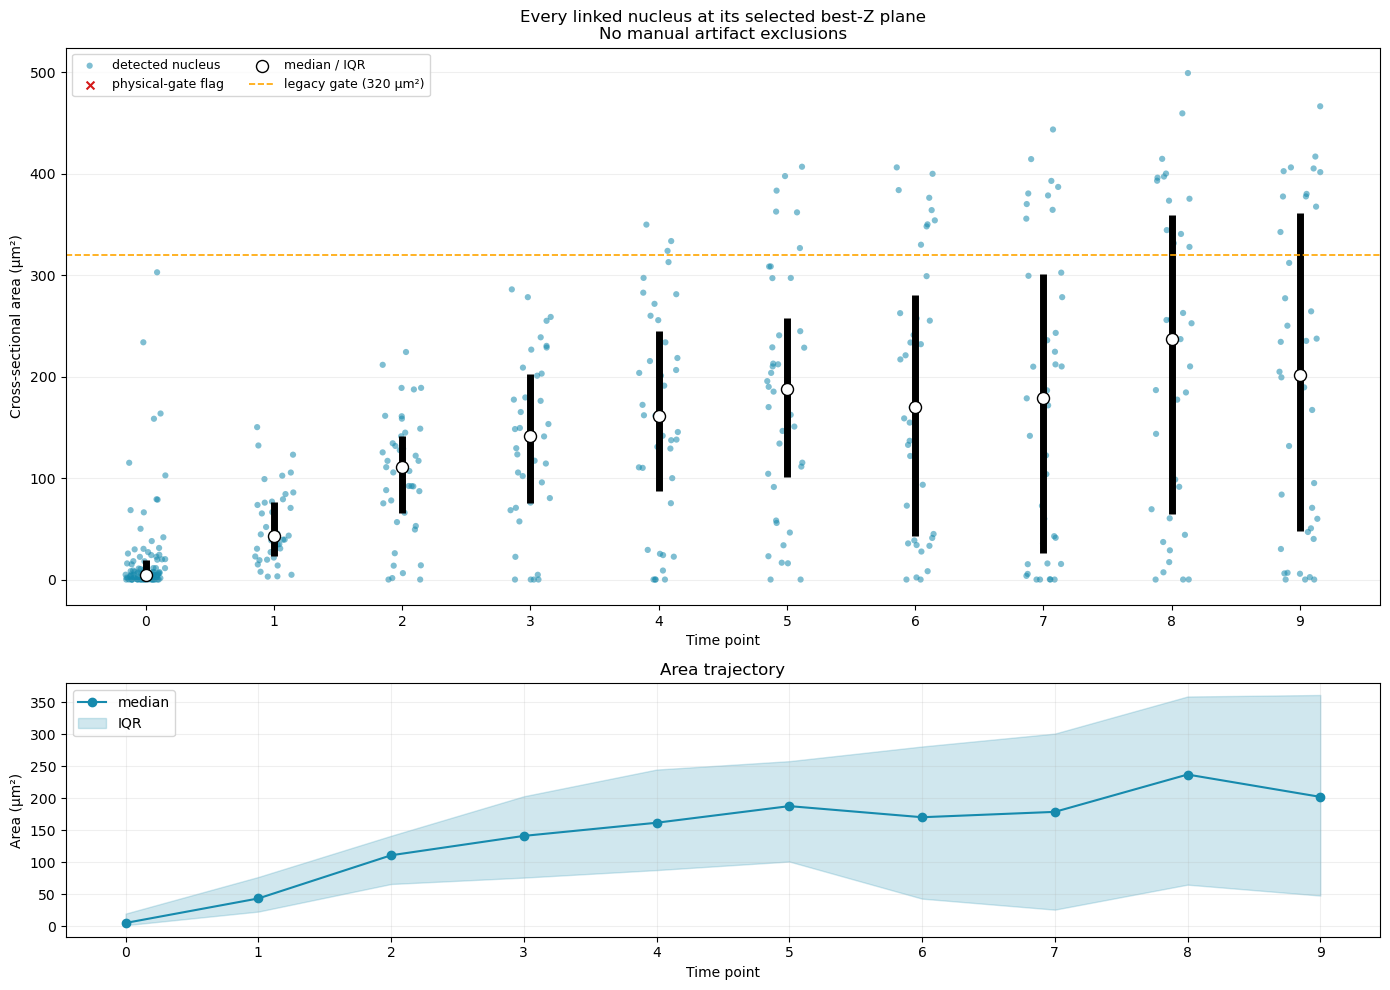

Best-Z nuclei plotted: 442
Red crosses are automated physical flags, not manually confirmed artifacts.


,t,n,mean,median,std,minimum,q25,q75,maximum,cv,iqr,physical_flags
0,0,97,21.71,4.99,47.21,0.03,1.45,19.59,302.83,2.17,18.14,0
1,1,37,53.52,43.31,38.18,2.90,22.76,76.84,150.23,0.71,54.08,0
2,2,41,103.61,110.77,59.56,0.03,65.86,141.22,224.27,0.57,75.36,0
3,3,37,137.11,141.06,84.90,0.03,75.84,202.98,285.98,0.62,127.15,0
4,4,39,160.59,161.61,106.66,0.03,87.60,244.73,349.83,0.66,157.13,0
5,5,40,184.26,187.60,118.36,0.03,101.00,257.86,406.87,0.64,156.86,0
6,6,39,186.27,170.24,132.88,0.03,42.98,280.79,406.21,0.71,237.81,0
7,7,39,177.32,178.61,149.02,0.03,25.77,300.93,443.57,0.84,275.15,0
8,8,35,219.25,236.97,156.02,0.03,64.84,358.91,499.18,0.71,294.07,0
9,9,38,198.56,202.06,155.60,0.03,47.80,361.30,466.44,0.78,313.50,0


In [34]:
"""Drop-in cross-sectional area audit for the H4 segmentation test."""

from IPython.display import display


def plot_nuclear_cross_sections(cfg=cfg, detections=None, seed=42):
    """Plot one selected best-Z cross-section for every linked nucleus."""
    if detections is None:
        if "SEGTEST" in globals() and isinstance(SEGTEST, dict):
            detections = SEGTEST.get("detections")
        if detections is None:
            p = cfg.qc_dir / "segtest_detections.csv"
            if not p.exists():
                raise FileNotFoundError(f"{p} not found; run H4 first")
            detections = pd.read_csv(p)
    d = detections.copy()
    if d.empty or "is_best_z" not in d:
        raise ValueError("No best-Z detections are available")
    if d.is_best_z.dtype == object:
        d["is_best_z"] = d.is_best_z.astype(str).str.lower().isin(["true", "1"])
    best = (d[d.is_best_z].sort_values("area_um2", ascending=False)
            .drop_duplicates(["t", "nucleus_id"]).copy())
    best["physical_flag"] = False
    if "rho0" in best:
        lo, hi = cfg.rho0_impossible_window
        best["physical_flag"] |= best.rho0.between(lo, hi, inclusive="both")
    if "chord_ok" in best:
        chord = (best.chord_ok.astype(str).str.lower().isin(["true", "1"])
                 if best.chord_ok.dtype == object else best.chord_ok.astype(bool))
        best["physical_flag"] |= ~chord

    q = best.groupby("t").area_um2
    stats = q.agg(n="size", mean="mean", median="median", std="std",
                  minimum="min", q25=lambda x:x.quantile(.25),
                  q75=lambda x:x.quantile(.75), maximum="max")
    stats["cv"] = stats["std"] / stats["mean"]
    stats["iqr"] = stats.q75 - stats.q25
    stats["physical_flags"] = best.groupby("t").physical_flag.sum()
    stats = stats.reset_index()

    times = sorted(best.t.astype(int).unique())
    rng = np.random.default_rng(seed)
    fig, (ax, trend) = plt.subplots(2, 1, figsize=(14, 10),
                                    gridspec_kw={"height_ratios":[2.2, 1]})
    for t in times:
        x = best[best.t == t]
        normal, flagged = x[~x.physical_flag], x[x.physical_flag]
        ax.scatter(t+rng.uniform(-.16,.16,len(normal)),normal.area_um2,s=20,alpha=.55,
                   color="#168aad",edgecolors="none",label="detected nucleus" if t==times[0] else None)
        ax.scatter(t+rng.uniform(-.16,.16,len(flagged)),flagged.area_um2,s=32,alpha=.9,
                   color="#d00000",marker="x",label="physical-gate flag" if t==times[0] else None)
        row=stats[stats.t==t].iloc[0]
        ax.vlines(t,row.q25,row.q75,color="black",lw=5)
        ax.scatter(t,row["median"],s=75,color="white",edgecolor="black",zorder=5,
                   label="median / IQR" if t==times[0] else None)
    ax.axhline(cfg.gate_median_area_final_um2,color="orange",ls="--",lw=1.2,
               label=f"legacy gate ({cfg.gate_median_area_final_um2:g} µm²)")
    ax.set(title="Every linked nucleus at its selected best-Z plane\nNo manual artifact exclusions",
           xlabel="Time point",ylabel="Cross-sectional area (µm²)")
    ax.set_xticks(times); ax.grid(axis="y",alpha=.2); ax.legend(ncol=2,fontsize=9)

    trend.plot(stats.t,stats["median"],"o-",color="#168aad",label="median")
    trend.fill_between(stats.t.to_numpy(),stats.q25.to_numpy(),stats.q75.to_numpy(),
                       color="#168aad",alpha=.2,label="IQR")
    trend.set(title="Area trajectory",xlabel="Time point",ylabel="Area (µm²)")
    trend.set_xticks(times); trend.grid(alpha=.2); trend.legend()
    plt.tight_layout(); plt.show()
    print(f"Best-Z nuclei plotted: {len(best)}")
    print("Red crosses are automated physical flags, not manually confirmed artifacts.")
    display(stats.round(2))
    return dict(best_z=best,statistics=stats)


NUCLEAR_AREA_AUDIT = plot_nuclear_cross_sections()

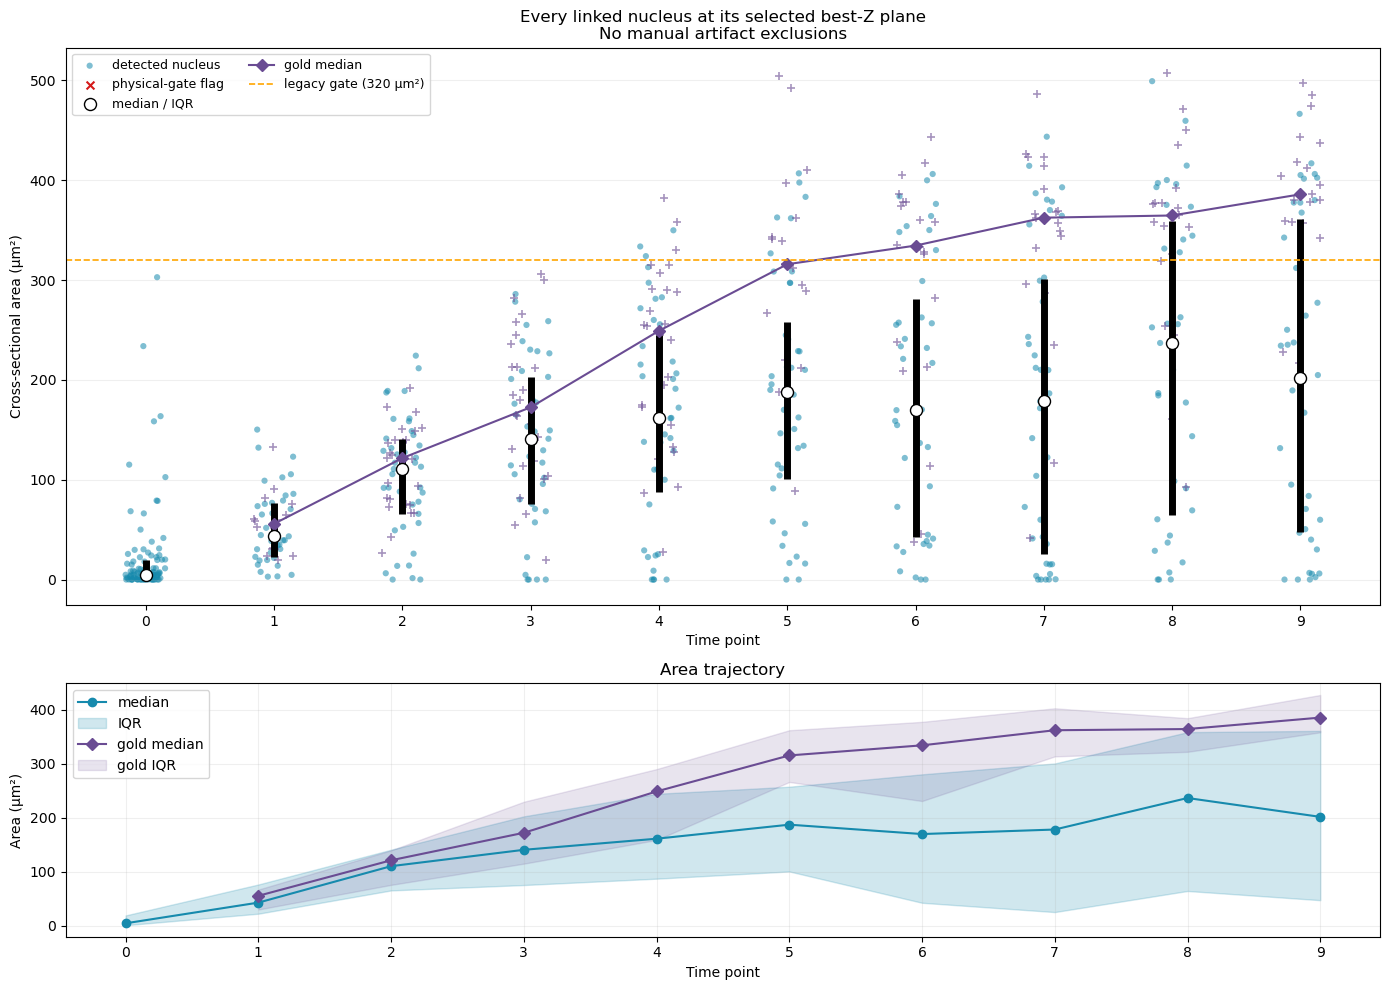

Best-Z nuclei plotted: 442
Red crosses are automated physical flags, not manually confirmed artifacts.
Purple crosses are validated gold nuclei from the same holdout tile at their equatorial section.

Predicted best-Z areas:


,t,n,mean,median,std,minimum,q25,q75,maximum,cv,iqr,physical_flags
0,0,97,21.71,4.99,47.21,0.03,1.45,19.59,302.83,2.17,18.14,0
1,1,37,53.52,43.31,38.18,2.90,22.76,76.84,150.23,0.71,54.08,0
2,2,41,103.61,110.77,59.56,0.03,65.86,141.22,224.27,0.57,75.36,0
3,3,37,137.11,141.06,84.90,0.03,75.84,202.98,285.98,0.62,127.15,0
4,4,39,160.59,161.61,106.66,0.03,87.60,244.73,349.83,0.66,157.13,0
5,5,40,184.26,187.60,118.36,0.03,101.00,257.86,406.87,0.64,156.86,0
6,6,39,186.27,170.24,132.88,0.03,42.98,280.79,406.21,0.71,237.81,0
7,7,39,177.32,178.61,149.02,0.03,25.77,300.93,443.57,0.84,275.15,0
8,8,35,219.25,236.97,156.02,0.03,64.84,358.91,499.18,0.71,294.07,0
9,9,38,198.56,202.06,155.60,0.03,47.80,361.30,466.44,0.78,313.50,0



Gold equatorial areas:


,t,n,mean,median,std,minimum,q25,q75,maximum,cv,iqr
0,1,16,55.61,55.90,30.12,19.67,30.50,67.47,132.73,0.54,36.97
1,2,25,112.45,121.69,42.86,26.28,76.16,140.13,191.93,0.38,63.97
2,3,26,173.19,172.58,78.17,19.42,115.43,230.07,305.66,0.45,114.64
3,4,26,226.22,249.15,91.68,27.48,159.24,290.49,382.47,0.41,131.25
4,5,17,316.21,315.81,105.37,88.71,266.70,362.46,504.71,0.33,95.76
5,6,20,298.11,334.51,119.13,37.28,231.39,377.98,443.29,0.40,146.58
6,7,19,336.24,362.46,107.75,41.25,314.04,403.10,486.76,0.32,89.06
7,8,19,346.55,364.66,101.50,92.54,322.51,384.77,507.31,0.29,62.26
8,9,19,386.93,385.86,73.09,216.62,358.63,427.72,496.98,0.19,69.09


In [35]:
"""Drop-in cross-sectional area audit for the H4 segmentation test."""

from IPython.display import display


def plot_nuclear_cross_sections(cfg=cfg, detections=None, seed=42):
    """Plot one selected best-Z cross-section for every linked nucleus."""
    if detections is None:
        if "SEGTEST" in globals() and isinstance(SEGTEST, dict):
            detections = SEGTEST.get("detections")
        if detections is None:
            p = cfg.qc_dir / "segtest_detections.csv"
            if not p.exists():
                raise FileNotFoundError(f"{p} not found; run H4 first")
            detections = pd.read_csv(p)
    d = detections.copy()
    if d.empty or "is_best_z" not in d:
        raise ValueError("No best-Z detections are available")
    if d.is_best_z.dtype == object:
        d["is_best_z"] = d.is_best_z.astype(str).str.lower().isin(["true", "1"])
    best = (d[d.is_best_z].sort_values("area_um2", ascending=False)
            .drop_duplicates(["t", "nucleus_id"]).copy())
    best["physical_flag"] = False
    if "rho0" in best:
        lo, hi = cfg.rho0_impossible_window
        best["physical_flag"] |= best.rho0.between(lo, hi, inclusive="both")
    if "chord_ok" in best:
        chord = (best.chord_ok.astype(str).str.lower().isin(["true", "1"])
                 if best.chord_ok.dtype == object else best.chord_ok.astype(bool))
        best["physical_flag"] |= ~chord

    q = best.groupby("t").area_um2
    stats = q.agg(n="size", mean="mean", median="median", std="std",
                  minimum="min", q25=lambda x:x.quantile(.25),
                  q75=lambda x:x.quantile(.75), maximum="max")
    stats["cv"] = stats["std"] / stats["mean"]
    stats["iqr"] = stats.q75 - stats.q25
    stats["physical_flags"] = best.groupby("t").physical_flag.sum()
    stats = stats.reset_index()

    # Same spatial holdout and same one-best-Z/equatorial-section criterion for gold.
    gold = pd.DataFrame()
    zpath = cfg.reviewed_root / "z_cluster_flags.csv"
    mpath = cfg.qc_dir / "segtest_prob.json"
    if zpath.exists() and mpath.exists():
        meta = json.loads(mpath.read_text(encoding="utf8"))
        y0, x0, y1, x1 = meta["box"]
        zc = pd.read_csv(zpath)
        valid = zc.validated.astype(str).str.lower().isin(["true", "1"])
        inside = zc.cy.between(y0, y1, inclusive="neither") & zc.cx.between(x0, x1, inclusive="neither")
        source_ok = zc.source.eq("gold") if "source" in zc else True
        gold = zc[valid & inside & source_ok & zc.t.isin(meta["t_range"])].copy()
        # r_eq_px is the equivalent radius of the manually traced best-Z ROI.
        gold["area_um2"] = np.pi * (gold.r_eq_px * cfg.pixel_size_um) ** 2
    gold_stats = pd.DataFrame()
    if len(gold):
        gq = gold.groupby("t").area_um2
        gold_stats = gq.agg(n="size", mean="mean", median="median", std="std",
                            minimum="min", q25=lambda x:x.quantile(.25),
                            q75=lambda x:x.quantile(.75), maximum="max")
        gold_stats["cv"] = gold_stats["std"] / gold_stats["mean"]
        gold_stats["iqr"] = gold_stats.q75 - gold_stats.q25
        gold_stats = gold_stats.reset_index()

    times = sorted(best.t.astype(int).unique())
    rng = np.random.default_rng(seed)
    fig, (ax, trend) = plt.subplots(2, 1, figsize=(14, 10),
                                    gridspec_kw={"height_ratios":[2.2, 1]})
    for t in times:
        x = best[best.t == t]
        normal, flagged = x[~x.physical_flag], x[x.physical_flag]
        ax.scatter(t+rng.uniform(-.16,.16,len(normal)),normal.area_um2,s=20,alpha=.55,
                   color="#168aad",edgecolors="none",label="detected nucleus" if t==times[0] else None)
        ax.scatter(t+rng.uniform(-.16,.16,len(flagged)),flagged.area_um2,s=32,alpha=.9,
                   color="#d00000",marker="x",label="physical-gate flag" if t==times[0] else None)
        row=stats[stats.t==t].iloc[0]
        ax.vlines(t,row.q25,row.q75,color="black",lw=5)
        ax.scatter(t,row["median"],s=75,color="white",edgecolor="black",zorder=5,
                   label="median / IQR" if t==times[0] else None)
        gx = gold[gold.t == t]
        if len(gx):
            ax.scatter(t+rng.uniform(-.16,.16,len(gx)),gx.area_um2,s=30,alpha=.6,
                       color="#6a4c93",marker="+",linewidths=1.2,
                       label="gold nucleus" if t==times[0] else None)
    if len(gold_stats):
        ax.plot(gold_stats.t,gold_stats["median"],"D-",color="#6a4c93",lw=1.5,
                label="gold median")
    ax.axhline(cfg.gate_median_area_final_um2,color="orange",ls="--",lw=1.2,
               label=f"legacy gate ({cfg.gate_median_area_final_um2:g} µm²)")
    ax.set(title="Every linked nucleus at its selected best-Z plane\nNo manual artifact exclusions",
           xlabel="Time point",ylabel="Cross-sectional area (µm²)")
    ax.set_xticks(times); ax.grid(axis="y",alpha=.2); ax.legend(ncol=2,fontsize=9)

    trend.plot(stats.t,stats["median"],"o-",color="#168aad",label="median")
    trend.fill_between(stats.t.to_numpy(),stats.q25.to_numpy(),stats.q75.to_numpy(),
                       color="#168aad",alpha=.2,label="IQR")
    if len(gold_stats):
        trend.plot(gold_stats.t,gold_stats["median"],"D-",color="#6a4c93",label="gold median")
        trend.fill_between(gold_stats.t.to_numpy(),gold_stats.q25.to_numpy(),gold_stats.q75.to_numpy(),
                           color="#6a4c93",alpha=.15,label="gold IQR")
    trend.set(title="Area trajectory",xlabel="Time point",ylabel="Area (µm²)")
    trend.set_xticks(times); trend.grid(alpha=.2); trend.legend()
    plt.tight_layout(); plt.show()
    print(f"Best-Z nuclei plotted: {len(best)}")
    print("Red crosses are automated physical flags, not manually confirmed artifacts.")
    print("Purple crosses are validated gold nuclei from the same holdout tile at their equatorial section.")
    print("\nPredicted best-Z areas:")
    display(stats.round(2))
    if len(gold_stats):
        print("\nGold equatorial areas:")
        display(gold_stats.round(2))
    else:
        print("No validated gold columns were found in the segmentation-test holdout tile.")
    return dict(best_z=best,statistics=stats,gold=gold,gold_statistics=gold_stats)


NUCLEAR_AREA_AUDIT = plot_nuclear_cross_sections()

counts per timepoint:
class  gold, other plane  no gold nucleus  on gold, same plane
t                                                             
0                      0               97                    0
1                      2                6                   29
2                      2                2                   37
3                      1                1                   35
4                      2                2                   35
5                      1                2                   37
6                      1                3                   35
7                      0                3                   36
8                      0                2                   33
9                      1                2                   35

median area (um2) per timepoint:
class  gold, other plane  no gold nucleus  on gold, same plane
t                                                             
0                    NaN              5.0                  NaN

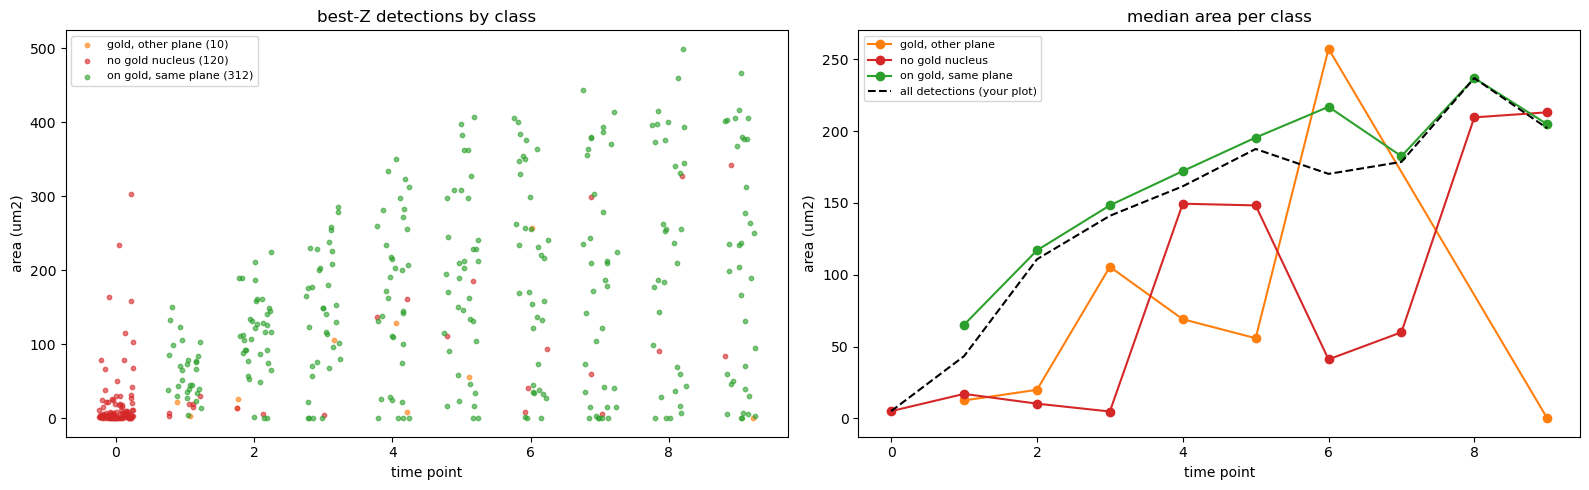

In [36]:
# ============================================================
# Divergence diagnosis: what are the small detections? (ONE-OFF, informational; writes nothing)
# ============================================================
# Classifies every best-Z detection against the gold nucleus ROIs by where its
# centroid falls (gold traces every nucleus, so "no gold" means no nucleus):
#   on gold, same plane   centroid inside a gold ROI at the same (t, z)
#                         -> a real nucleus; area_ratio = detection / gold area
#                            (well below 1 = fragment or under-segmentation)
#   gold, other plane     inside a gold ROI of the same t within +/-DZ planes only
#                         -> a top/bottom section of a real nucleus picked as its own
#                            best-Z (3D linking split it, or best-Z chose a cap)
#   no gold nucleus       no gold ROI within +/-DZ planes -> false positive
# Then plots area vs time per class, with the gold median, and prints counts and
# medians per timepoint. If "on gold" tracks the gold median, the size model is fine
# and the divergence is contamination, not undersizing.
DET_CSV = cfg.qc_dir / "segtest_detections.csv"   # point at the detections table behind your plot
DZ = 3

det = pd.read_csv(DET_CSV)
need = {"t", "z", "cx", "cy", "area_um2", "is_best_z"}
assert need <= set(det.columns), f"detections table lacks {need - set(det.columns)}"
best = det[det.is_best_z].copy()
hs = load_memmap_tiff(cfg.image_file)
rois = p2_read_rois({"nuc": ROI_ROOT / "NucleiRoiSet.zip", "drop": None, "npc": None},
                    hs.shape[-2:], hs.shape[:2], cfg)
by_tz = {}
for n in rois["nuc"]:
    by_tz.setdefault((n["t"], n["z"]), []).append(n["loc"])

def _hit(t, z, x, y):
    """Area (um2) of the gold ROI at (t, z) containing pixel (x, y), else None."""
    for (a, b, c, d), m in by_tz.get((t, z), []):
        if a <= y < c and b <= x < d and m[y - a, x - b]:
            return float(m.sum()) * cfg.pixel_size_um ** 2
    return None

cls, ratio = [], []
for r in best.itertuples(index=False):
    x, y, t, z = int(round(r.cx)), int(round(r.cy)), int(r.t), int(r.z)
    g = _hit(t, z, x, y)
    if g is not None:
        cls.append("on gold, same plane"); ratio.append(r.area_um2 / g); continue
    near = any(_hit(t, z + s * k, x, y) is not None for k in range(1, DZ + 1) for s in (-1, 1))
    cls.append("gold, other plane" if near else "no gold nucleus"); ratio.append(np.nan)
best["class"], best["area_ratio"] = cls, ratio

gold = pd.DataFrame([dict(t=n["t"], z=n["z"], area=float(n["loc"][1].sum()) * cfg.pixel_size_um ** 2)
                     for n in rois["nuc"]])
gold_best = gold.groupby(["t"]).area.median()       # median over all traced sections, for reference

print("counts per timepoint:")
print(best.pivot_table(index="t", columns="class", values="area_um2", aggfunc="count", fill_value=0).to_string())
print("\nmedian area (um2) per timepoint:")
print(best.pivot_table(index="t", columns="class", values="area_um2", aggfunc="median").round(0).to_string())
print("\non-gold detections: median detection / gold area per t:")
print(best[best["class"] == "on gold, same plane"].groupby("t").area_ratio.median().round(2).to_string())

colors = {"on gold, same plane": "tab:green", "gold, other plane": "tab:orange", "no gold nucleus": "tab:red"}
fig, ax = plt.subplots(1, 2, figsize=(16, 5))
rng = np.random.default_rng(0)
for c, sub in best.groupby("class"):
    ax[0].scatter(sub.t + rng.uniform(-0.25, 0.25, len(sub)), sub.area_um2, s=10, alpha=0.6,
                  color=colors[c], label=f"{c} ({len(sub)})")
    ax[1].plot(sub.groupby("t").area_um2.median(), "o-", color=colors[c], label=c)
for a in ax:
    a.set_xlabel("time point"); a.set_ylabel("area (um2)")
ax[1].plot(best.groupby("t").area_um2.median(), "k--", label="all detections (your plot)")
ax[0].set_title("best-Z detections by class"); ax[1].set_title("median area per class")
ax[0].legend(fontsize=8); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

per gold section, by timepoint (medians; n_det as fractions of sections):
   sections  gold_um2  cover_ws  cover_cc  pmean  none   one  two_plus
t                                                                     
1        91     51.70       1.0       1.0   1.00  0.00  0.98      0.02
2       211     86.35       1.0       1.0   1.00  0.03  0.89      0.08
3       243    137.60       1.0       1.0   1.00  0.00  0.87      0.13
4       258    157.86       1.0       1.0   1.00  0.02  0.89      0.09
5       238    184.91       1.0       1.0   0.99  0.01  0.83      0.16
6       244    200.09       1.0       1.0   1.00  0.01  0.86      0.13
7       236    206.76       1.0       1.0   1.00  0.00  0.84      0.15
8       232    221.11       1.0       1.0   1.00  0.01  0.88      0.11
9       234    235.62       1.0       1.0   1.00  0.02  0.81      0.17


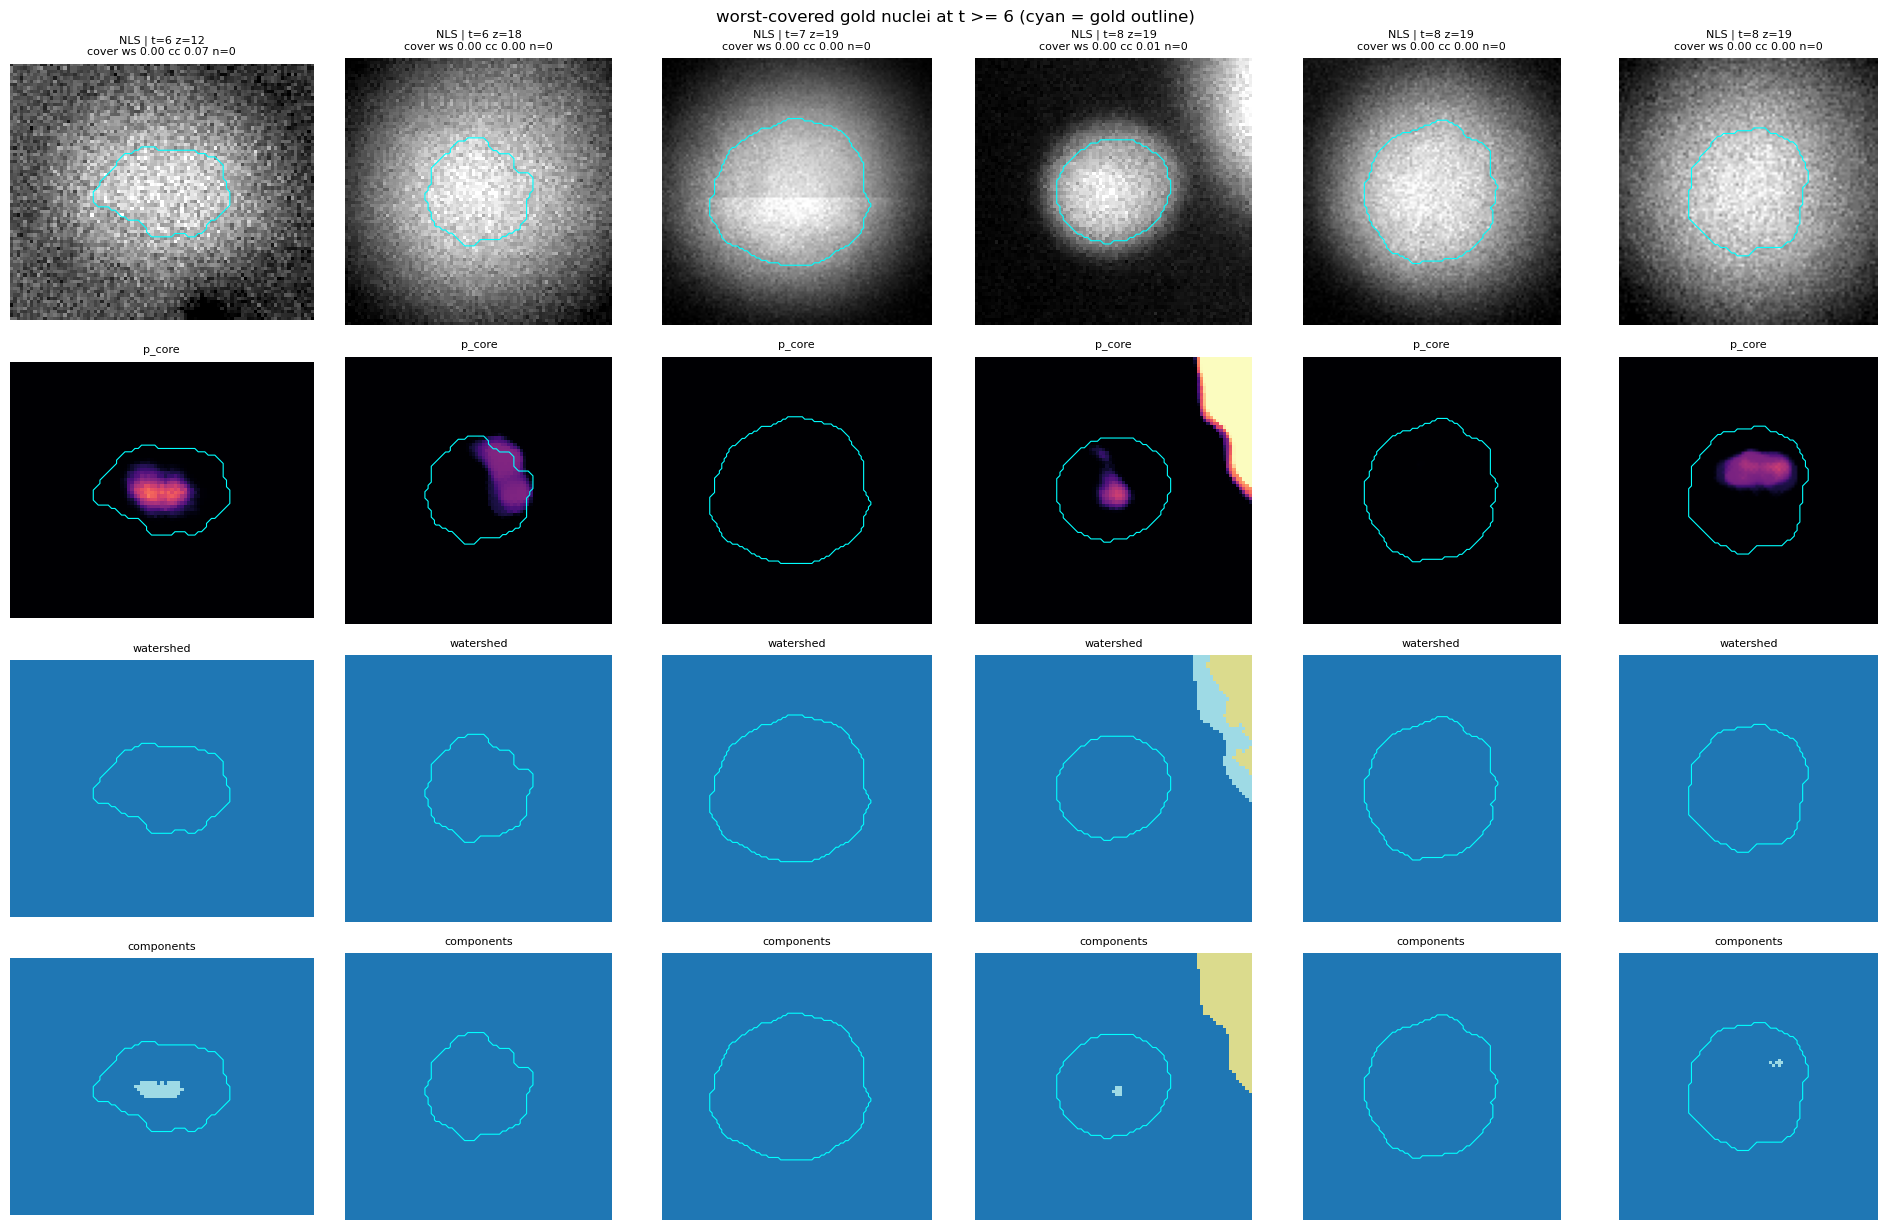

In [37]:
# ============================================================
# Late under-segmentation: fragmentation or holes? (ONE-OFF, informational; writes nothing)
# ============================================================
# For every gold nucleus section (t, z) inside the inferred region, using ALL
# detections (not only best-Z):
#   n_det        detections whose centroid lies inside the gold section
#   cover_ws     (union of watershed instances inside the gold mask) / gold area
#   cover_cc     same with plain connected components of p_core > mask_threshold
#                (no watershed); if cover_cc >> cover_ws the watershed is splitting/
#                shrinking nuclei, if both are low the model leaves holes
#   pmean        mean nucleus probability inside the gold mask
# Gallery: the WORST_N late sections by cover_ws: NLS | p_core | watershed | components,
# gold outline in cyan.
PROB = cfg.qc_dir / "segtest_prob.tif"            # the probability stack behind the detections
LATE_T = 6
WORST_N = 6

meta = json.loads(PROB.with_suffix(".json").read_text())
chn = {n: i for i, n in enumerate(meta["channels"])}
y0, x0, y1, x1 = meta["box"]
pm = tiff.memmap(str(PROB))
rows, cache = [], {}
for ti, t in enumerate(meta["t_range"]):
    for zi, z in enumerate(meta["z_range"]):
        golds = [loc for loc in by_tz.get((t, z), [])
                 if loc[0][0] >= y0 and loc[0][1] >= x0 and loc[0][2] <= y1 and loc[0][3] <= x1]
        if not golds:
            continue
        pc = np.asarray(pm[ti, zi, chn["nucleus_interior"]], np.float32)
        pe = (np.asarray(pm[ti, zi, chn["nucleus_edge"]], np.float32) if "nucleus_edge" in chn
              else np.zeros_like(pc))
        nls = read_crop(hs, t, z, cfg.nucleus_channel_idx, (y0, x0, y1, x1)).astype(np.float32)
        ws = watershed_nuclei(nls, pc, pe, cfg)
        cc = measure.label(pc > cfg.mask_threshold)
        for (a, b, c, d), m in golds:
            sl = (slice(a - y0, c - y0), slice(b - x0, d - x0))
            ids = np.unique(ws[sl][m]); ids = ids[ids > 0]
            rows.append(dict(t=t, z=z, gold_um2=m.sum() * cfg.pixel_size_um ** 2, n_det=len(ids),
                             cover_ws=float((ws[sl][m] > 0).mean()), cover_cc=float((cc[sl][m] > 0).mean()),
                             pmean=float(pc[sl][m].mean()), box=(a, b, c, d)))
            cache[(t, z, a, b)] = (nls, pc, ws, cc, m)
sec = pd.DataFrame(rows)
print("per gold section, by timepoint (medians; n_det as fractions of sections):")
summary = sec.groupby("t").agg(sections=("n_det", "size"), gold_um2=("gold_um2", "median"),
                               cover_ws=("cover_ws", "median"), cover_cc=("cover_cc", "median"),
                               pmean=("pmean", "median"),
                               none=("n_det", lambda s: (s == 0).mean()), one=("n_det", lambda s: (s == 1).mean()),
                               two_plus=("n_det", lambda s: (s >= 2).mean()))
print(summary.round(2).to_string())

worst = sec[sec.t >= LATE_T].nsmallest(WORST_N, "cover_ws")
fig, axes = plt.subplots(4, len(worst), figsize=(3.2 * len(worst), 12.5), squeeze=False)
for col, (_, r) in enumerate(worst.iterrows()):
    a, b, c, d = r.box
    nls, pc, ws, cc, m = cache[(r.t, r.z, a, b)]
    pad = 25
    ya, yb = max(0, a - y0 - pad), min(nls.shape[0], c - y0 + pad)
    xa, xb = max(0, b - x0 - pad), min(nls.shape[1], d - x0 + pad)
    gold_full = np.zeros(nls.shape, bool); gold_full[a - y0:c - y0, b - x0:d - x0] = m
    for row, (img, title) in enumerate([(nls, "NLS"), (pc, "p_core"), (ws, "watershed"), (cc, "components")]):
        axx = axes[row, col]
        crop = img[ya:yb, xa:xb]
        if row == 0:
            lo, hi = np.percentile(crop, [1, 99.5]); axx.imshow(crop, cmap="gray", vmin=lo, vmax=hi)
        elif row == 1:
            axx.imshow(crop, cmap="magma", vmin=0, vmax=1)
        else:
            axx.imshow(crop % 20 if crop.max() else crop, cmap="tab20", interpolation="nearest")
        axx.contour(gold_full[ya:yb, xa:xb], levels=[0.5], colors="cyan", linewidths=0.8)
        axx.set_title(f"{title}" + (f" | t={r.t} z={r.z}\ncover ws {r.cover_ws:.2f} cc {r.cover_cc:.2f} n={r.n_det}"
                                    if row == 0 else ""), fontsize=8)
        axx.axis("off")
fig.suptitle(f"worst-covered gold nuclei at t >= {LATE_T} (cyan = gold outline)")
plt.tight_layout(); plt.show()

## Empty focal-plane supervision audit (read-only)

Inspect saved nuclear labels and per-head weights in the ACTUAL current p3_split.
Reports full class counts and expected epoch exposure under timepoint balancing.
Measures a deterministic sample per split/source/class/timepoint; set max_per_group=None
for a complete scan (potentially expensive). Weighted-pixel exposure is not full loss.

An empty sample class describes the target droplet, not necessarily the whole patch.
Neighboring NLS context is shown for manual review, not automatically labeled as nuclei.
Optional checkpoint predictions are direct-patch pixel diagnostics, not production
instance false-positive rates. Fully-empty patch rates require every nuclear pixel to
be explicitly supervised negative. No TTA, augmentation, or watershed is applied.

Use the original training configuration/pools to investigate historical training;
current notebook defaults alone do not establish what an older run saw.
Do not run this with inference cfg. No patches, labels, model weights or filters change.


In [ ]:
# Run in the TRAINING kernel after configuration and Phase 2/F1 definitions.
# Do not execute patch-generation or training stages just to use this audit.
from pathlib import Path
_audit_folder = Path('/home/tdeibert/Projects/Nuclear_Scaling/Code_Repository/Python/Model_Training')
exec((_audit_folder / 'empty_plane_supervision_audit.py').read_text(encoding='utf8'))
if not all(name in globals() for name in ('p3_split', 'p3_layout', 'HEAD_INDEX')):
    raise RuntimeError('Load training configuration, pool readers, and F1 definitions first.')
_audit_train, _audit_val = p3_split(cfg)
_audit_layout = p3_layout(cfg)

# None = labels/weights/exposure audit only. Set an explicit model path to also
# evaluate predictions, e.g. cfg.model_path(cfg.seeds[0], 'best') AFTER verifying it
# is the checkpoint being investigated. No model is retrained.
EMPTY_AUDIT_CHECKPOINT = None
_empty_model = None
if EMPTY_AUDIT_CHECKPOINT is not None:
    import tensorflow as tf
    _empty_model = tf.keras.models.load_model(str(EMPTY_AUDIT_CHECKPOINT), compile=False)
    print('Evaluating checkpoint:', EMPTY_AUDIT_CHECKPOINT)
EMPTY_PLANE_AUDIT = audit_empty_plane_supervision(
    _audit_train, _audit_val, HEAD_INDEX, cfg,
    max_per_group=40, examples_per_class=2,
    model=_empty_model, model_nuclear_index=_audit_layout['nuc_col'],
    outputs_are_logits=True, save=True)
